### This analysis is based on the pull aligned continuous bhv variables and neural activity analysis
### The goal of this code is to define GLM model and test the hypothesis that social gaze before pull serves as a evidence accumulation process, and test if the neural profile matches the accumulation hypothesis
### note, the glm will be used to fit the behavioral data only, so it's different from the neuralGLM code

In [1]:
import numpy as np
import pandas as pd # Added import for Pandas

import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as st
import scipy.io
from scipy.stats import pearsonr

from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from dPCA import dPCA

import string
import warnings
import pickle
import json

from scipy.ndimage import gaussian_filter1d

import sys
import os
import glob
import random
from time import time


In [2]:
# to be able to use the functions in the ana_functions under /3d_recontruction_analysis_self_and_coop_task_neural_analysis/
sys.path.append(os.path.abspath('../3d_recontruction_analysis_self_and_coop_task_neural_analysis/'))

### function - get body part location for each pair of cameras

In [3]:
from ana_functions.body_part_locs_eachpair import body_part_locs_eachpair
from ana_functions.body_part_locs_singlecam import body_part_locs_singlecam

### function - align the two cameras

In [4]:
from ana_functions.camera_align import camera_align       

### function - merge the two pairs of cameras

In [5]:
from ana_functions.camera_merge import camera_merge

### function - find social gaze time point

In [6]:
from ana_functions.find_socialgaze_timepoint import find_socialgaze_timepoint
from ana_functions.find_socialgaze_timepoint_singlecam import find_socialgaze_timepoint_singlecam
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody import find_socialgaze_timepoint_singlecam_wholebody
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody_2 import find_socialgaze_timepoint_singlecam_wholebody_2


### function - define time point of behavioral events

In [7]:
from ana_functions.bhv_events_timepoint import bhv_events_timepoint
from ana_functions.bhv_events_timepoint_singlecam import bhv_events_timepoint_singlecam

### function - plot behavioral events

In [8]:
from ana_functions.plot_bhv_events import plot_bhv_events
from ana_functions.plot_bhv_events_levertube import plot_bhv_events_levertube
from ana_functions.plot_continuous_bhv_var_singlecam import plot_continuous_bhv_var_singlecam
from ana_functions.draw_self_loop import draw_self_loop
import matplotlib.patches as mpatches 
from matplotlib.collections import PatchCollection

### function - plot inter-pull interval

In [9]:
from ana_functions.plot_interpull_interval import plot_interpull_interval

### function - make demo videos with skeleton and inportant vectors

In [10]:
from ana_functions.tracking_video_singlecam_demo import tracking_video_singlecam_demo
from ana_functions.tracking_video_singlecam_wholebody_demo import tracking_video_singlecam_wholebody_demo
from ana_functions.tracking_video_singlecam_wholebody_withNeuron_demo import tracking_video_singlecam_wholebody_withNeuron_demo
from ana_functions.tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo import tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo
from ana_functions.tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo import tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo

### function - interval between all behavioral events

In [11]:
from ana_functions.bhv_events_interval import bhv_events_interval

### function - spike analysis

In [12]:
from ana_functions.spike_analysis_FR_calculation import spike_analysis_FR_calculation
from ana_functions.plot_spike_triggered_singlecam_bhvevent import plot_spike_triggered_singlecam_bhvevent
from ana_functions.plot_bhv_events_aligned_FR import plot_bhv_events_aligned_FR
from ana_functions.plot_strategy_aligned_FR import plot_strategy_aligned_FR

### function - PCA projection

In [13]:
from ana_functions.PCA_around_bhv_events import PCA_around_bhv_events
from ana_functions.PCA_around_bhv_events_video import PCA_around_bhv_events_video
from ana_functions.confidence_ellipse import confidence_ellipse

### function - other useful functions

In [14]:
# for defining the meaningful social gaze (the continuous gaze distribution that is closest to the pull) 
from ana_functions.keep_closest_cluster_single_trial import keep_closest_cluster_single_trial

In [15]:
# get more information for each pull: number of preceding failed pull and time since last reward/successful pull
from ana_functions.get_pull_infos import get_pull_infos


In [16]:
from functions.continuous_variable_glm import continuous_variable_glm
from functions.continuous_variable_glm_shortlist_prediction import continuous_variable_glm_shortlist_prediction
from functions.continuous_variable_create_data_forGLM import continuous_variable_create_data_forGLM

## Analyze each session

### prepare the basic behavioral data (especially the time stamps for each bhv events)

In [439]:
# instead of using gaze angle threshold, use the target rectagon to deside gaze info
# ...need to update
sqr_thres_tubelever = 75 # draw the square around tube and lever
sqr_thres_face = 1.15 # a ratio for defining face boundary
sqr_thres_body = 4 # how many times to enlongate the face box boundry to the body


# get the fps of the analyzed video
fps = 30

# get the fs for neural recording
fs_spikes = 20000
fs_lfp = 1000

# frame number of the demo video
nframes = 0.5*30 # second*30fps
# nframes = 45*30 # second*30fps

# re-analyze the video or not
reanalyze_video = 0
redo_anystep = 0

# do OFC sessions or DLPFC sessions
do_OFC = 0
do_DLPFC  = 1
if do_OFC:
    savefile_sufix = '_OFCs'
elif do_DLPFC:
    savefile_sufix = '_DLPFCs'
else:
    savefile_sufix = ''
    
# all the videos (no misaligned ones)
# aligned with the audio
# get the session start time from "videosound_bhv_sync.py/.ipynb"
# currently the session_start_time will be manually typed in. It can be updated after a better method is used


# dodson ginger
if 1:
    if do_DLPFC:
        neural_record_conditions = [
                                    '20240531_Dodson_MC',
                                    '20240603_Dodson_MC_and_SR',
                                    '20240603_Dodson_MC_and_SR',
                                    '20240604_Dodson_MC',
                                    '20240605_Dodson_MC_and_SR',
                                    '20240605_Dodson_MC_and_SR',
                                    '20240606_Dodson_MC_and_SR',
                                    '20240606_Dodson_MC_and_SR',
                                    '20240607_Dodson_SR',
                                    '20240610_Dodson_MC',
                                    '20240611_Dodson_SR',
                                    '20240612_Dodson_MC',
                                    '20240613_Dodson_SR',
                                    '20240620_Dodson_SR',
                                    '20240719_Dodson_MC',
                                        
                                    '20250129_Dodson_MC',
                                    '20250130_Dodson_SR',
                                    '20250131_Dodson_MC',
                                
            
                                    '20250210_Dodson_SR_withKoala',
                                    '20250211_Dodson_MC_withKoala',
                                    '20250212_Dodson_SR_withKoala',
                                    '20250214_Dodson_MC_withKoala',
                                    '20250217_Dodson_SR_withKoala',
                                    '20250218_Dodson_MC_withKoala',
                                    '20250219_Dodson_SR_withKoala',
                                    '20250220_Dodson_MC_withKoala',
                                    '20250224_Dodson_KoalaAL_withKoala',
                                    '20250226_Dodson_MC_withKoala',
                                    '20250227_Dodson_KoalaAL_withKoala',
                                    '20250228_Dodson_DodsonAL_withKoala',
                                    '20250304_Dodson_DodsonAL_withKoala',
                                    '20250305_Dodson_MC_withKoala',
                                    '20250306_Dodson_KoalaAL_withKoala',
                                    '20250307_Dodson_DodsonAL_withKoala',
                                    '20250310_Dodson_MC_withKoala',
                                    '20250312_Dodson_NV_withKoala',
                                    '20250313_Dodson_NV_withKoala',
                                    '20250314_Dodson_NV_withKoala',
            
                                    '20250401_Dodson_MC_withKanga',
                                    '20250402_Dodson_MC_withKanga',
                                    '20250403_Dodson_MC_withKanga',
                                    '20250404_Dodson_SR_withKanga',
                                    '20250407_Dodson_SR_withKanga',
                                    '20250408_Dodson_SR_withKanga',
                                    '20250409_Dodson_MC_withKanga',
            
                                    '20250415_Dodson_MC_withKanga',
                                    # '20250416_Dodson_SR_withKanga', # has to remove from the later analysis, recording has problems
                                    '20250417_Dodson_MC_withKanga',
                                    '20250418_Dodson_SR_withKanga',
                                    '20250421_Dodson_SR_withKanga',
                                    '20250422_Dodson_MC_withKanga',
                                    '20250422_Dodson_SR_withKanga',
            
                                    '20250423_Dodson_MC_withKanga',
                                    '20250423_Dodson_SR_withKanga', 
                                    '20250424_Dodson_NV_withKanga',
                                    '20250424_Dodson_MC_withKanga',
                                    '20250424_Dodson_SR_withKanga',            
                                    '20250425_Dodson_NV_withKanga',
                                    '20250425_Dodson_SR_withKanga',
                                    '20250428_Dodson_NV_withKanga',
                                    '20250428_Dodson_MC_withKanga',
                                    '20250428_Dodson_SR_withKanga',  
                                    '20250429_Dodson_NV_withKanga',
                                    '20250429_Dodson_MC_withKanga',
                                    '20250429_Dodson_SR_withKanga',  
                                    '20250430_Dodson_NV_withKanga',
                                    '20250430_Dodson_MC_withKanga',
                                    '20250430_Dodson_SR_withKanga',  
            
                                   ]
        task_conditions = [
                            'MC',           
                            'MC',
                            'SR',
                            'MC',
                            'MC',
                            'SR',
                            'MC',
                            'SR',
                            'SR',
                            'MC',
                            'SR',
                            'MC',
                            'SR',
                            'SR',
                            'MC',
                            
                            'MC_withGingerNew',
                            'SR_withGingerNew',
                            'MC_withGingerNew',
            
                            'SR_withKoala',
                            'MC_withKoala',
                            'SR_withKoala',
                            'MC_withKoala',
                            'SR_withKoala',
                            'MC_withKoala',
                            'SR_withKoala',
                            'MC_withKoala',
                            'MC_KoalaAuto_withKoala',
                            'MC_withKoala',
                            'MC_KoalaAuto_withKoala',
                            'MC_DodsonAuto_withKoala',
                            'MC_DodsonAuto_withKoala',
                            'MC_withKoala',
                            'MC_KoalaAuto_withKoala',
                            'MC_DodsonAuto_withKoala',
                            'MC_withKoala',
                            'NV_withKoala',
                            'NV_withKoala',
                            'NV_withKoala',

                            'MC_withKanga',
                            'MC_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',
                            'SR_withKanga',
                            'SR_withKanga',
                            'MC_withKanga',
            
                            'MC_withKanga',
                            # 'SR_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',
                            'SR_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',
            
                            'MC_withKanga',
                            'SR_withKanga', 
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',            
                            'NV_withKanga',
                            'SR_withKanga',
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',  
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',  
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',  
                          ]
        dates_list = [
                        '20240531',
                        '20240603_MC',
                        '20240603_SR',
                        '20240604',
                        '20240605_MC',
                        '20240605_SR',
                        '20240606_MC',
                        '20240606_SR',
                        '20240607',
                        '20240610_MC',
                        '20240611',
                        '20240612',
                        '20240613',
                        '20240620',
                        '20240719',
            
                        '20250129',
                        '20250130',
                        '20250131',
            
                        '20250210',
                        '20250211',
                        '20250212',
                        '20250214',
                        '20250217',
                        '20250218',
                        '20250219',
                        '20250220',
                        '20250224',
                        '20250226',
                        '20250227',
                        '20250228',
                        '20250304',
                        '20250305',
                        '20250306',
                        '20250307',
                        '20250310',
                        '20250312',
                        '20250313',
                        '20250314',
            
                        '20250401',
                        '20250402',
                        '20250403',
                        '20250404',
                        '20250407',
                        '20250408',
                        '20250409',
            
                        '20250415',
                        # '20250416',
                        '20250417',
                        '20250418',
                        '20250421',
                        '20250422',
                        '20250422_SR',
            
                        '20250423',
                        '20250423_SR', 
                        '20250424',
                        '20250424_MC',
                        '20250424_SR',            
                        '20250425',
                        '20250425_SR',
                        '20250428_NV',
                        '20250428_MC',
                        '20250428_SR',  
                        '20250429_NV',
                        '20250429_MC',
                        '20250429_SR',  
                        '20250430_NV',
                        '20250430_MC',
                        '20250430_SR',  
                     ]
        videodates_list = [
                            '20240531',
                            '20240603',
                            '20240603',
                            '20240604',
                            '20240605',
                            '20240605',
                            '20240606',
                            '20240606',
                            '20240607',
                            '20240610_MC',
                            '20240611',
                            '20240612',
                            '20240613',
                            '20240620',
                            '20240719',
            
                            '20250129',
                            '20250130',
                            '20250131',
                            
                            '20250210',
                            '20250211',
                            '20250212',
                            '20250214',
                            '20250217',
                            '20250218',          
                            '20250219',
                            '20250220',
                            '20250224',
                            '20250226',
                            '20250227',
                            '20250228',
                            '20250304',
                            '20250305',
                            '20250306',
                            '20250307',
                            '20250310',
                            '20250312',
                            '20250313',
                            '20250314',
            
                            '20250401',
                            '20250402',
                            '20250403',
                            '20250404',
                            '20250407',
                            '20250408',
                            '20250409',
            
                            '20250415',
                            # '20250416',
                            '20250417',
                            '20250418',
                            '20250421',
                            '20250422',
                            '20250422_SR',
            
                            '20250423',
                            '20250423_SR', 
                            '20250424',
                            '20250424_MC',
                            '20250424_SR',            
                            '20250425',
                            '20250425_SR',
                            '20250428_NV',
                            '20250428_MC',
                            '20250428_SR',  
                            '20250429_NV',
                            '20250429_MC',
                            '20250429_SR',  
                            '20250430_NV',
                            '20250430_MC',
                            '20250430_SR',  
            
                          ] # to deal with the sessions that MC and SR were in the same session
        session_start_times = [ 
                                0.00,
                                340,
                                340,
                                72.0,
                                60.1,
                                60.1,
                                82.2,
                                82.2,
                                35.8,
                                0.00,
                                29.2,
                                35.8,
                                62.5,
                                71.5,
                                54.4,
            
                                0.00,
                                0.00,
                                0.00,
            
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
            
                                0.00,
                                0.00,
                                73.5,
                                0.00,
                                76.1,
                                81.5,
                                0.00,
            
                                363,
                                # 0.00,
                                79.0,
                                162.6,
                                231.9,
                                109,
                                0.00,
            
                                0.00,
                                0.00, 
                                0.00,
                                0.00,
                                0.00,          
                                0.00,
                                93.0,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00, 
                                0.00,
                                274.4,
                                0.00,
            
                              ] # in second
        
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = [ 'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0',# 'Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             
                              ]
        animal1_fixedorders = ['dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson',# 'dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson',
                              ]
        recordedanimals = animal1_fixedorders 
        animal2_fixedorders = ['ginger','ginger','ginger','ginger','ginger','ginger','ginger','ginger','ginger',
                               'ginger','ginger','ginger','ginger','ginger','ginger','gingerNew','gingerNew','gingerNew',
                               'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala',
                               'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala',
                               'koala', 'koala', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', # 'kanga', 
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                              ]

        animal1_filenames = ["Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             'Dodson',# 'Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson',
                            ]
        animal2_filenames = ["Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger",
                             "Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger",
                             "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala",
                             "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala",
                             "Koala", "Koala", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga",
                             'Kanga', # 'Kanga', 
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                            ]
        
    elif do_OFC:
        # pick only five sessions for each conditions
        neural_record_conditions = [
                                     '20231101_Dodson_withGinger_MC',
                                     '20231107_Dodson_withGinger_MC',
                                     '20231122_Dodson_withGinger_MC',
                                     '20231129_Dodson_withGinger_MC',
                                     '20231101_Dodson_withGinger_SR',
                                     '20231107_Dodson_withGinger_SR',
                                     '20231122_Dodson_withGinger_SR',
                                     '20231129_Dodson_withGinger_SR',
                                   ]
        task_conditions = [
                            'MC',
                            'MC',
                            'MC',
                            'MC',
                            'SR',
                            'SR',
                            'SR',
                            'SR',
                          ]
        dates_list = [
                      "20231101_MC",
                      "20231107_MC",
                      "20231122_MC",
                      "20231129_MC",
                      "20231101_SR",
                      "20231107_SR",
                      "20231122_SR",
                      "20231129_SR",      
                     ]
        videodates_list = dates_list
        session_start_times = [ 
                                 0.00,   
                                 0.00,  
                                 0.00,  
                                 0.00, 
                                 0.00,   
                                 0.00,  
                                 0.00,  
                                 0.00, 
                              ] # in second
        kilosortvers = [ 
                         2, 
                         2, 
                         4, 
                         4,
                         2, 
                         2, 
                         4, 
                         4,
                       ]
    
        trig_channelnames = ['Dev1/ai0']*np.shape(dates_list)[0]
        animal1_fixedorder = ['dodson']*np.shape(dates_list)[0]
        recordedanimals = animal1_fixedorders
        animal2_fixedorder = ['ginger']*np.shape(dates_list)[0]

        animal1_filename = ["Dodson"]*np.shape(dates_list)[0]
        animal2_filename = ["Ginger"]*np.shape(dates_list)[0]

    
# dannon kanga
if 1:
    if do_DLPFC:
        neural_record_conditions = [
                                     '20240508_Kanga_SR',
                                     '20240509_Kanga_MC',
                                     '20240513_Kanga_MC',
                                     '20240514_Kanga_SR',
                                     '20240523_Kanga_MC',
                                     '20240524_Kanga_SR',
                                     '20240606_Kanga_MC',
                                     '20240613_Kanga_MC_DannonAuto',
                                     '20240614_Kanga_MC_DannonAuto',
                                     '20240617_Kanga_MC_DannonAuto',
                                     '20240618_Kanga_MC_KangaAuto',
                                     '20240619_Kanga_MC_KangaAuto',
                                     '20240620_Kanga_MC_KangaAuto',
                                     '20240621_1_Kanga_NoVis',
                                     '20240624_Kanga_NoVis',
                                     '20240626_Kanga_NoVis',
            
                                     '20240808_Kanga_MC_withGinger',
                                     '20240809_Kanga_MC_withGinger',
                                     '20240812_Kanga_MC_withGinger',
                                     '20240813_Kanga_MC_withKoala',
                                     '20240814_Kanga_MC_withKoala',
                                     '20240815_Kanga_MC_withKoala',
                                     '20240819_Kanga_MC_withVermelho',
                                     '20240821_Kanga_MC_withVermelho',
                                     '20240822_Kanga_MC_withVermelho',
            
                                     '20250415_Kanga_MC_withDodson',
                                     '20250416_Kanga_SR_withDodson',
                                     '20250417_Kanga_MC_withDodson',
                                     '20250418_Kanga_SR_withDodson',
                                     '20250421_Kanga_SR_withDodson',
                                     '20250422_Kanga_MC_withDodson',
                                     '20250422_Kanga_SR_withDodson',
            
                                    '20250423_Kanga_MC_withDodson',
                                    '20250423_Kanga_SR_withDodson', 
                                    '20250424_Kanga_NV_withDodson',
                                    '20250424_Kanga_MC_withDodson',
                                    '20250424_Kanga_SR_withDodson',            
                                    '20250425_Kanga_NV_withDodson',
                                    '20250425_Kanga_SR_withDodson',
                                    '20250428_Kanga_NV_withDodson',
                                    '20250428_Kanga_MC_withDodson',
                                    '20250428_Kanga_SR_withDodson',  
                                    '20250429_Kanga_NV_withDodson',
                                    '20250429_Kanga_MC_withDodson',
                                    '20250429_Kanga_SR_withDodson',  
                                    '20250430_Kanga_NV_withDodson',
                                    '20250430_Kanga_MC_withDodson',
                                    '20250430_Kanga_SR_withDodson',  
                                   ]
        dates_list = [
                      "20240508",
                      "20240509",
                      "20240513",
                      "20240514",
                      "20240523",
                      "20240524",
                      "20240606",
                      "20240613",
                      "20240614",
                      "20240617",
                      "20240618",
                      "20240619",
                      "20240620",
                      "20240621_1",
                      "20240624",
                      "20240626",
            
                      "20240808",
                      "20240809",
                      "20240812",
                      "20240813",
                      "20240814",
                      "20240815",
                      "20240819",
                      "20240821",
                      "20240822",
            
                      "20250415",
                      "20250416",
                      "20250417",
                      "20250418",
                      "20250421",
                      "20250422",
                      "20250422_SR",
            
                        '20250423',
                        '20250423_SR', 
                        '20250424',
                        '20250424_MC',
                        '20250424_SR',            
                        '20250425',
                        '20250425_SR',
                        '20250428_NV',
                        '20250428_MC',
                        '20250428_SR',  
                        '20250429_NV',
                        '20250429_MC',
                        '20250429_SR',  
                        '20250430_NV',
                        '20250430_MC',
                        '20250430_SR',  
                     ]
        videodates_list = dates_list
        task_conditions = [
                             'SR',
                             'MC',
                             'MC',
                             'SR',
                             'MC',
                             'SR',
                             'MC',
                             'MC_DannonAuto',
                             'MC_DannonAuto',
                             'MC_DannonAuto',
                             'MC_KangaAuto',
                             'MC_KangaAuto',
                             'MC_KangaAuto',
                             'NV',
                             'NV',
                             'NV',   
                            
                             'MC_withGinger',
                             'MC_withGinger',
                             'MC_withGinger',
                             'MC_withKoala',
                             'MC_withKoala',
                             'MC_withKoala',
                             'MC_withVermelho',
                             'MC_withVermelho',
                             'MC_withVermelho',
            
                             'MC_withDodson',
                             'SR_withDodson',
                             'MC_withDodson',
                             'SR_withDodson',
                             'SR_withDodson',
                             'MC_withDodson',
                             'SR_withDodson',
            
                             'MC_withDodson',
                            'SR_withDodson', 
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',            
                            'NV_withDodson',
                            'SR_withDodson',
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',  
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',  
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',  
                          ]
        session_start_times = [ 
                                 0.00,
                                 36.0,
                                 69.5,
                                 0.00,
                                 62.0,
                                 0.00,
                                 89.0,
                                 0.00,
                                 0.00,
                                 0.00,
                                 165.8,
                                 96.0, 
                                 0.00,
                                 0.00,
                                 0.00,
                                 48.0,
                                
                                 59.2,
                                 49.5,
                                 40.0,
                                 50.0,
                                 0.00,
                                 69.8,
                                 85.0,
                                 212.9,
                                 68.5,
            
                                 363,
                                 0.00,
                                 79.0,
                                 162.6,
                                 231.9,
                                 109,
                                 0.00,
            
                                0.00,
                                0.00, 
                                0.00,
                                0.00,
                                0.00,          
                                0.00,
                                93.0,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00, 
                                0.00,
                                274.4,
                                0.00,
                              ] # in second
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = ['Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                             'Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              ]
        
        animal1_fixedorders = ['dannon','dannon','dannon','dannon','dannon','dannon','dannon','dannon',
                               'dannon','dannon','dannon','dannon','dannon','dannon','dannon','dannon',
                               'ginger','ginger','ginger','koala','koala','koala','vermelho','vermelho',
                               'vermelho','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                              ]
        animal2_fixedorders = ['kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                              ]
        recordedanimals = animal2_fixedorders

        animal1_filenames = ["Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon",
                             "Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon",
                             "Ginger","Ginger","Ginger", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga",
                              "Kanga","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             
                            ]
        animal2_filenames = ["Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Koala","Koala","Koala","Vermelho","Vermelho",
                             "Vermelho","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                            ]
        
    elif do_OFC:
        # pick only five sessions for each conditions
        neural_record_conditions = [
                                     
                                   ]
        dates_list = [
                      
                     ]
        videodates_list = dates_list
        task_conditions = [
                           
                          ]
        session_start_times = [ 
                                
                              ] # in second
        kilosortvers = [ 

                       ]
    
        animal1_fixedorders = ['dannon']*np.shape(dates_list)[0]
        animal2_fixedorders = ['kanga']*np.shape(dates_list)[0]
        recordedanimals = animal2_fixedorders
        
        animal1_filenames = ["Dannon"]*np.shape(dates_list)[0]
        animal2_filenames = ["Kanga"]*np.shape(dates_list)[0]
    

    
# a test case
if 0: # kanga example
    neural_record_conditions = ['20250415_Kanga_MC_withDodson']
    dates_list = ["20250415"]
    videodates_list = dates_list
    task_conditions = ['MC_withDodson']
    session_start_times = [363] # in second
    kilosortvers = [4]
    trig_channelnames = ['Dev1/ai9']
    animal1_fixedorders = ['dodson']
    animal2_fixedorders = ['kanga']
    recordedanimals = animal2_fixedorders
    animal1_filenames = ["Dodson"]
    animal2_filenames = ["Kanga"]
if 0: # dodson example 
    neural_record_conditions = ['20250415_Dodson_MC_withKanga']
    dates_list = ["20250415"]
    videodates_list = dates_list
    task_conditions = ['MC_withKanga']
    session_start_times = [363] # in second
    kilosortvers = [4]
    trig_channelnames = ['Dev1/ai0']
    animal1_fixedorders = ['dodson']
    recordedanimals = animal1_fixedorders
    animal2_fixedorders = ['kanga']
    animal1_filenames = ["Dodson"]
    animal2_filenames = ["Kanga"]
    
ndates = np.shape(dates_list)[0]

session_start_frames = session_start_times * fps # fps is 30Hz

# totalsess_time = 600

# video tracking results info
animalnames_videotrack = ['dodson','scorch'] # does not really mean dodson and scorch, instead, indicate animal1 and animal2
bodypartnames_videotrack = ['rightTuft','whiteBlaze','leftTuft','rightEye','leftEye','mouth']


# which camera to analyzed
cameraID = 'camera-2'
cameraID_short = 'cam2'

considerlevertube = 1
considertubeonly = 0

# location of levers and tubes for camera 2
# # camera 1
# lever_locs_camI = {'dodson':np.array([645,600]),'scorch':np.array([425,435])}
# tube_locs_camI  = {'dodson':np.array([1350,630]),'scorch':np.array([555,345])}
# # camera 2
# # location of the estimiated middle of the box
lever_locs_camI = {'dodson':np.array([1325,615]),'scorch':np.array([560,615])}
# # location of the estimated lever
# lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
tube_locs_camI  = {'dodson':np.array([1550,515]),'scorch':np.array([350,515])}
# # old
# # lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
# # tube_locs_camI  = {'dodson':np.array([1650,490]),'scorch':np.array([250,490])}
# # camera 3
# lever_locs_camI = {'dodson':np.array([1580,440]),'scorch':np.array([1296,540])}
# tube_locs_camI  = {'dodson':np.array([1470,375]),'scorch':np.array([805,475])}


if np.shape(session_start_times)[0] != np.shape(dates_list)[0]:
    exit()

    
# define glm data summarizing data set    
glm_datas_all_dates = dict.fromkeys(dates_list, [])

glm_datas_shortlist_prediction_all_dates = dict.fromkeys(dates_list, [])

pre_data_for_GLM_alldates = dict.fromkeys(dates_list, [])

# where to save the summarizing data
data_saved_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_data_saved/'

# neural data folder
neural_data_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/Marmoset_neural_recording/'

    

In [440]:
print(np.shape(neural_record_conditions))
print(np.shape(task_conditions))
print(np.shape(dates_list))
print(np.shape(videodates_list)) 
print(np.shape(session_start_times))

print(np.shape(kilosortvers))

print(np.shape(trig_channelnames))
print(np.shape(animal1_fixedorders)) 
print(np.shape(recordedanimals))
print(np.shape(animal2_fixedorders))

print(np.shape(animal1_filenames))
print(np.shape(animal2_filenames))  

(48,)
(48,)
(48,)
(48,)
(48,)
(48,)
(48,)
(48,)
(48,)
(48,)
(48,)
(48,)


In [441]:
# basic behavior analysis (define time stamps for each bhv events, etc)

try:
    if redo_anystep:
        dummy
    
    # dummy 
    
    #
    print('loading all data')
    
    # load saved data
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_glm'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
    
    with open(data_saved_subfolder+'/glm_datas_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        glm_datas_all_dates = pickle.load(f)
   
    with open(data_saved_subfolder+'/glm_datas_shortlist_prediction_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        glm_datas_shortlist_prediction_all_dates = pickle.load(f)
    
    with open(data_saved_subfolder+'/pre_data_for_GLM_alldates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pre_data_for_GLM_alldates = pickle.load(f)
        
        
    print('all data from all dates are loaded')

except:

    print('analyze all dates')

    for idate in np.arange(0,ndates,1):
    
        date_tgt = dates_list[idate]
        videodate_tgt = videodates_list[idate]
        
        neural_record_condition = neural_record_conditions[idate]
        
        session_start_time = session_start_times[idate]
        
        kilosortver = kilosortvers[idate]

        trig_channelname = trig_channelnames[idate]
        
        animal1_filename = animal1_filenames[idate]
        animal2_filename = animal2_filenames[idate]
        
        animal1_fixedorder = [animal1_fixedorders[idate]]
        animal2_fixedorder = [animal2_fixedorders[idate]]
        
        recordedanimal = recordedanimals[idate]
        
        # load behavioral results
        try:
            bhv_data_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/marmoset_tracking_bhv_data_from_task_code/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
            trial_record_json = glob.glob(bhv_data_path +date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_TrialRecord_" + "*.json")
            bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_bhv_data_" + "*.json")
            session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_session_info_" + "*.json")
            ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_ni_data_" + "*.json")
            #
            trial_record = pd.read_json(trial_record_json[0])
            bhv_data = pd.read_json(bhv_data_json[0])
            session_info = pd.read_json(session_info_json[0])
            # 
            with open(ni_data_json[0]) as f:
                for line in f:
                    ni_data=json.loads(line)   
        except:
            bhv_data_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/marmoset_tracking_bhv_data_from_task_code/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
            trial_record_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_TrialRecord_" + "*.json")
            bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_bhv_data_" + "*.json")
            session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_session_info_" + "*.json")
            ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_ni_data_" + "*.json")
            #
            trial_record = pd.read_json(trial_record_json[0])
            bhv_data = pd.read_json(bhv_data_json[0])
            session_info = pd.read_json(session_info_json[0])
            #
            with open(ni_data_json[0]) as f:
                for line in f:
                    ni_data=json.loads(line)

        # get animal info from the session information
        animal1 = session_info['lever1_animal'][0].lower()
        animal2 = session_info['lever2_animal'][0].lower()

        
        # get task type and cooperation threshold
        try:
            coop_thres = session_info["pulltime_thres"][0]
            tasktype = session_info["task_type"][0]
        except:
            coop_thres = 0
            tasktype = 1
    
            
        # clean up the trial_record
        warnings.filterwarnings('ignore')
        trial_record_clean = pd.DataFrame(columns=trial_record.columns)
        # for itrial in np.arange(0,np.max(trial_record['trial_number']),1):
        for itrial in trial_record['trial_number']:
            # trial_record_clean.loc[itrial] = trial_record[trial_record['trial_number']==itrial+1].iloc[[0]]
            trial_record_clean = trial_record_clean.append(trial_record[trial_record['trial_number']==itrial].iloc[[0]])
        trial_record_clean = trial_record_clean.reset_index(drop = True)

        # change bhv_data time to the absolute time
        time_points_new = pd.DataFrame(np.zeros(np.shape(bhv_data)[0]),columns=["time_points_new"])
        # for itrial in np.arange(0,np.max(trial_record_clean['trial_number']),1):
        for itrial in np.arange(0,np.shape(trial_record_clean)[0],1):
            # ind = bhv_data["trial_number"]==itrial+1
            ind = bhv_data["trial_number"]==trial_record_clean['trial_number'][itrial]
            new_time_itrial = bhv_data[ind]["time_points"] + trial_record_clean["trial_starttime"].iloc[itrial]
            time_points_new["time_points_new"][ind] = new_time_itrial
        bhv_data["time_points"] = time_points_new["time_points_new"]
        bhv_data = bhv_data[bhv_data["time_points"] != 0]

        
        
        # load behavioral event results
        try:
            # dummy
            print('load social gaze with '+cameraID+' only of '+date_tgt)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_look_ornot.pkl', 'rb') as f:
                output_look_ornot = pickle.load(f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allvectors.pkl', 'rb') as f:
                output_allvectors = pickle.load(f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allangles.pkl', 'rb') as f:
                output_allangles = pickle.load(f)  
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_key_locations.pkl', 'rb') as f:
                output_key_locations = pickle.load(f)
        except:   

            # folder and file path
            camera12_analyzed_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/test_video_cooperative_task_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera12/"
            camera23_analyzed_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/test_video_cooperative_task_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera23/"
            
            # 
            try: 
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_167500"
                bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
                if not os.path.exists(bodyparts_camI_camIJ):
                    singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_80000"
                    bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
                if not os.path.exists(bodyparts_camI_camIJ):
                    singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_cameraSep1shuffle1_150000"
                    bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"                
                # get the bodypart data from files
                bodyparts_locs_camI = body_part_locs_singlecam(bodyparts_camI_camIJ,singlecam_ana_type,animalnames_videotrack,bodypartnames_videotrack,videodate_tgt)
                video_file_original = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+".mp4"
            except:
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_167500"
                bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
                if not os.path.exists(bodyparts_camI_camIJ):
                    singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_80000"
                    bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
                if not os.path.exists(bodyparts_camI_camIJ):
                    singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_cameraSep1shuffle1_150000"
                    bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            
            # get the bodypart data from files
            bodyparts_locs_camI = body_part_locs_singlecam(bodyparts_camI_camIJ,singlecam_ana_type,animalnames_videotrack,bodypartnames_videotrack,videodate_tgt)
            video_file_original = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+".mp4"        
        
            
            print('analyze social gaze with '+cameraID+' only of '+date_tgt)
            # get social gaze information 
            output_look_ornot, output_allvectors, output_allangles = find_socialgaze_timepoint_singlecam_wholebody(bodyparts_locs_camI,lever_locs_camI,tube_locs_camI,
                                                                                                                   considerlevertube,considertubeonly,sqr_thres_tubelever,
                                                                                                                   sqr_thres_face,sqr_thres_body)
            output_key_locations = find_socialgaze_timepoint_singlecam_wholebody_2(bodyparts_locs_camI,lever_locs_camI,tube_locs_camI,considerlevertube)
            
            # save data
            current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]
            add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
            if not os.path.exists(add_date_dir):
                os.makedirs(add_date_dir)
            #
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_look_ornot.pkl', 'wb') as f:
                pickle.dump(output_look_ornot, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allvectors.pkl', 'wb') as f:
                pickle.dump(output_allvectors, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allangles.pkl', 'wb') as f:
                pickle.dump(output_allangles, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_key_locations.pkl', 'wb') as f:
                pickle.dump(output_key_locations, f)
                

        look_at_other_or_not_merge = output_look_ornot['look_at_other_or_not_merge']
        look_at_tube_or_not_merge = output_look_ornot['look_at_tube_or_not_merge']
        look_at_lever_or_not_merge = output_look_ornot['look_at_lever_or_not_merge']
        look_at_otherlever_or_not_merge = output_look_ornot['look_at_otherlever_or_not_merge']
        look_at_otherface_or_not_merge = output_look_ornot['look_at_otherface_or_not_merge']
        
        # change the unit to second and align to the start of the session
        session_start_time = session_start_times[idate]
        look_at_other_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_other_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_lever_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_lever_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_tube_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_tube_or_not_merge['dodson'])[0],1)/fps - session_start_time 
        look_at_otherlever_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_otherlever_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_otherface_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_otherface_or_not_merge['dodson'])[0],1)/fps - session_start_time

        
        # find time point of behavioral events
        output_time_points_socialgaze ,output_time_points_levertube = bhv_events_timepoint_singlecam(bhv_data,look_at_other_or_not_merge,look_at_lever_or_not_merge,look_at_tube_or_not_merge)
        time_point_pull1 = output_time_points_socialgaze['time_point_pull1']
        time_point_pull2 = output_time_points_socialgaze['time_point_pull2']
        oneway_gaze1 = output_time_points_socialgaze['oneway_gaze1']
        oneway_gaze2 = output_time_points_socialgaze['oneway_gaze2']
        mutual_gaze1 = output_time_points_socialgaze['mutual_gaze1']
        mutual_gaze2 = output_time_points_socialgaze['mutual_gaze2']
        lever_gaze1 = output_time_points_levertube['time_point_lookatlever1']
        lever_gaze2 = output_time_points_levertube['time_point_lookatlever2']
        # 
        # mostly just for the sessions in which MC and SR are in the same session 
        firstpulltime = np.nanmin([np.nanmin(time_point_pull1),np.nanmin(time_point_pull2)])
        oneway_gaze1 = oneway_gaze1[oneway_gaze1>(firstpulltime-15)] # 15s before the first pull (animal1 or 2) count as the active period
        oneway_gaze2 = oneway_gaze2[oneway_gaze2>(firstpulltime-15)]
        mutual_gaze1 = mutual_gaze1[mutual_gaze1>(firstpulltime-15)]
        mutual_gaze2 = mutual_gaze2[mutual_gaze2>(firstpulltime-15)]  
        lever_gaze1 = lever_gaze1[lever_gaze1>(firstpulltime-15)]
        lever_gaze2 = lever_gaze2[lever_gaze2>(firstpulltime-15)]
        #    
        # newly added condition: only consider gaze during the active pulling time (15s after the last pull)    
        lastpulltime = np.nanmax([np.nanmax(time_point_pull1),np.nanmax(time_point_pull2)])
        oneway_gaze1 = oneway_gaze1[oneway_gaze1<(lastpulltime+15)]    
        oneway_gaze2 = oneway_gaze2[oneway_gaze2<(lastpulltime+15)]
        mutual_gaze1 = mutual_gaze1[mutual_gaze1<(lastpulltime+15)]
        mutual_gaze2 = mutual_gaze2[mutual_gaze2<(lastpulltime+15)] 
        lever_gaze1 = lever_gaze1[lever_gaze1<(lastpulltime+15)] 
        lever_gaze2 = lever_gaze2[lever_gaze2<(lastpulltime+15)] 
            
        # define successful pulls and failed pulls
        # a new definition of successful and failed pulls
        # separate successful and failed pulls
        # step 1 all pull and juice
        time_point_pull1 = bhv_data["time_points"][bhv_data["behavior_events"]==1]
        time_point_pull2 = bhv_data["time_points"][bhv_data["behavior_events"]==2]
        time_point_juice1 = bhv_data["time_points"][bhv_data["behavior_events"]==3]
        time_point_juice2 = bhv_data["time_points"][bhv_data["behavior_events"]==4]
        # step 2:
        # pull 1
        # Find the last pull before each juice
        successful_pull1 = [time_point_pull1[time_point_pull1 < juice].max() for juice in time_point_juice1]
        # Convert to Pandas Series
        successful_pull1 = pd.Series(successful_pull1, index=time_point_juice1.index)
        # Find failed pulls (pulls that are not successful)
        failed_pull1 = time_point_pull1[~time_point_pull1.isin(successful_pull1)]
        # pull 2
        # Find the last pull before each juice
        successful_pull2 = [time_point_pull2[time_point_pull2 < juice].max() for juice in time_point_juice2]
        # Convert to Pandas Series
        successful_pull2 = pd.Series(successful_pull2, index=time_point_juice2.index)
        # Find failed pulls (pulls that are not successful)
        failed_pull2 = time_point_pull2[~time_point_pull2.isin(successful_pull2)]
        #
        # step 3:
        time_point_pull1_succ = np.round(successful_pull1,1)
        time_point_pull2_succ = np.round(successful_pull2,1)
        time_point_pull1_fail = np.round(failed_pull1,1)
        time_point_pull2_fail = np.round(failed_pull2,1)
        # 
        time_point_pulls_succfail = { "pull1_succ":time_point_pull1_succ,
                                      "pull2_succ":time_point_pull2_succ,
                                      "pull1_fail":time_point_pull1_fail,
                                      "pull2_fail":time_point_pull2_fail,
                                    }
        
        # 
        # based on time point pull and juice, define some features for each pull action
        pull_infos = get_pull_infos(animal1, animal2, time_point_pull1, time_point_pull2, 
                                    time_point_juice1, time_point_juice2)
        
        # new total session time (instead of 600s) - total time of the video recording
        totalsess_time = np.ceil(np.shape(output_look_ornot['look_at_lever_or_not_merge']['dodson'])[0]/30) 
        #
        # remove task irrelavant period
        if totalsess_time > (lastpulltime+session_start_time+15):
            totalsess_time = np.ceil(lastpulltime+session_start_time+15)
        
        
        #
        # organize variables that are required by the HDDM functions
        # load the data first, if not process and then save the data 
        #
        # load the data that is organized for GLM, the goal is to do the GLM with the combined dataset across session
        try:
            # dummy
            print('load the session wised data for GLM fitting')
            
            current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody_with_glm_model/'+animal1_fixedorder[0]+animal2_fixedorder[0]
            add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
            
            with open(add_date_dir+'/pre_data_for_GLM.pkl', 'rb') as f:
                pre_data_for_GLM = pickle.load(f)
        
        except:
            print('no sesison wise data saved for GLM, creating them now')
            #
            # MODIFICATION: Define kernel parameters here for easy adjustment
            KERNEL_DURATION_S = 4.0  # The length of the history kernel in seconds
            N_BASIS_FUNCS = 10       # The number of basis functions to represent the kernel
            
            try:
                pre_data_for_GLM = continuous_variable_create_data_forGLM(KERNEL_DURATION_S, N_BASIS_FUNCS, fps, animal1, animal2, session_start_time,
                                                   time_point_pull1, time_point_pull2, oneway_gaze1, oneway_gaze2, 
                                                   mutual_gaze1, mutual_gaze2, animalnames_videotrack, 
                                                   output_look_ornot, output_allvectors, output_allangles, output_key_locations)
            except:
                pre_data_for_GLM = np.nan
                
            #
            # save data
            if 1:
                current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody_with_glm_model/'+animal1_fixedorder[0]+animal2_fixedorder[0]
                add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
                if not os.path.exists(add_date_dir):
                    os.makedirs(add_date_dir)
                #
                with open(add_date_dir+'/pre_data_for_GLM.pkl', 'wb') as f:
                    pickle.dump(pre_data_for_GLM, f)
        #    
        pre_data_for_GLM_alldates[date_tgt] = pre_data_for_GLM
            
        
        # do the GLM session by session
        try:
            # dummy
            print('load the result from GLM')
            
            current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody_with_glm_model/'+animal1_fixedorder[0]+animal2_fixedorder[0]
            add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
            
            with open(add_date_dir+'/glm_data.pkl', 'rb') as f:
                glm_data = pickle.load(f)
            with open(add_date_dir+'/glm_datas_shortlist_prediction.pkl', 'rb') as f:
                glm_datas_shortlist_prediction = pickle.load(f)
            
        except:
            print('no GLM data, analyze it and save it')
            #
            # MODIFICATION: Define kernel parameters here for easy adjustment
            KERNEL_DURATION_S = 4.0  # The length of the history kernel in seconds
            N_BASIS_FUNCS = 10       # The number of basis functions to represent the kernel
            
            try:
                glm_data = continuous_variable_glm(KERNEL_DURATION_S, N_BASIS_FUNCS, fps, animal1, animal2, session_start_time,
                                                   time_point_pull1, time_point_pull2, oneway_gaze1, oneway_gaze2, 
                                                   mutual_gaze1, mutual_gaze2, animalnames_videotrack, 
                                                   output_look_ornot, output_allvectors, output_allangles, output_key_locations)
            except:
                glm_data = np.nan
                
            try:
                glm_datas_shortlist_prediction = continuous_variable_glm_shortlist_prediction(KERNEL_DURATION_S, N_BASIS_FUNCS, 
                                                   fps, animal1, animal2, session_start_time,
                                                   time_point_pull1, time_point_pull2, oneway_gaze1, oneway_gaze2, 
                                                   mutual_gaze1, mutual_gaze2, animalnames_videotrack, 
                                                   output_look_ornot, output_allvectors, output_allangles, output_key_locations)
            except:     
                glm_datas_shortlist_prediction = np.nan
            
            #
            # save data
            if 0:
                current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody_with_glm_model/'+animal1_fixedorder[0]+animal2_fixedorder[0]
                add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
                if not os.path.exists(add_date_dir):
                    os.makedirs(add_date_dir)
                #
                with open(add_date_dir+'/glm_data.pkl', 'wb') as f:
                    pickle.dump(glm_data, f)
                    
                with open(add_date_dir+'/glm_datas_shortlist_prediction.pkl', 'wb') as f:
                    pickle.dump(glm_datas_shortlist_prediction, f)
      
        #    
        glm_datas_all_dates[date_tgt] = glm_data
        glm_datas_shortlist_prediction_all_dates[date_tgt] = glm_datas_shortlist_prediction
        

    # save data
    if 0:
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_glm'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
        if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)

        with open(data_saved_subfolder+'/glm_datas_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(glm_datas_all_dates, f) 
            
        with open(data_saved_subfolder+'/glm_datas_shortlist_prediction_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(glm_datas_shortlist_prediction_all_dates, f) 
            
        with open(data_saved_subfolder+'/pre_data_for_GLM_alldates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pre_data_for_GLM_alldates, f) 

    # only save a subset of data
    if 0:
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_glm'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
        if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)
            
        with open(data_saved_subfolder+'/pre_data_for_GLM_alldates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pre_data_for_GLM_alldates, f) 
    
    

loading all data
all data from all dates are loaded


In [442]:
# analyze the target condition

if 1:
    #
    act_animal_to_ana = 'kanga'
    # act_animal_to_ana = 'dodson'
    
    act_animal_to_ana_partner = act_animal_to_ana+'_partner'
    act_animal_to_ana_backup = act_animal_to_ana
    
    #
    ###
    # For Kanga
    conditions_to_ana = ['MC', 'MC_withDodson','MC_withGinger', 'MC_withKoala', 'MC_withVermelho', ] # all MC
    # conditions_to_ana = ['SR', 'SR_withDodson', ] # all SR
    # conditions_to_ana = ['MC', 'MC_withDodson', 'MC_withVermelho', ] # MC with male
    # conditions_to_ana = ['MC_withGinger', 'MC_withKoala', ] # MC with female
    # conditions_to_ana = ['MC', ] # MC with familiar male
    # conditions_to_ana = ['MC_withGinger', ] # MC with familiar female
    # conditions_to_ana = ['MC_withDodson', 'MC_withVer|melho', ] # MC with unfamiliar male
    # conditions_to_ana = ['MC_withKoala', ] # MC with unfamiliar female
    # conditions_to_ana = ['MC_DannonAuto'] # partner AL
    # conditions_to_ana = ['MC_KangaAuto'] # self AL
    # conditions_to_ana = ['NV','NV_withDodson'] # NV
    # conditions_to_ana = ['MC', 'MC_withDodson','MC_withGinger', 'MC_withKoala', 'MC_withVermelho', 
    #                      'SR', 'SR_withDodson',]
    ###
    # For Dodson
    # conditions_to_ana = ['MC', 'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala', ] # all MC
    # conditions_to_ana = ['MC', 'MC_withKanga', ] # all MC
    # conditions_to_ana = ['SR', 'SR_withGingerNew', 'SR_withKanga', 'SR_withKoala', ] # all SR
    # conditions_to_ana = ['MC', 'MC_withKanga', 'MC_withKoala', ] # all MC, no gingerNew
    # conditions_to_ana = ['SR', 'SR_withKanga', 'SR_withKoala', ] # all SR,  no gingerNew
    # conditions_to_ana = ['MC', 'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala', ] # MC with female
    # conditions_to_ana = ['MC', 'MC_withGingerNew', ] # MC with familiar female
    # conditions_to_ana = ['MC_withKanga', 'MC_withKoala', ] # MC with unfamiliar female
    # conditions_to_ana = ['MC_KoalaAuto_withKoala'] # partner AL
    # conditions_to_ana = ['MC_DodsonAuto_withKoala'] # self AL
    # conditions_to_ana = ['NV_withKanga'] # NV
    # conditions_to_ana = ['MC', 'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala', 
    #                      'SR', 'SR_withGingerNew', 'SR_withKanga', 'SR_withKoala', ]

    cond_toplot_type = 'allMC'

#####
# for answer R2's question

# looking at the partner's of kanga or dodson

if 0:
    # for Kanga
    
    # dannon
    act_animal_to_ana = 'dannon'
    conditions_to_ana = ['MC']
    
    # # dodson
    # act_animal_to_ana = 'dodson'
    # conditions_to_ana = ['MC_withDodson'] 
    
    # # ginger
    # act_animal_to_ana = 'ginger'
    # conditions_to_ana = ['MC_withGinger']
    
    # # koala
    # act_animal_to_ana = 'koala'
    # conditions_to_ana = ['MC_withKoala']
    
    # # vermelho
    # act_animal_to_ana = 'vermelho'
    # conditions_to_ana = ['MC_withVermelho']
    
    #############
    # for Dodson
    
    # # for ginger
    # act_animal_to_ana = 'ginger' 
    # conditions_to_ana = ['MC', 'MC_withGingerNew']
    # # for kanga
    # act_animal_to_ana = 'kanga' 
    # conditions_to_ana = ['MC_withKanga']
    # # for koala
    # act_animal_to_ana = 'koala' 
    # conditions_to_ana = ['MC_withKoala']

    
    cond_toplot_type = 'allMC_partnerfocus'



In [443]:
# get the target data and plot the summarizing figure for fitting performance
if 0:
    ind_tgt = np.isin(task_conditions,conditions_to_ana)

    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = np.shape(dates_tgt)[0]

    # 
    mean_beta_df_all = []

    for idate in np.arange(0,ndates,1):

        date_tgt = dates_tgt[idate]

        try:
            mean_beta_df_tgt = glm_datas_all_dates[date_tgt][(act_animal_to_ana,'mean_beta_df')]
            mean_beta_df_tgt['date'] = date_tgt

            mean_beta_df_all.append(mean_beta_df_tgt)
        except:
            continue
    #
    mean_beta_df_all = pd.concat(mean_beta_df_all, ignore_index=True)


    #
    # set up and do the plotting
    #
    # Set the desired variable order
    var_names = [
        'gaze_other_angle', 'gaze_tube_angle', 'gaze_lever_angle',
        'animal_animal_dist', 'animal_tube_dist', 'animal_lever_dist',
        'mass_move_speed', 'gaze_angle_speed'
    ]    

    # Ensure the necessary column is available
    mean_beta_df_all['neg_log10_p'] = -np.log10(mean_beta_df_all['LRT_pvalue'])
    mean_beta_df_all['is_significant'] = mean_beta_df_all['LRT_pvalue'] < 0.05
    mean_beta_df_all['Variable'] = pd.Categorical(mean_beta_df_all['Variable'], categories=var_names, ordered=True)

    # === FIGURE 1: Violin plot of -log10(p-value) ===
    plt.figure(figsize=(12, 6))
    sns.violinplot(
        data=mean_beta_df_all,
        x='Variable',
        y='neg_log10_p',
        order=var_names,
        inner='point',
        scale='width',
        palette='Set2'
    )
    plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('-log10(LRT p-value)')
    plt.title('Figure 1: Distribution of Significance (-log10 p) Across Sessions')
    plt.legend()
    plt.tight_layout()

    # === FIGURE 2: Bar plot of % sessions with significant LRT ===
    sig_summary = mean_beta_df_all.groupby('Variable')['is_significant'].mean().reset_index()
    sig_summary['percentage'] = sig_summary['is_significant'] * 100

    plt.figure(figsize=(12, 6))
    sns.barplot(data=sig_summary, x='Variable', y='percentage', palette='Set2',order=var_names,)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('% Sessions with Significant LRT (p < 0.05)')
    plt.title('Figure 2: Frequency of Significant LRT Results per Variable')
    plt.tight_layout()



In [444]:
# get the target data and plot the summarizing figure for fitting performance
# focus on the prediction accuracy / roauc
if 0:
    ind_tgt = np.isin(task_conditions,conditions_to_ana)

    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = np.shape(dates_tgt)[0]
    
    # 
    glm_prediction_auc_all = pd.DataFrame(columns=['date','mean_auc_full','mean_auc_short','mean_auc_other'])

    
    for idate in np.arange(0,ndates,1):

        date_tgt = dates_tgt[idate]

        try:
            mean_auc_full = np.nanmean(glm_datas_shortlist_prediction_all_dates[date_tgt]\
                                            [(act_animal_to_ana,'predictive_perf')]['auc_full'])
            mean_auc_short = np.nanmean(glm_datas_shortlist_prediction_all_dates[date_tgt]\
                                            [(act_animal_to_ana,'predictive_perf')]['auc_short'])
            mean_auc_other = np.nanmean(glm_datas_shortlist_prediction_all_dates[date_tgt]\
                                            [(act_animal_to_ana,'predictive_perf')]['auc_other'])
            
            row_data = {
                    'date': date_tgt,
                    'mean_auc_full': mean_auc_full,
                    'mean_auc_short': mean_auc_short,
                    'mean_auc_other': mean_auc_other,
                        }
            glm_prediction_auc_all = glm_prediction_auc_all.append(
                                            row_data, ignore_index=True)
        except:
            continue
    
    
    from scipy.stats import ttest_rel

    # Paired t-test
    tstat, pval = ttest_rel(glm_prediction_auc_all['mean_auc_full'], glm_prediction_auc_all['mean_auc_short'])

    # Compute mean difference
    mean_other = glm_prediction_auc_all['mean_auc_full'].mean()
    mean_short = glm_prediction_auc_all['mean_auc_short'].mean()
    mean_diff = mean_other - mean_short

    # Melt data for violin plot
    df_melt = glm_prediction_auc_all[['mean_auc_full', 'mean_auc_short']].melt(var_name='Model', value_name='AUC')

    # Plot
    plt.figure(figsize=(6, 6))
    sns.violinplot(data=df_melt, x='Model', y='AUC', inner='box', palette='pastel')
    sns.swarmplot(data=df_melt, x='Model', y='AUC', color='k', size=4)

    # Annotate p-value and mean diff
    x1, x2 = 0, 1
    y, h, col = df_melt['AUC'].max() + 0.02, 0.01, 'k'
    plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
    plt.text((x1 + x2) * .5, y + h + 0.01, f"*p = {pval:.3f}", ha='center', va='bottom', color=col)
    plt.text((x1 + x2) * .5, y + h + 0.04, f"Δ = {mean_diff:.3f}", ha='center', va='bottom', color='blue')

    # Labels and formatting
    plt.title('AUC Comparison: Other vs Short Model')
    plt.xlim([-0.5, 1.5])
    plt.ylim([0.6, 1.1])
    plt.xticks([0, 1], ['Other', 'Short'])

    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        plt.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_glm_fitting_summary_other_vs_short_figure.pdf')
    
    

In [445]:
# combine the raw data together across session (in the same or tgt condition) and then run the glm
# the goal is to test which variable contribute the most

# this is the main analysis for the paper, turn off for now 
if 0:
    
    N_BASIS_FUNCS = 10
    
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score
    from group_lasso import LogisticGroupLasso
    
    
    ind_tgt = np.isin(task_conditions,conditions_to_ana)

    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = np.shape(dates_tgt)[0]

    # 
    X_all_conbined = []
    Y_all_conbined = []
    
    for idate in np.arange(0,ndates,1):

        date_tgt = dates_tgt[idate]
        
        var_names = pre_data_for_GLM_alldates[date_tgt][(act_animal_to_ana,'var_names')]
        
        X_idate = pre_data_for_GLM_alldates[date_tgt][(act_animal_to_ana,'X_all')]
        Y_idate = pre_data_for_GLM_alldates[date_tgt][(act_animal_to_ana,'Y')]
        
        # Z-score normalize per session
        scaler = StandardScaler()
        X_idate_zscored = scaler.fit_transform(X_idate)

        # Optional: remove nan rows
        valid_rows = ~np.isnan(X_idate_zscored).any(axis=1)
        X_valid = X_idate_zscored[valid_rows]
        Y_valid = Y_idate[valid_rows]

        X_all_conbined.append(X_valid)
        Y_all_conbined.append(Y_valid)
        
    
    X_combined = np.vstack(X_all_conbined)
    Y_combined = np.concatenate(Y_all_conbined)
    
    # ==============================================================================
    # BOOTSTRAP WITH LEAVE-ONE-GROUP-OUT & GROUP LASSO
    # ==============================================================================

    # 1. Setup bootstrap and results storage
    n_bootstraps = 100
    results = {'full_model': []}
    for var in var_names:
        results[f'drop_{var}'] = []

    ## NEW ##
    # Add a list to store the Group Lasso coefficients from each iteration
    lasso_coeffs_all_runs = [] 
    # Define the feature groups once, as it's the same for all iterations
    n_variables = len(var_names)
    groups = np.repeat(np.arange(n_variables), repeats=N_BASIS_FUNCS)


    # 2. Start bootstrap loop
    for i in range(n_bootstraps):
        print(f"🚀 Running bootstrap iteration {i+1}/{n_bootstraps}...")

        # a. Balance dataset for this iteration
        # (Your existing balancing code is here)
        pos_idx = np.where(Y_combined == 1)[0]
        neg_idx = np.where(Y_combined == 0)[0]
        if len(pos_idx) == 0 or len(neg_idx) < len(pos_idx):
            print(f"Warning: Not enough samples for iteration {i+1}. Skipping.")
            continue
        neg_sample_idx = np.random.choice(neg_idx, size=len(pos_idx), replace=False)
        balanced_idx = np.concatenate([pos_idx, neg_sample_idx])
        np.random.shuffle(balanced_idx)
        X_balanced = X_combined[balanced_idx]
        Y_balanced = Y_combined[balanced_idx]

        # b. Split into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X_balanced, Y_balanced, test_size=0.2, stratify=Y_balanced
        )

        # c. Normalize features based ONLY on the training set
        scaler = StandardScaler()
        X_train_norm = scaler.fit_transform(X_train)
        X_test_norm = scaler.transform(X_test)

        # --- Leave-One-Out Analysis (Your existing code) ---
        # NOTE: I've removed `class_weight='balanced'` because you are already manually balancing the data. Using both is redundant.

        # d. Fit and evaluate the FULL model
        clf_full = LogisticRegression(max_iter=1000) 
        clf_full.fit(X_train_norm, y_train)
        y_proba_full = clf_full.predict_proba(X_test_norm)[:, 1]
        auc_full = roc_auc_score(y_test, y_proba_full)
        results['full_model'].append(auc_full)

        # e. Loop through each variable group to perform leave-one-group-out
        for j, var_to_drop in enumerate(var_names):
            start_col = j * N_BASIS_FUNCS
            end_col = start_col + N_BASIS_FUNCS
            cols_to_drop = np.arange(start_col, end_col)
            X_train_loo = np.delete(X_train_norm, cols_to_drop, axis=1)
            X_test_loo = np.delete(X_test_norm, cols_to_drop, axis=1)

            clf_loo = LogisticRegression(max_iter=1000)
            clf_loo.fit(X_train_loo, y_train)
            y_proba_loo = clf_loo.predict_proba(X_test_loo)[:, 1]
            auc_loo = roc_auc_score(y_test, y_proba_loo)
            results[f'drop_{var_to_drop}'].append(auc_loo)

        ## NEW ## 
        # --- Group Lasso Analysis (run on the same data split) ---
        gl_model = LogisticGroupLasso(
            groups=groups,
            group_reg=0.05,  # This is a key parameter to tune
            supress_warning=True
        )
        gl_model.fit(X_train_norm, y_train)
        # Store the resulting coefficients for this iteration
        lasso_coeffs_all_runs.append(gl_model.coef_)


    print("\n✅ Bootstrap analysis complete.")

    # 3. Summarize and Plot the results
    # --- First, analyze and plot the Leave-One-Out results (your existing code) ---
    results_df = pd.DataFrame(results)
    summary_stats = results_df.agg(['mean', 'std']).T
    
    summary_stats.rename(columns={'mean': 'mean_auc', 'std': 'std_auc'}, inplace=True)
    mean_full_auc = summary_stats.loc['full_model', 'mean_auc']
    summary_stats['auc_drop_from_full'] = mean_full_auc - summary_stats['mean_auc']

    print("\n--- 📊 Summary of Model Performance ---")
    print(summary_stats.sort_values(by='auc_drop_from_full', ascending=False))

    # Plotting...
    # (The plotting code from the previous answer can be used here without any changes)
    # --- Plot 1: Mean AUC for each model ---
    print("📊 Generating violin plot of model performance...")
    fig, ax = plt.subplots(figsize=(12, 7))
    # Reshape the DataFrame from wide to long format for Seaborn
    plot_df_long = results_df.melt(var_name='model', value_name='auc')
    # Define the desired order to prevent automatic sorting
    model_order = ['full_model'] + [f'drop_{var}' for var in var_names]
    # Create the violin plot
    sns.violinplot(
        data=plot_df_long, 
        x='model', 
        y='auc', 
        order=model_order, 
        inner='quartile', # Shows the quartiles inside the violins
        palette='viridis',
        ax=ax
    )
    # Overlay individual data points for more detail
    sns.stripplot(
        data=plot_df_long,
        x='model',
        y='auc',
        order=model_order,
        size=2,
        color="white",
        edgecolor='gray',
        ax=ax
    )
    ax.set_ylabel('ROC AUC Score Distribution', fontsize=14)
    ax.set_xlabel('Model Type', fontsize=14)
    ax.set_title(f'Model Performance Distribution ({n_bootstraps} Bootstraps)', fontsize=16)
    ax.axhline(y=0.5, color='black', linestyle='--', label='Chance Level (AUC = 0.5)')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # --- Plot 2: Feature importance with error bars ---
    xvarnames_tosort = ['gaze_other_angle','gaze_tube_angle','gaze_lever_angle','animal_animal_dist',
                        'animal_tube_dist','animal_lever_dist','mass_move_speed','gaze_angle_speed']
    #
    # 1. Calculate the AUC drop for each bootstrap run to get a distribution of importance scores.
    auc_drops_df = pd.DataFrame()
    for col in results_df.columns:
        if 'drop_' in col:
            auc_drops_df[col] = results_df['full_model'] - results_df[col]
    # 2. Calculate the mean and standard deviation from these distributions.
    mean_drops = auc_drops_df.mean()
    std_drops = auc_drops_df.std()
    sem_drops = std_drops/np.sqrt(n_bootstraps)
    # 3. Create a new DataFrame for plotting.
    importance_data = pd.DataFrame({
        'mean_drop': mean_drops,
        'std_drop': std_drops,
        'sem_drop': sem_drops,
    })
    #
    # Create a correctly prefixed list for sorting
    sorted_index = ['drop_' + name for name in xvarnames_tosort]
    # Reorder the DataFrame based on your list
    importance_data = importance_data.reindex(sorted_index)
    # 4. Create the plot.
    fig2, ax2 = plt.subplots(figsize=(12, 8))
    # Switched to a vertical bar plot
    ax2.bar(
        importance_data.index.str.replace('drop_', ''),
        importance_data['mean_drop'],
        # Switched to yerr for vertical error bars
        yerr=importance_data['sem_drop'],
        capsize=4, # Adds caps to the error bars
        color='lightgreen',
        edgecolor='black'
    )
    # Swapped axis labels
    ax2.set_ylabel('Drop in Mean AUC (Importance)', fontsize=14)
    ax2.set_xlabel('Variable Group Removed', fontsize=14)
    ax2.set_title('Variable Importance based on Performance Drop', fontsize=16)
    # Switched to a horizontal line
    ax2.axhline(y=0, color='grey', linestyle='--')
    # Added rotation for better label readability
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    ## NEW ##
    # --- Second, analyze and plot the Group Lasso results ---
    print("\n--- 📊 Summary of Group Lasso Coefficients ---")
    # Average the coefficients across all bootstrap runs
    mean_lasso_coeffs = np.mean(lasso_coeffs_all_runs, axis=0)

    # Calculate the average magnitude of coefficients for each variable group
    group_importance = []
    for i, var_name in enumerate(var_names):
        start_idx = i * N_BASIS_FUNCS
        end_idx = start_idx + N_BASIS_FUNCS
        # Use the absolute mean coefficient magnitude as the importance score
        importance_score = np.mean(np.abs(mean_lasso_coeffs[start_idx:end_idx]))
        group_importance.append({'variable': var_name, 'importance': importance_score})

    # Create a DataFrame for easy sorting and plotting
    lasso_importance_df = pd.DataFrame(group_importance).sort_values('importance', ascending=True)

    print(lasso_importance_df)

    # Plot 3: Group Lasso Feature Importance
    fig3, ax3 = plt.subplots(figsize=(10, 8))
    ax3.barh(
        lasso_importance_df['variable'],
        lasso_importance_df['importance'],
        color='purple',
        edgecolor='black'
    )
    ax3.set_xlabel('Mean Absolute Coefficient (Importance)', fontsize=14)
    ax3.set_ylabel('Variable Group', fontsize=14)
    ax3.set_title('Variable Importance from Group Lasso', fontsize=16)
    plt.tight_layout()
    
    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_glm_fitting_auc_full_model_and_leave_one_variable_out.pdf')
        
        fig2.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_glm_fitting_drop_in_auc_full_model_and_leave_one_variable_out.pdf')
        
        fig3.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_glm_fitting_group_lasso_full_model_.pdf')

        

In [446]:
# to answer R2's question about detailed exploration of the eight variables
# two part of analysis, the first part is to plot the mean shape of the pre-pull continuous variables (within fixed 4s)
# the second part of the analysis is to look at the coeffient of the glm kernels for each time 

if 1:
        
    data_saved_subfolder_2 = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'

    
    with open(data_saved_subfolder_2+'/pull_trig_events_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull_trig_events_all_dates = pickle.load(f)    
        
    
    ind_tgt = np.isin(task_conditions,conditions_to_ana)

    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = np.shape(dates_tgt)[0]

    # change the act_animal_to_ana to the partner
    #
    doPartner = 0 # 1 if do the analysis focusing on the partner
    
    
    
    # --- build long-form dataframe ---
    records = []

    for idate in np.arange(0,ndates,1):

        date_tgt = dates_tgt[idate]
        
        # if focus on the partner animal, get the name of the partner for each date
        if doPartner:

            keys = pre_data_for_GLM_alldates[date_tgt].keys()
            animals = sorted({k[0] for k in keys})  
            partner_animal_to_ana = next(a for a in animals if a != act_animal_to_ana)
            var_names = pre_data_for_GLM_alldates[date_tgt][(partner_animal_to_ana,'var_names')].copy()

        else:
            var_names = pre_data_for_GLM_alldates[date_tgt][(act_animal_to_ana,'var_names')].copy()
        
        var_names.append('socialgaze_prob')
        
        nvars = np.shape(var_names)[0]
        
        for ivar in np.arange(0,nvars,1):
            
            var_name = var_names[ivar]
            
            if doPartner:
                pull_trig_event_ivar_idate = pull_trig_events_all_dates[date_tgt][(partner_animal_to_ana,var_name)]            
            else:
                pull_trig_event_ivar_idate = pull_trig_events_all_dates[date_tgt][(act_animal_to_ana,var_name)]
            
            pull_trig_event_ivar_idate = np.array(pull_trig_event_ivar_idate)
            
            
                
                
        
            # ndarray of shape (n_pulls, n_time)
            if pull_trig_event_ivar_idate.ndim == 1:
                # single pull trace; treat as n_pulls = 1
                traces = [pull_trig_event_ivar_idate]
            elif pull_trig_event_ivar_idate.ndim == 2:
                traces = [pull_trig_event_ivar_idate[ipull, :] for ipull in range(pull_trig_event_ivar_idate.shape[0])]
            else:
                raise ValueError(
                    f"Unexpected array ndim={pull_trig_event_ivar_idate.ndim} for {date_tgt}, {var_name}"
                )
            
            
            for pull_id, trace in enumerate(traces):
                records.append({
                    "date": date_tgt,
                    "pull_id": pull_id,
                    "var_name": var_name,
                    "trace": trace,   # 1D numpy array
                })

    pull_aligned_long_df = pd.DataFrame.from_records(records)    
    
    if doPartner:
        act_animal_to_ana = act_animal_to_ana_partner
    

In [447]:
act_animal_to_ana

'kanga'

In [448]:
# for plotting based on the previous calculation

#####
# Plot 1 (median + IQR): compare across sessions + all sessions combined
#####

if 0:
    fps = 30.0

    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        "socialgaze_prob",
    ]

    # ---- infer time axis ----
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    # ---- restrict time window ----
    tmin, tmax = -4.0, 0.5
    t_mask = (t_full >= tmin) & (t_full <= tmax)
    t = t_full[t_mask]

    def stack_traces(arr_series):
        arrs = [np.asarray(a) for a in arr_series]
        lens = {len(a) for a in arrs}
        if len(lens) != 1:
            raise ValueError(f"Inconsistent trace lengths found: {sorted(lens)}")
        return np.stack(arrs, axis=0)

    def nan_iqr(arr2d, qlo=25, qhi=75):
        """arr2d: (n_trials, n_time). Returns (qlo, q50, qhi) over trials for each timepoint."""
        q1 = np.nanpercentile(arr2d, qlo, axis=0)
        q2 = np.nanpercentile(arr2d, 50, axis=0)
        q3 = np.nanpercentile(arr2d, qhi, axis=0)
        return q1, q2, q3

    # keep the desired order
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]
    nvars = len(var_names)

    # ---- NEW: overview panel settings ----
    # baseline window for "start-to-rise" visualization (adjust if you want)
    baseline_win = (-4.0, -3.0)
    bmask = (t >= baseline_win[0]) & (t <= baseline_win[1])

    # ---- panel layout: +1 row for overview panel ----
    ncols = 1
    nrows = nvars + 1  # +1 for the overview panel at the top
    # nrows = 1
    # ncols = nvars + 1  # +1 for the overview panel at the top

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    # =========================
    # Plot 0: overlay mean traces across variables
    # (baseline-subtracted, direction-aligned, 0–1 scaled)
    # =========================
    ax0 = axes[0]

    for var in var_names:
        dfv = pull_aligned_long_df[pull_aligned_long_df["var_name"] == var]
        all_stack = stack_traces(dfv["trace"].to_numpy())[:, t_mask]

        # mean_trace = np.nanmean(all_stack, axis=0)
        mean_trace = np.nanmedian(all_stack, axis=0)

        # ---- baseline subtract ----
        if np.any(bmask) and np.any(np.isfinite(mean_trace[bmask])):
            mean_trace = mean_trace - np.nanmean(mean_trace[bmask])

        # ---- determine dominant direction (increase vs decrease) ----
        # compare early baseline vs late pre-pull
        early = np.nanmean(mean_trace[bmask])
        late = np.nanmean(mean_trace[t > -0.5])  # last 0.5 s before pull

        if np.isfinite(early) and np.isfinite(late):
            if late < early:
                mean_trace = -mean_trace  # flip decreasing variables

        # ---- min–max scale to [0, 1] ----
        vmin = np.nanmin(mean_trace)
        vmax = np.nanmax(mean_trace)
        if np.isfinite(vmin) and np.isfinite(vmax) and (vmax > vmin):
            mean_trace_scaled = (mean_trace - vmin) / (vmax - vmin)
        else:
            continue

        ax0.plot(t, mean_trace_scaled, linewidth=2.0, alpha=0.9, label=var)

    ax0.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
    ax0.set_xlim(tmin, tmax)
    ax0.set_ylim(0, 1.05)
    ax0.set_title(
        "Overview: mean pre-pull traces (baseline-subtracted, direction-aligned, scaled)"
    )
    ax0.set_ylabel("Aligned amplitude (0–1)")
    ax0.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)

    # =========================
    # Plot 1..n: your existing per-variable panels
    # =========================
    for i, var in enumerate(var_names, start=1):
        ax = axes[i]
        dfv = pull_aligned_long_df[pull_aligned_long_df["var_name"] == var]

        # ---- per-date medians (thin gray) ----
        for date, g in dfv.groupby("date"):
            g_stack = stack_traces(g["trace"].to_numpy())[:, t_mask]
            _, date_med, _ = nan_iqr(g_stack)
            ax.plot(t, date_med, color="0.7", linewidth=1.0, alpha=0.8)

        # ---- overall median + IQR (thick black + shading) ----
        all_stack = stack_traces(dfv["trace"].to_numpy())[:, t_mask]
        
        # median + iqr
        # q1, med, q3 = nan_iqr(all_stack)
        
        # # mean + std
        med = np.nanmean(all_stack,axis=0)
        std = np.nanstd(all_stack,axis=0)
        q1 = med - std
        q3 = med + std
        

        ax.fill_between(t, q1, q3, color="k", alpha=0.2, linewidth=0, zorder=5)
        ax.plot(t, med, color="k", linewidth=3.0, zorder=10)

        ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)

        ax.set_title(var)
        ax.set_xlim(tmin, tmax)
        ax.set_xlabel("Time from pull (s)")
        ax.set_ylabel(var)

    fig.tight_layout()
    
    
    # Save figure
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_mean_trace_of_prepull_behavioral_variables.pdf')
        

In [449]:
#####
# Plot 1.1: plot showing the raising onset of each variables
#####

if 0:

    from scipy.stats import wilcoxon
    from statsmodels.stats.multitest import multipletests


    # ============================================================
    # Onset-time violins + significance stars vs LS (mass speed)
    # OPTION A baseline:
    #   - reference center/scale computed from the WHOLE pre-pull window (-4..0)
    #   - onset = first sustained deviation from that reference:
    #       |x - center| >= k_thresh * robustSD  for >= min_consec_frames
    #   - NO flipping / direction alignment
    # ============================================================

    # -----------------------------
    # Settings
    # -----------------------------
    fps = 30.0
    tmin, tmax = -4.0, 0.0          # onset search window (pre-pull)

    k_thresh = 1.5                    # threshold = k_thresh * robustSD
    min_consec_frames = 4           # require N consecutive frames exceeding threshold

    ls_name = "mass_move_speed"     # reference variable

    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        # "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        # "socialgaze_prob",
    ]

    # -----------------------------
    # Infer time axis & mask
    # -----------------------------
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    mask = (t_full >= tmin) & (t_full <= tmax)
    t = t_full[mask]

    # -----------------------------
    # Helpers
    # -----------------------------
    def interp_nan_1d(x):
        x = np.asarray(x, dtype=float)
        if x.size == 0 or np.all(np.isnan(x)):
            return x
        idx = np.arange(x.size)
        good = np.isfinite(x)
        if good.sum() < 2:
            return x
        x2 = x.copy()
        x2[~good] = np.interp(idx[~good], idx[good], x[good])
        return x2

    def robust_center_scale_from_window(x):
        """
        Robust center/scale from WHOLE window:
          center = median
          scale  = MAD -> ~SD
        """
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size < 10:
            return np.nan, np.nan
        med = np.median(x)
        mad = np.median(np.abs(x - med))
        rsd = 1.4826 * mad
        return med, rsd

    def first_run_true(bool_arr, run_len):
        """Return first index where bool_arr has >=run_len consecutive True, else None."""
        if run_len <= 1:
            idx = np.where(bool_arr)[0]
            return int(idx[0]) if idx.size else None
        b = bool_arr.astype(int)
        conv = np.convolve(b, np.ones(run_len, dtype=int), mode="valid")
        hits = np.where(conv >= run_len)[0]
        return int(hits[0]) if hits.size else None

    # -----------------------------
    # Choose var list
    # -----------------------------
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]
    if len(var_names) == 0:
        var_names = sorted(pull_aligned_long_df["var_name"].unique())

    if ls_name not in var_names:
        raise ValueError(f"Reference ls_name='{ls_name}' not found in var_names. Available: {var_names}")

    # -----------------------------
    # Compute onset times per trial into a tidy DataFrame
    #   onset = first sustained deviation from center (whole window)
    # -----------------------------
    rows = []

    for (date, pull_id), g in pull_aligned_long_df.groupby(["date", "pull_id"]):
        d = dict(zip(g["var_name"].to_numpy(), g["trace"].to_numpy()))
        if any(v not in d for v in var_names):
            continue

        for v in var_names:
            x = interp_nan_1d(d[v])
            x = x[mask]  # -4..0

            center, rsd = robust_center_scale_from_window(x)
            if not np.isfinite(center) or not np.isfinite(rsd) or rsd <= 1e-12:
                continue

            dev = np.abs(x - center)
            thr = k_thresh * rsd
            above = np.isfinite(dev) & (dev >= thr)

            idx0 = first_run_true(above, min_consec_frames)
            if idx0 is None:
                continue

            rows.append({
                "date": date,
                "pull_id": pull_id,
                "var_name": v,
                "onset_s": float(t[idx0]),
            })

    onset_df = pd.DataFrame(rows)
    if onset_df.empty:
        raise RuntimeError("No onset times detected. Try lowering k_thresh or min_consec_frames.")

    # -----------------------------
    # Prepare data for violin plot
    # -----------------------------
    data = []
    for v in var_names:
        arr = onset_df.loc[onset_df["var_name"] == v, "onset_s"].to_numpy(dtype=float)
        arr = arr[np.isfinite(arr)]
        data.append(arr)

    # -----------------------------
    # Stats: paired vs LS using per-trial alignment (date, pull_id)
    # -----------------------------
    ls_df = onset_df[onset_df["var_name"] == ls_name][["date", "pull_id", "onset_s"]].rename(columns={"onset_s": "onset_ls"})
    pvals = {}
    med_deltas = {}

    for v in var_names:
        if v == ls_name:
            continue

        v_df = onset_df[onset_df["var_name"] == v][["date", "pull_id", "onset_s"]].rename(columns={"onset_s": "onset_v"})
        m = pd.merge(ls_df, v_df, on=["date", "pull_id"], how="inner")

        if len(m) < 20:
            continue

        delta = (m["onset_v"].to_numpy(dtype=float) - m["onset_ls"].to_numpy(dtype=float))
        delta = delta[np.isfinite(delta)]
        if delta.size < 20:
            continue

        stat, p = wilcoxon(delta, alternative="greater")  # var later than LS
        pvals[v] = p
        med_deltas[v] = float(np.nanmedian(delta))

    sig_map = {}
    if len(pvals) > 0:
        vars_tested = list(pvals.keys())
        raw_p = np.array([pvals[v] for v in vars_tested])
        rej, qvals, _, _ = multipletests(raw_p, alpha=0.05, method="fdr_bh")
        sig_map = {v: qvals[i] for i, v in enumerate(vars_tested)}

    # -----------------------------
    # Plot violins + LS median line + stars
    # -----------------------------
    fig, ax = plt.subplots(figsize=(1.1 * len(var_names) + 2, 5.0))

    parts = ax.violinplot(
        data,
        positions=np.arange(len(var_names)),
        widths=0.9,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    for body in parts["bodies"]:
        body.set_facecolor("0.6")
        body.set_edgecolor("0.6")
        body.set_alpha(0.9)
    if "cmedians" in parts:
        parts["cmedians"].set_color("0.2")
        parts["cmedians"].set_linewidth(1.2)

    # LS median reference line
    ls_vals = onset_df.loc[onset_df["var_name"] == ls_name, "onset_s"].to_numpy(dtype=float)
    ls_med = float(np.nanmedian(ls_vals[np.isfinite(ls_vals)]))
    ax.axhline(ls_med, linestyle="--", linewidth=1.2, color="k", alpha=0.7)
    ax.text(
        0.99, (ls_med - tmin) / (tmax - tmin),
        f"LS median = {ls_med:+.2f}s",
        transform=ax.transAxes,
        ha="right", va="center",
        fontsize=9
    )

    # Stars: significantly later than LS (FDR q<0.05)
    ymin, ymax = tmin, tmax
    ax.set_ylim(ymin, ymax)

    for i, v in enumerate(var_names):
        if v == ls_name or v not in sig_map:
            continue
        q = sig_map[v]
        if q < 0.01:
            star = "**"
        elif q < 0.05:
            star = "*"
        else:
            continue

        arr = data[i]
        if arr.size == 0:
            continue
        y_star = np.nanpercentile(arr, 95)
        y_star = min(y_star + 0.08, ymax - 0.02)
        ax.text(i, y_star, star, ha="center", va="bottom", fontsize=14, color="k", zorder=50)

    ax.axvline(var_names.index(ls_name), color="k", linewidth=1.0, alpha=0.2)
    ax.set_xticks(np.arange(len(var_names)))
    ax.set_xticklabels(var_names, rotation=45, ha="right")
    ax.set_ylabel("Onset time (s) relative to pull")
    ax.set_title(
        f"Per-trial onset times (deviation-from-reference), {tmin:.1f} to {tmax:.1f}s\n"
        f"Reference = median/MAD over entire window; onset when |x-center| >= {k_thresh:.1f}×robustSD "
        f"for {min_consec_frames} consecutive frames\n"
        f"Stars: later than LS (paired Wilcoxon, one-sided; FDR q<0.05)"
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Print summary
    # -----------------------------
    print("\nOnset summary (per variable):")
    for v in var_names:
        arr = onset_df.loc[onset_df["var_name"] == v, "onset_s"].to_numpy(dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size:
            print(f"{v:>18s}: n={arr.size:5d}, median={np.nanmedian(arr):+6.3f}, IQR=[{np.nanpercentile(arr,25):+6.3f}, {np.nanpercentile(arr,75):+6.3f}]")
        else:
            print(f"{v:>18s}: n=0")

    if len(sig_map):
        print("\nPaired vs LS (delta = onset(var) - onset(LS); positive = var later):")
        for v in var_names:
            if v == ls_name or v not in sig_map:
                continue
            q = sig_map[v]
            if q < 0.05:
                print(f"{v:>18s}: median Δ={med_deltas.get(v, np.nan):+6.3f}s, q(FDR)={q:.3g}")


    
    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_variable_onset_distribution.pdf')
        


In [450]:
#####
# Plot: split pulls by LINEAR-REGRESSION SLOPE of ONE chosen variable (in -4..0 s),
# then plot MEAN traces for ALL variables in 3 columns (low/mid/high slope).
#
# - No date separation
# - Rows: variables to plot
# - Cols: slope tertiles based on split_var
# - Slope computed per pull using OLS on (t, x) within slope window (default -4..0)
# - Handles NaNs by using only finite points (requires >= min_pts)
#####

if 0:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    fps = 30.0

    # -----------------------------
    # Choose which variable defines the split
    # -----------------------------
    split_var = "mass_move_speed"   # <-- change this to whatever you want

    # Which vars to plot (order preserved if present)
    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        "socialgaze_prob",
    ]

    # -----------------------------
    # Time windows
    # -----------------------------
    # slope computed on this window:
    tmin_slope, tmax_slope = -4.0, 0.0

    # plot shown on this window:
    tmin_plot, tmax_plot = -4.0, 0.5

    # -----------------------------
    # Controls
    # -----------------------------
    min_pts = 30               # minimum finite samples to fit slope (~1s at 30 Hz)
    slope_mode = "signed"      # "signed" or "abs"
    show_iqr = False           # optional IQR shading for each mean trace (off by default)

    # -----------------------------
    # Infer time axis from first trace
    # -----------------------------
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    t_mask_slope = (t_full >= tmin_slope) & (t_full <= tmax_slope)
    t_slope = t_full[t_mask_slope]

    t_mask_plot = (t_full >= tmin_plot) & (t_full <= tmax_plot)
    t_plot = t_full[t_mask_plot]

    # -----------------------------
    # Helpers
    # -----------------------------
    def stack_traces(arr_series):
        arrs = [np.asarray(a, dtype=float).ravel() for a in arr_series]
        lens = {len(a) for a in arrs}
        if len(lens) != 1:
            raise ValueError(f"Inconsistent trace lengths found: {sorted(lens)}")
        return np.stack(arrs, axis=0)

    def nan_iqr(arr2d, qlo=25, qhi=75):
        q1 = np.nanpercentile(arr2d, qlo, axis=0)
        q2 = np.nanpercentile(arr2d, 50, axis=0)
        q3 = np.nanpercentile(arr2d, qhi, axis=0)
        return q1, q2, q3

    def slope_ols(t, x):
        """
        OLS slope of x ~ a + b*t using only finite points.
        Returns np.nan if not enough points or degenerate t.
        """
        t = np.asarray(t, dtype=float)
        x = np.asarray(x, dtype=float)
        m = np.isfinite(t) & np.isfinite(x)
        if m.sum() < min_pts:
            return np.nan
        tt = t[m]
        xx = x[m]
        t0 = tt - tt.mean()
        denom = np.sum(t0 * t0)
        if denom <= 1e-12:
            return np.nan
        b = np.sum(t0 * (xx - xx.mean())) / denom
        return float(b)

    # -----------------------------
    # Variables present
    # -----------------------------
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]
    if len(var_names) == 0:
        var_names = sorted(pull_aligned_long_df["var_name"].unique())

    if split_var not in available:
        raise ValueError(f"split_var='{split_var}' not found. Available examples: {sorted(list(available))[:20]} ...")

    # -----------------------------
    # Build per-pull wide table of traces (dict of var->trace) + compute slope of split_var
    # -----------------------------
    pull_rows = []
    for (date, pull_id), g in pull_aligned_long_df.groupby(["date", "pull_id"]):
        d = dict(zip(g["var_name"].to_numpy(), g["trace"].to_numpy()))
        if split_var not in d:
            continue
        # we only require split_var for inclusion; plot vars can be missing per pull (we'll skip those pulls per var later)
        x = np.asarray(d[split_var], dtype=float)[t_mask_slope]
        b = slope_ols(t_slope, x)
        if not np.isfinite(b):
            continue

        pull_rows.append({
            "date": date,
            "pull_id": pull_id,
            "slope": b,
            "trace_dict": d,
        })

    pull_df = pd.DataFrame(pull_rows)
    if pull_df.empty:
        raise RuntimeError("No pulls had enough finite samples to compute slope. Try lowering min_pts.")

    slopes = pull_df["slope"].to_numpy(dtype=float)
    if slope_mode == "abs":
        slopes_for_bin = np.abs(slopes)
        slope_label = f"|slope| of {split_var}"
    else:
        slopes_for_bin = slopes
        slope_label = f"slope of {split_var}"

    # tertile cutoffs
    q1, q2 = np.nanpercentile(slopes_for_bin, [33.333, 66.666])

    bin_low  = slopes_for_bin <= q1
    bin_mid  = (slopes_for_bin > q1) & (slopes_for_bin <= q2)
    bin_high = slopes_for_bin > q2
    bin_masks = [bin_low, bin_mid, bin_high]
    bin_names = ["Low slope", "Mid slope", "High slope"]

    print(f"Split variable: {split_var}")
    print(f"Slope window: [{tmin_slope}, {tmax_slope}] s, min_pts={min_pts}, mode={slope_mode}")
    print(f"Tertile cutoffs on {slope_label}: q1={q1:.6g}, q2={q2:.6g}")
    print(f"n pulls: total={len(pull_df)}, low={bin_low.sum()}, mid={bin_mid.sum()}, high={bin_high.sum()}")

    # -----------------------------
    # Plot: rows=vars, cols=3 bins
    # -----------------------------
    fig, axes = plt.subplots(
        len(var_names), 3,
        figsize=(4.3 * 3, 2.25 * len(var_names)),
        sharex=True
    )
    axes = np.array(axes)

    for i, v in enumerate(var_names):
        for j, bm in enumerate(bin_masks):
            ax = axes[i, j]

            # collect traces for this var from pulls in this bin
            traces = []
            for d in pull_df.loc[bm, "trace_dict"].tolist():
                if v not in d:
                    continue
                tr = np.asarray(d[v], dtype=float)[t_mask_plot]
                traces.append(tr)

            if len(traces) == 0:
                ax.axis("off")
                continue

            arr2d = np.stack(traces, axis=0)

            # mean trace
            center = np.nanmean(arr2d, axis=0)
            ax.plot(t_plot, center, color="k", linewidth=2.0)

            # optional IQR shading
            if show_iqr and arr2d.shape[0] >= 10:
                qlo, qmed, qhi = nan_iqr(arr2d, 25, 75)
                ax.fill_between(t_plot, qlo, qhi, color="k", alpha=0.15, linewidth=0)
                ax.plot(t_plot, qmed, color="k", linewidth=2.0)

            ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.5)
            ax.set_xlim(tmin_plot, tmax_plot)

            if i == 0:
                ax.set_title(bin_names[j])
            if j == 0:
                ax.set_ylabel(v)
            if i == len(var_names) - 1:
                ax.set_xlabel("Time from pull (s)")

            # annotate n + slope range
            n_bin = arr2d.shape[0]
            svals = slopes_for_bin[bm]
            smin = np.nanmin(svals) if svals.size else np.nan
            smax = np.nanmax(svals) if svals.size else np.nan
            ax.text(
                0.02, 0.92,
                f"n={n_bin}\n{slope_label}\n[{smin:.3g},{smax:.3g}]",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=8
            )

    fig.suptitle(
        f"Traces split by {slope_label} (tertiles), slope window {tmin_slope}..{tmax_slope}s",
        y=0.995, fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Optional: quick check that bins actually differ on the split variable trace
    # -----------------------------
    # (Sometimes useful to confirm you’re not just binning noise.)
    if 1:
        fig, ax = plt.subplots(figsize=(6.5, 3.3))
        for name, bm in zip(bin_names, bin_masks):
            traces = []
            for d in pull_df.loc[bm, "trace_dict"].tolist():
                tr = np.asarray(d[split_var], dtype=float)[t_mask_plot]
                traces.append(tr)
            if len(traces) == 0:
                continue
            arr2d = np.stack(traces, axis=0)
            ax.plot(t_plot, np.nanmean(arr2d, axis=0), linewidth=2, label=f"{name} (n={arr2d.shape[0]})")
        ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_title(f"Split variable sanity check: {split_var}")
        ax.set_xlabel("Time from pull (s)")
        ax.set_ylabel(split_var)
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    # Optional save
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + "_in_" + cond_toplot_type +
                    f"_trace_split_by_std_of_{split_var}_lowmidhigh.pdf")


In [451]:
# ============================================================
# Top-N pull pairs WITHIN-DATE:
#   - Similar in LS (mass_move_speed) trace
#   - BUT different in at least one other variable (constraint)
# Plot:
#   - rows = variables
#   - cols = pairs
# ============================================================

if 0:
    
    
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.neighbors import NearestNeighbors

    # -----------------------------
    # Settings
    # -----------------------------
    fps = 30.0

    # time window used for matching/plotting
    tmin, tmax = -4.0, 0.0  # change to (-4, 0.5) if you want
    # ls_name = "mass_move_speed"
    ls_name = "animal_tube_dist"

    # vars to include in plots (order preserved if present)
    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        "socialgaze_prob",
    ]

    # How many pairs to show
    n_pairs = 8

    # nearest-neighbor candidates per pull (within each date)
    k_neighbors = 15

    # require at least this many finite samples in the window for LS and constraint vars
    min_finite_frac = 0.85

    # ---- Constraint mode ----
    # "any_other_large": require max distance across candidate vars >= threshold
    # "chosen_var_large": require chosen var distance >= threshold
    constraint_mode = "chosen_var_large"   # or "chosen_var_large"

    # Which vars can count as the "other variable" (exclude LS automatically)
    constraint_var_pool = [
        # "animal_lever_dist",   # default good one to include
        "animal_tube_dist",
        "gaze_lever_angle",
        "gaze_other_angle",
        "mass_move_speed"
        # "gaze_angle_speed",
        # add/remove as you like
    ]

    # If using chosen_var_large, pick one variable here:
    chosen_var = "mass_move_speed" # "animal_lever_dist"

    # Threshold strategy:
    #   - We compute distances in trace space (L2 on row-wise z-scored traces).
    #   - Then we set threshold as a percentile of distances across *all within-date candidate pairs*.
    diff_threshold_percentile = 70.0  # e.g. 80/85/90/95 for stricter
    # Or override with an absolute threshold (set to None to use percentile)
    diff_threshold_abs = None

    # If True, for each pair also report which var created the "large difference"
    report_best_diff_var = True

    # Plot appearance
    pair_linewidth = 2.0
    alpha_a = 0.9
    alpha_b = 0.9


    # -----------------------------
    # Infer time axis from trace length
    # -----------------------------
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    mask = (t_full >= tmin) & (t_full <= tmax)
    t = t_full[mask]
    nT = len(t)

    need = int(np.ceil(min_finite_frac * nT))


    # -----------------------------
    # Build wide DataFrame: one row per (date, pull_id), columns = var_name, value = trace (np.array)
    # -----------------------------
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]
    if len(var_names) == 0:
        var_names = sorted(list(available))

    if ls_name not in var_names:
        raise ValueError(f"'{ls_name}' not found. Available vars: {var_names[:10]} ...")

    df = pull_aligned_long_df.loc[pull_aligned_long_df["var_name"].isin(var_names),
                                  ["date", "pull_id", "var_name", "trace"]].copy()

    wide = df.pivot_table(index=["date", "pull_id"], columns="var_name", values="trace", aggfunc="first")
    wide = wide.dropna(subset=var_names, how="any")

    print(f"N pulls with complete traces for all selected vars: {wide.shape[0]}")
    if wide.shape[0] < 10:
        raise RuntimeError("Too few pulls. Consider dropping a variable or relaxing completeness.")


    # -----------------------------
    # Helper: build matrix for variable (n_pulls, nT) in the chosen window
    # -----------------------------
    def build_mat_for_var(wide_df, vname):
        arrs = wide_df[vname].values
        out = np.full((len(arrs), nT), np.nan, dtype=float)
        for i, tr in enumerate(arrs):
            a = np.asarray(tr, dtype=float).ravel()
            if a.size != L:
                raise ValueError(f"Trace length mismatch for {vname}: got {a.size}, expected {L}")
            out[i, :] = a[mask]
        return out

    def row_zscore_nan(X):
        """Row-wise zscore, NaN-safe. Returns (Xz, good_rows_mask)."""
        X = np.asarray(X, dtype=float)
        # require enough finite points
        finite_counts = np.sum(np.isfinite(X), axis=1)
        good = finite_counts >= need
        X2 = X[good]

        mean = np.nanmean(X2, axis=1, keepdims=True)
        std = np.nanstd(X2, axis=1, keepdims=True)
        std[std < 1e-12] = np.nan
        Xz = (X2 - mean) / std

        # drop rows that still have any non-finite
        ok2 = np.all(np.isfinite(Xz), axis=1)
        # map back to original indexing
        good_idx = np.where(good)[0]
        good_final = np.zeros(X.shape[0], dtype=bool)
        good_final[good_idx[ok2]] = True
        return Xz[ok2], good_final

    def l2_dist(a, b):
        d = a - b
        return float(np.sqrt(np.sum(d * d)))


    # -----------------------------
    # Build matrices (windowed) for vars we need
    # -----------------------------
    LS = build_mat_for_var(wide, ls_name)

    # Determine which variables participate in the "difference" constraint
    constraint_var_pool = [v for v in constraint_var_pool if v in var_names and v != ls_name]
    if constraint_mode == "chosen_var_large":
        if chosen_var not in var_names or chosen_var == ls_name:
            raise ValueError(f"chosen_var='{chosen_var}' must be in var_names and not LS. Got var_names={var_names}")

    # z-score LS row-wise and filter pulls to those usable
    LS_z, good_rows = row_zscore_nan(LS)
    wide_good = wide.iloc[good_rows].copy()
    idx_list = list(wide_good.index)  # (date, pull_id)
    dates_arr = np.array([idx[0] for idx in idx_list])

    print(f"After LS filtering: {wide_good.shape[0]} pulls remain.")

    if wide_good.shape[0] < 10:
        raise RuntimeError("Too few pulls after LS filtering. Lower min_finite_frac or check data.")


    # Precompute z-scored matrices for constraint vars (same pull filtering as LS)
    # We want to align indexing with wide_good rows
    # So: build full var matrix on wide_good, then row-zscore, but keep only rows with enough finite.
    # For simplicity, we will *not* further drop rows (to keep consistent indexing);
    # instead, we'll mark pair distances as NaN when a var has insufficient data.
    matZ = {}  # v -> (n_pulls, nT) zscored, with NaNs if not usable
    for v in set(constraint_var_pool + ([chosen_var] if constraint_mode == "chosen_var_large" else [])):
        M = build_mat_for_var(wide_good, v)
        # compute row-wise mean/std but only if enough finite samples
        finite_counts = np.sum(np.isfinite(M), axis=1)
        ok = finite_counts >= need
        mean = np.full((M.shape[0], 1), np.nan, dtype=float)
        std = np.full((M.shape[0], 1), np.nan, dtype=float)
        mean[ok] = np.nanmean(M[ok], axis=1, keepdims=True)
        std[ok] = np.nanstd(M[ok], axis=1, keepdims=True)
        std[std < 1e-12] = np.nan
        Z = (M - mean) / std
        matZ[v] = Z  # may contain NaNs for bad rows


    # -----------------------------
    # Find candidate pairs within each date by LS nearest neighbors
    # -----------------------------
    cand_pairs = []
    seen = set()
    unique_dates = np.unique(dates_arr)

    for dt in unique_dates:
        sel = np.where(dates_arr == dt)[0]
        if sel.size < 2:
            continue

        X = LS_z[sel]  # NOTE: LS_z corresponds to wide_good already; sel indices match wide_good rows
        k = min(k_neighbors, sel.size)

        nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
        nn.fit(X)
        dists, neigh = nn.kneighbors(X, return_distance=True)

        for ii_local in range(sel.size):
            i = int(sel[ii_local])
            for kk in range(1, k):  # skip self
                jj_local = int(neigh[ii_local, kk])
                j = int(sel[jj_local])
                a, b = (i, j) if i < j else (j, i)
                if a == b:
                    continue
                if (a, b) in seen:
                    continue
                seen.add((a, b))
                cand_pairs.append((a, b, float(dists[ii_local, kk])))

    if len(cand_pairs) == 0:
        raise RuntimeError("No within-date candidate pairs found. Check data / filtering.")

    # -----------------------------
    # Compute "difference score" for each candidate pair and set threshold
    # -----------------------------
    def pair_diff_info(a, b):
        """
        Return:
          - diff_score: the constraint-relevant distance (max over pool or chosen var dist)
          - best_var: variable achieving max (for any_other_large) else chosen_var
        """
        if constraint_mode == "chosen_var_large":
            Z = matZ[chosen_var]
            za = Z[a]; zb = Z[b]
            if not np.all(np.isfinite(za)) or not np.all(np.isfinite(zb)):
                return np.nan, chosen_var
            return l2_dist(za, zb), chosen_var

        # any_other_large
        best = -np.inf
        bestv = None
        for v in constraint_var_pool:
            Z = matZ[v]
            za = Z[a]; zb = Z[b]
            if not np.all(np.isfinite(za)) or not np.all(np.isfinite(zb)):
                continue
            d = l2_dist(za, zb)
            if d > best:
                best = d
                bestv = v
        if bestv is None:
            return np.nan, None
        return float(best), bestv

    diff_vals = []
    diff_meta = []
    for (a, b, d_ls) in cand_pairs:
        d_diff, bestv = pair_diff_info(a, b)
        diff_vals.append(d_diff)
        diff_meta.append(bestv)

    diff_vals = np.array(diff_vals, dtype=float)

    # set threshold
    if diff_threshold_abs is not None:
        diff_thr = float(diff_threshold_abs)
    else:
        finite = diff_vals[np.isfinite(diff_vals)]
        if finite.size < 10:
            raise RuntimeError("Too few finite diff values to set percentile threshold. Check constraint_var_pool.")
        diff_thr = float(np.percentile(finite, diff_threshold_percentile))

    print(f"Difference threshold (mode={constraint_mode}): {diff_thr:.4f}  "
          f"({'abs' if diff_threshold_abs is not None else f'p{diff_threshold_percentile:.1f}'})")

    # -----------------------------
    # Filter candidate pairs by constraint and pick top N by LS distance
    # -----------------------------
    filtered = []
    for idx, (a, b, d_ls) in enumerate(cand_pairs):
        d_diff = diff_vals[idx]
        bestv = diff_meta[idx]
        if not np.isfinite(d_diff):
            continue
        if d_diff >= diff_thr:
            filtered.append((a, b, d_ls, d_diff, bestv))

    filtered.sort(key=lambda x: x[2])  # smallest LS distance first

    if len(filtered) == 0:
        raise RuntimeError("No pairs satisfied the constraint. Lower diff_threshold_percentile or expand constraint_var_pool.")

    pairs = filtered[:n_pairs]

    print("\nSelected pairs (best LS matches, but 'different' elsewhere):")
    for pi, (a, b, d_ls, d_diff, bestv) in enumerate(pairs, start=1):
        ida = idx_list[a]
        idb = idx_list[b]
        if report_best_diff_var:
            print(f"  Pair {pi}: {ida} vs {idb} | LSdist={d_ls:.4f} | Diff={d_diff:.4f} (var={bestv})")
        else:
            print(f"  Pair {pi}: {ida} vs {idb} | LSdist={d_ls:.4f} | Diff={d_diff:.4f}")


    # -----------------------------
    # Plot grid: rows=vars, cols=pairs
    # -----------------------------
    # Pre-build matrices for all vars for speed
    mat_by_var = {v: build_mat_for_var(wide_good, v) for v in var_names}

    fig, axes = plt.subplots(
        nrows=len(var_names),
        ncols=len(pairs),
        figsize=(3.6 * len(pairs) + 1.5, 1.8 * len(var_names)),
        sharex=True
    )

    # make axes 2D
    axes = np.array(axes)
    if axes.ndim == 1:
        axes = axes[:, None]

    for c, (a, b, d_ls, d_diff, bestv) in enumerate(pairs):
        (date_a, pull_a) = idx_list[a]
        (date_b, pull_b) = idx_list[b]

        for r, v in enumerate(var_names):
            ax = axes[r, c]

            ya = mat_by_var[v][a]
            yb = mat_by_var[v][b]

            ax.plot(t, ya, linewidth=pair_linewidth, alpha=alpha_a)
            ax.plot(t, yb, linewidth=pair_linewidth, alpha=alpha_b)

            ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.4)

            if c == 0:
                ax.set_ylabel(v)

            if r == 0:
                title = f"Pair {c+1}\n{date_a}\nA:{pull_a} B:{pull_b}\nLS={d_ls:.3f}"
                if report_best_diff_var:
                    title += f"\nDiff={d_diff:.3f}\n({bestv})"
                else:
                    title += f"\nDiff={d_diff:.3f}"
                ax.set_title(title, fontsize=9)

            if r == len(var_names) - 1:
                ax.set_xlabel("Time from pull (s)")

    plt.tight_layout()
    plt.show()

    
    # Optional save
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + "_in_" + cond_toplot_type + \
                    "example_pairs_of_traces_similarOneVariable_diffOthers.pdf")

In [452]:
# ============================================================
# Triplets matched on ONE variable (default: LS) but diverse on
# another variable (default: animal_lever_dist), within SAME date
#
# Requires:
#   pull_aligned_long_df columns: ["date","pull_id","var_name","trace"]
#
# Output:
#   - selects top N triplets (anchor + 2 neighbors)
#   - plots columns = triplets, rows = selected variables
#   - in each subplot: 3 traces from the triplet
# ============================================================
if 0:
    
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import math

    # ----------------------------
    # USER SETTINGS
    # ----------------------------
    fps = 30.0

    # Window for matching/plotting
    tmin, tmax = -4.0, 0.5

    # Match on this variable (LS)
    match_var = "animal_lever_dist" # "mass_move_speed"

    # Maximize diversity on this variable (e.g., distance to lever)
    diverse_var = "mass_move_speed" # "animal_lever_dist"   # change to what you want

    # Which vars to plot (order preserved if present)
    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        # "socialgaze_prob",
    ]

    # How many triplets to show in the final figure
    n_triplets_to_plot = 6

    # How many candidate neighbors to consider per anchor (larger = slower but better)
    k_candidates = 30

    # Require the chosen 3 pulls to be sufficiently different on diverse_var
    # (threshold is on *z-scored trace distance* in diverse_var space)
    min_diverse_dist = 6.0  # try 4–12 depending on your scaling

    # How many anchors per date to evaluate (None = all anchors; set e.g. 200 to speed up)
    max_anchors_per_date = 250

    # Plot styling
    lw = 2.0
    alpha = 0.9

    # ----------------------------
    # Helpers
    # ----------------------------
    def interp_nan_1d(x):
        """Linear interpolate NaNs; if too few finite points, return original."""
        x = np.asarray(x, dtype=float).ravel()
        if x.size == 0 or np.all(~np.isfinite(x)):
            return x
        idx = np.arange(x.size)
        good = np.isfinite(x)
        if good.sum() < 2:
            return x
        out = x.copy()
        out[~good] = np.interp(idx[~good], idx[good], x[good])
        return out

    def zscore_rows(X, eps=1e-8):
        """Row-wise z-score. X: (n, T)."""
        mu = np.nanmean(X, axis=1, keepdims=True)
        sd = np.nanstd(X, axis=1, keepdims=True)
        sd = np.where(sd < eps, 1.0, sd)
        Z = (X - mu) / sd
        # If any remaining NaNs (shouldn't), replace with 0 for distance computations
        Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
        return Z

    def pairwise_dist_to_one(Z, i):
        """Euclidean distance from row i to all rows in Z."""
        # dist^2 = ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
        a = Z[i:i+1]
        aa = np.sum(a*a, axis=1)          # (1,)
        bb = np.sum(Z*Z, axis=1)          # (n,)
        ab = (Z @ a.T).ravel()            # (n,)
        d2 = bb + aa[0] - 2*ab
        d2 = np.maximum(d2, 0.0)
        return np.sqrt(d2)

    def best_two_by_diversity(divZ, anchor_idx, cand_indices):
        """
        Choose two indices from cand_indices that maximize:
          dist(anchor, j) + dist(anchor, k) + dist(j, k)
        in diverse-var space (divZ).
        """
        if len(cand_indices) < 2:
            return None

        # precompute distances to anchor in diverse space
        d_anchor = {}
        for j in cand_indices:
            d_anchor[j] = np.linalg.norm(divZ[anchor_idx] - divZ[j])

        best = None
        best_score = -np.inf

        # brute force among candidates (k_candidates ~30 => 435 pairs, cheap)
        cand = list(cand_indices)
        for a in range(len(cand)):
            j = cand[a]
            for b in range(a+1, len(cand)):
                k = cand[b]
                d_jk = np.linalg.norm(divZ[j] - divZ[k])
                score = d_anchor[j] + d_anchor[k] + d_jk
                if score > best_score:
                    best_score = score
                    best = (j, k, best_score)

        return best  # (j, k, score)

    # ----------------------------
    # Infer time axis from any trace
    # ----------------------------
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    t_mask = (t_full >= tmin) & (t_full <= tmax)
    t = t_full[t_mask]

    # ----------------------------
    # Prepare variable list
    # ----------------------------
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]

    if match_var not in var_names:
        raise ValueError(f"match_var '{match_var}' not found. Available: {sorted(available)}")
    if diverse_var not in var_names:
        raise ValueError(f"diverse_var '{diverse_var}' not found. Available: {sorted(available)}")

    # We will plot these; feel free to shrink for main-text figure
    plot_vars = var_names

    # ----------------------------
    # Build per-pull wide table for required vars (within each date)
    # ----------------------------
    triplet_records = []

    for date, gdate in pull_aligned_long_df.groupby("date"):
        # pivot to have one row per pull_id, columns = var_name, values=trace
        # We'll build dict per pull_id manually (faster for trace objects)
        pull_groups = dict(tuple(gdate.groupby("pull_id")))
        pull_ids = sorted(pull_groups.keys())

        # Keep only pulls that have BOTH match_var and diverse_var (and ideally all plot_vars)
        keep_pull_ids = []
        for pid in pull_ids:
            gg = pull_groups[pid]
            present = set(gg["var_name"].values)
            if match_var in present and diverse_var in present:
                keep_pull_ids.append(pid)

        if len(keep_pull_ids) < 10:
            continue

        # Optionally subsample anchors to speed up
        anchor_ids = keep_pull_ids
        if (max_anchors_per_date is not None) and (len(anchor_ids) > max_anchors_per_date):
            rng = np.random.default_rng(0)
            anchor_ids = list(rng.choice(anchor_ids, size=max_anchors_per_date, replace=False))

        # Build matrices for match_var and diverse_var for ALL candidate pulls in this date
        # (we will neighbor-search among all keep_pull_ids, not just anchors)
        pid_to_idx = {pid: i for i, pid in enumerate(keep_pull_ids)}

        def get_trace(pid, var):
            gg = pull_groups[pid]
            x = gg.loc[gg["var_name"] == var, "trace"].iloc[0]
            x = interp_nan_1d(x)
            x = np.asarray(x, dtype=float).ravel()
            return x[t_mask]

        # Match matrix
        M = np.vstack([get_trace(pid, match_var) for pid in keep_pull_ids])
        # Diverse matrix
        D = np.vstack([get_trace(pid, diverse_var) for pid in keep_pull_ids])

        # Z-score per pull
        Mz = zscore_rows(M)
        Dz = zscore_rows(D)

        n_pulls = len(keep_pull_ids)

        # For each anchor, find k nearest in match space; then pick 2 that maximize diversity
        for pid_anchor in anchor_ids:
            ia = pid_to_idx[pid_anchor]

            # distances in match space
            distM = pairwise_dist_to_one(Mz, ia)
            distM[ia] = np.inf  # exclude self

            # candidate neighbors: smallest distM
            k = min(k_candidates, n_pulls - 1)
            cand_idx = np.argpartition(distM, k)[:k]
            # sort candidates by match distance
            cand_idx = cand_idx[np.argsort(distM[cand_idx])]

            # choose best two by diversity on diverse_var
            best = best_two_by_diversity(Dz, ia, cand_idx)
            if best is None:
                continue
            j, kidx, div_score = best

            # compute diversity distances for thresholding
            d_aj = np.linalg.norm(Dz[ia] - Dz[j])
            d_ak = np.linalg.norm(Dz[ia] - Dz[kidx])
            d_jk = np.linalg.norm(Dz[j] - Dz[kidx])
            min_pair_div = min(d_aj, d_ak, d_jk)

            if min_pair_div < min_diverse_dist:
                continue

            # match tightness score (smaller is better): average match distance to anchor
            match_tight = float(0.5 * (distM[j] + distM[kidx]))

            # overall score: prefer tight match and big diversity
            # (you can tune weights)
            score = float(-match_tight + 0.10 * div_score)

            triplet_records.append({
                "date": date,
                "anchor_pull_id": pid_anchor,
                "pid_a": keep_pull_ids[ia],
                "pid_b": keep_pull_ids[j],
                "pid_c": keep_pull_ids[kidx],
                "match_tight": match_tight,
                "div_score": float(div_score),
                "min_pair_div": float(min_pair_div),
                "score": score,
            })

    # ----------------------------
    # Select top triplets (avoid repeats / heavy overlap)
    # ----------------------------
    trip_df = pd.DataFrame(triplet_records)
    if trip_df.empty:
        raise RuntimeError("No triplets found. Try lowering min_diverse_dist or increasing k_candidates.")

    trip_df = trip_df.sort_values("score", ascending=False).reset_index(drop=True)

    # Avoid reusing the same pull too many times, and avoid duplicates
    selected = []
    used = set()

    for _, r in trip_df.iterrows():
        key = (r["date"], tuple(sorted([r["pid_a"], r["pid_b"], r["pid_c"]])))
        if key in used:
            continue
        # avoid heavy overlap: don't reuse any pull id already used
        pulls = {(r["date"], int(r["pid_a"])), (r["date"], int(r["pid_b"])), (r["date"], int(r["pid_c"]))}
        if any(p in used for p in pulls):
            continue
        selected.append(r)
        used.add(key)
        for p in pulls:
            used.add(p)
        if len(selected) >= n_triplets_to_plot:
            break

    if len(selected) == 0:
        raise RuntimeError("All candidate triplets overlapped or were filtered. Relax overlap rules or thresholds.")

    sel_df = pd.DataFrame(selected)
    print(sel_df[["date","pid_a","pid_b","pid_c","match_tight","div_score","min_pair_div","score"]])

    # ----------------------------
    # Plot: columns = triplets, rows = variables
    # ----------------------------
    ncols = len(sel_df)
    nrows = len(plot_vars)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.2*ncols, 2.2*nrows),
        sharex=True
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    # Colors for the 3 pulls
    colors = ["k", "0.45", "0.75"]  # anchor, neighbor1, neighbor2

    def fetch_trace(date, pid, var):
        gg = pull_aligned_long_df[(pull_aligned_long_df["date"] == date) &
                                  (pull_aligned_long_df["pull_id"] == pid) &
                                  (pull_aligned_long_df["var_name"] == var)]
        x = gg["trace"].iloc[0]
        x = interp_nan_1d(x)
        x = np.asarray(x, dtype=float).ravel()
        return x[t_mask]

    for c, r in enumerate(selected):
        date = r["date"]
        pids = [int(r["pid_a"]), int(r["pid_b"]), int(r["pid_c"])]

        # column title
        axes[0, c].set_title(
            f"{date}\nA={pids[0]}  B={pids[1]}  C={pids[2]}\n"
            f"match={r['match_tight']:.2f}  div={r['min_pair_div']:.2f}",
            fontsize=9
        )

        for i, var in enumerate(plot_vars):
            ax = axes[i, c]
            for k, pid in enumerate(pids):
                y = fetch_trace(date, pid, var)
                ax.plot(t, y, color=colors[k], linewidth=lw, alpha=alpha)
            ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.4)

            if c == 0:
                ax.set_ylabel(var)

            if i == nrows - 1:
                ax.set_xlabel("Time from pull (s)")

    # optional: label which var was used for matching/diversity
    fig.suptitle(
        f"Triplets within same date: matched on '{match_var}' (similar) but diverse on '{diverse_var}'",
        y=1.01, fontsize=12
    )

    plt.tight_layout()

    # ----------------------------
    # OPTIONAL: If you want to save
    # ----------------------------
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"
        import os
        os.makedirs(figsavefolder, exist_ok=True)
        fig.savefig(figsavefolder + f"{act_animal_to_ana}_triplets_match-{match_var}_diverse-{diverse_var}.pdf")


In [453]:
# ============================================================
# Triplets matched on ONE variable but diverse on another, within SAME date
# + NEW: compute per-date PCA on the 8 variables (no socialgaze_prob)
#        using concatenated pull traces (time window tmin..tmax),
#        then add PC1 trace as an extra plotted row.
#
# Requires:
#   pull_aligned_long_df columns: ["date","pull_id","var_name","trace"]
#
# Notes:
#   - PCA is fit separately for each date (session), using all pulls in that date.
#   - Each pull is a (n_vars * n_time) vector; PC1 score per timepoint is computed
#     by projecting the 8-var vector at each timepoint onto PC1 loading.
#   - PC1 sign is arbitrary; we keep it as-is (if you want, you can sign-flip
#     by correlating with LS mean, etc.)
# ============================================================
if 0:

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import math
    import os
    from sklearn.decomposition import PCA

    # ----------------------------
    # USER SETTINGS
    # ----------------------------
    fps = 30.0

    # Window for matching/plotting
    tmin, tmax = -4.0, 0.5

    # Match on this variable
    match_var = "mass_move_speed" # "animal_lever_dist"  # e.g. "mass_move_speed"

    # Maximize diversity on this variable
    diverse_var ="gaze_lever_angle" # "mass_move_speed"  # e.g. "animal_lever_dist"

    # Variables to use for PCA (8 vars; no socialgaze_prob)
    pca_vars_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
    ]

    # Vars to plot (keep yours; PC1 row will be added automatically)
    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        "socialgaze_prob",
    ]

    # How many triplets to show in the final figure
    n_triplets_to_plot = 6

    # How many candidate neighbors to consider per anchor
    k_candidates = 30

    # Require the chosen 3 pulls to be sufficiently different on diverse_var
    min_diverse_dist = 8.0  # try 4–12 depending on your scaling

    # How many anchors per date to evaluate (None = all)
    max_anchors_per_date = 250

    # Plot styling
    lw = 2.0
    alpha = 0.9

    # PCA settings
    pca_center_each_feature = True   # center each (var,time) feature across pulls within date
    pca_scale_each_feature = True   # optional: scale each feature; usually not needed

    # ----------------------------
    # Helpers
    # ----------------------------
    def interp_nan_1d(x):
        """Linear interpolate NaNs; if too few finite points, return original."""
        x = np.asarray(x, dtype=float).ravel()
        if x.size == 0 or np.all(~np.isfinite(x)):
            return x
        idx = np.arange(x.size)
        good = np.isfinite(x)
        if good.sum() < 2:
            return x
        out = x.copy()
        out[~good] = np.interp(idx[~good], idx[good], x[good])
        return out

    def zscore_rows(X, eps=1e-8):
        """Row-wise z-score. X: (n, T)."""
        mu = np.nanmean(X, axis=1, keepdims=True)
        sd = np.nanstd(X, axis=1, keepdims=True)
        sd = np.where(sd < eps, 1.0, sd)
        Z = (X - mu) / sd
        Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
        return Z

    def pairwise_dist_to_one(Z, i):
        """Euclidean distance from row i to all rows in Z."""
        a = Z[i:i+1]
        aa = np.sum(a*a, axis=1)          # (1,)
        bb = np.sum(Z*Z, axis=1)          # (n,)
        ab = (Z @ a.T).ravel()            # (n,)
        d2 = bb + aa[0] - 2*ab
        d2 = np.maximum(d2, 0.0)
        return np.sqrt(d2)

    def best_two_by_diversity(divZ, anchor_idx, cand_indices):
        """Pick 2 candidates that maximize anchor-to-each + between-candidate distance in divZ space."""
        if len(cand_indices) < 2:
            return None
        d_anchor = {j: np.linalg.norm(divZ[anchor_idx] - divZ[j]) for j in cand_indices}
        best = None
        best_score = -np.inf
        cand = list(cand_indices)
        for a in range(len(cand)):
            j = cand[a]
            for b in range(a+1, len(cand)):
                k = cand[b]
                d_jk = np.linalg.norm(divZ[j] - divZ[k])
                score = d_anchor[j] + d_anchor[k] + d_jk
                if score > best_score:
                    best_score = score
                    best = (j, k, best_score)
        return best  # (j, k, score)

    # ----------------------------
    # Infer time axis from any trace
    # ----------------------------
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    t_mask = (t_full >= tmin) & (t_full <= tmax)
    t = t_full[t_mask]
    T = int(np.sum(t_mask))

    # ----------------------------
    # Prepare variable list
    # ----------------------------
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]

    if match_var not in var_names:
        raise ValueError(f"match_var '{match_var}' not found. Available: {sorted(available)}")
    if diverse_var not in var_names:
        raise ValueError(f"diverse_var '{diverse_var}' not found. Available: {sorted(available)}")

    # Ensure PCA vars exist
    pca_vars = [v for v in pca_vars_order if v in available]
    if len(pca_vars) != len(pca_vars_order):
        missing = [v for v in pca_vars_order if v not in available]
        raise ValueError(f"Missing PCA vars in pull_aligned_long_df: {missing}")

    # Plot vars + PC1 row
    plot_vars = list(var_names) + ["PC1"]

    # ----------------------------
    # Core containers
    # ----------------------------
    triplet_records = []

    # Cache per-date pull->trace dict to avoid repeatedly filtering DF
    # Structure: date_cache[date][pull_id][var_name] = 1D array (masked to t_mask)
    date_cache = {}

    # Cache per-date PC1 traces: pc1_cache[date][pull_id] = 1D array (masked)
    pc1_cache = {}

    # ----------------------------
    # Build caches per date + compute PCA PC1 traces per date
    # ----------------------------
    for date, gdate in pull_aligned_long_df.groupby("date"):

        pull_groups = dict(tuple(gdate.groupby("pull_id")))
        pull_ids = sorted(pull_groups.keys())

        # Build pull->var->trace dictionary (masked to window)
        pull_dict = {}
        for pid in pull_ids:
            gg = pull_groups[pid]
            d = {}
            for v in set(gg["var_name"].values):
                # take first occurrence
                x = gg.loc[gg["var_name"] == v, "trace"].iloc[0]
                x = interp_nan_1d(x)
                x = np.asarray(x, dtype=float).ravel()
                if x.size != L:
                    # if inconsistent length, skip this pull completely
                    d = None
                    break
                d[v] = x[t_mask]
            if d is None:
                continue
            pull_dict[pid] = d

        if len(pull_dict) < 10:
            continue

        date_cache[date] = pull_dict

        # Identify pulls that have ALL PCA vars
        pca_pull_ids = [pid for pid, d in pull_dict.items() if all(v in d for v in pca_vars)]
        if len(pca_pull_ids) < 5:
            # too few for PCA
            continue

        # Build feature matrix X: (n_pulls, n_features) where features = [var1(t), var2(t), ...]
        # order: var-major then time
        X = np.zeros((len(pca_pull_ids), len(pca_vars) * T), dtype=float)
        for i, pid in enumerate(pca_pull_ids):
            feats = []
            dd = pull_dict[pid]
            for v in pca_vars:
                feats.append(dd[v])  # (T,)
            X[i, :] = np.concatenate(feats, axis=0)

        # Handle any remaining NaNs in X (should be minimal after interp)
        # Replace NaNs with column means (feature-wise)
        # (PCA cannot handle NaNs)
        col_mean = np.nanmean(X, axis=0)
        inds = np.where(~np.isfinite(X))
        if inds[0].size > 0:
            X[inds] = np.take(col_mean, inds[1])

        # Optional feature centering/scaling
        Xc = X.copy()
        if pca_center_each_feature:
            mu = np.mean(Xc, axis=0, keepdims=True)
            Xc = Xc - mu
        if pca_scale_each_feature:
            sd = np.std(Xc, axis=0, keepdims=True)
            sd[sd < 1e-8] = 1.0
            Xc = Xc / sd

        # Fit PCA and take PC1 loading vector
        pca = PCA(n_components=1, random_state=0)
        pca.fit(Xc)
        w = pca.components_[0]  # (n_features,)

        # Reshape loading into (n_vars, T)
        w_mat = w.reshape(len(pca_vars), T)

        # Compute PC1 time series per pull by projecting the 8-var vector at each timepoint onto w
        # For each timepoint t, pc1(t) = sum_v w[v,t]*x[v,t]
        # Use ORIGINAL (masked) traces (after NaN interp), but fill any NaNs with 0
        pc1_per_pull = {}
        for pid in pca_pull_ids:
            dd = pull_dict[pid]
            Xmat = np.vstack([dd[v] for v in pca_vars])  # (n_vars, T)
            Xmat = np.nan_to_num(Xmat, nan=0.0, posinf=0.0, neginf=0.0)
            pc1_ts = np.sum(w_mat * Xmat, axis=0)  # (T,)
            pc1_per_pull[pid] = pc1_ts

        pc1_cache[date] = pc1_per_pull

    if len(date_cache) == 0:
        raise RuntimeError("No dates cached. Check pull_aligned_long_df contents.")
    if len(pc1_cache) == 0:
        raise RuntimeError("PC1 cache is empty. Too few pulls with all PCA vars?")

    # ----------------------------
    # Triplet selection
    # ----------------------------
    for date, pull_dict in date_cache.items():

        # Keep only pulls that have BOTH match_var and diverse_var
        pull_ids = sorted(pull_dict.keys())
        keep_pull_ids = []
        for pid in pull_ids:
            d = pull_dict[pid]
            if (match_var in d) and (diverse_var in d):
                keep_pull_ids.append(pid)

        if len(keep_pull_ids) < 10:
            continue

        # Optional subsample anchors
        anchor_ids = keep_pull_ids
        if (max_anchors_per_date is not None) and (len(anchor_ids) > max_anchors_per_date):
            rng = np.random.default_rng(0)
            anchor_ids = list(rng.choice(anchor_ids, size=max_anchors_per_date, replace=False))

        pid_to_idx = {pid: i for i, pid in enumerate(keep_pull_ids)}

        # Build match and diverse matrices (n_pulls, T)
        M = np.vstack([pull_dict[pid][match_var] for pid in keep_pull_ids])
        D = np.vstack([pull_dict[pid][diverse_var] for pid in keep_pull_ids])

        # Replace any NaNs (should be rare) with row means
        def _rowfill(A):
            A = A.copy()
            row_mean = np.nanmean(A, axis=1, keepdims=True)
            bad = ~np.isfinite(A)
            if np.any(bad):
                A[bad] = np.take(row_mean, np.where(bad)[0])
            A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
            return A

        M = _rowfill(M)
        D = _rowfill(D)

        # Z-score rows
        Mz = zscore_rows(M)
        Dz = zscore_rows(D)

        n_pulls = len(keep_pull_ids)

        for pid_anchor in anchor_ids:
            ia = pid_to_idx[pid_anchor]

            distM = pairwise_dist_to_one(Mz, ia)
            distM[ia] = np.inf

            k = min(k_candidates, n_pulls - 1)
            cand_idx = np.argpartition(distM, k)[:k]
            cand_idx = cand_idx[np.argsort(distM[cand_idx])]

            best = best_two_by_diversity(Dz, ia, cand_idx)
            if best is None:
                continue
            j, kidx, div_score = best

            d_aj = np.linalg.norm(Dz[ia] - Dz[j])
            d_ak = np.linalg.norm(Dz[ia] - Dz[kidx])
            d_jk = np.linalg.norm(Dz[j] - Dz[kidx])
            min_pair_div = min(d_aj, d_ak, d_jk)

            if min_pair_div < min_diverse_dist:
                continue

            match_tight = float(0.5 * (distM[j] + distM[kidx]))
            score = float(-match_tight + 0.10 * div_score)

            triplet_records.append({
                "date": date,
                "anchor_pull_id": pid_anchor,
                "pid_a": keep_pull_ids[ia],
                "pid_b": keep_pull_ids[j],
                "pid_c": keep_pull_ids[kidx],
                "match_tight": match_tight,
                "div_score": float(div_score),
                "min_pair_div": float(min_pair_div),
                "score": score,
            })

    trip_df = pd.DataFrame(triplet_records)
    if trip_df.empty:
        raise RuntimeError("No triplets found. Try lowering min_diverse_dist or increasing k_candidates.")

    trip_df = trip_df.sort_values("score", ascending=False).reset_index(drop=True)

    # Avoid reusing pulls heavily
    selected = []
    used = set()
    for _, r in trip_df.iterrows():
        key = (r["date"], tuple(sorted([r["pid_a"], r["pid_b"], r["pid_c"]])))
        if key in used:
            continue
        pulls = {(r["date"], int(r["pid_a"])), (r["date"], int(r["pid_b"])), (r["date"], int(r["pid_c"]))}
        if any(p in used for p in pulls):
            continue
        selected.append(r)
        used.add(key)
        for p in pulls:
            used.add(p)
        if len(selected) >= n_triplets_to_plot:
            break

    if len(selected) == 0:
        raise RuntimeError("All candidate triplets overlapped or were filtered. Relax overlap rules or thresholds.")

    sel_df = pd.DataFrame(selected)
    print(sel_df[["date","pid_a","pid_b","pid_c","match_tight","div_score","min_pair_div","score"]])

    # ----------------------------
    # Plot: columns = triplets, rows = variables + PC1
    # ----------------------------
    ncols = len(sel_df)
    nrows = len(plot_vars)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.2*ncols, 2.2*nrows),
        sharex=True
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    colors = ["k", "0.45", "0.75"]  # A,B,C

    def fetch_trace(date, pid, var):
        if var == "PC1":
            if (date not in pc1_cache) or (pid not in pc1_cache[date]):
                # if missing PC1 for that pull (e.g., missing some PCA vars), return NaNs
                return np.full(T, np.nan, dtype=float)
            return pc1_cache[date][pid]
        else:
            return date_cache[date][pid][var]

    for c, r in enumerate(selected):
        date = r["date"]
        pids = [int(r["pid_a"]), int(r["pid_b"]), int(r["pid_c"])]

        axes[0, c].set_title(
            f"{date}\nA={pids[0]}  B={pids[1]}  C={pids[2]}\n"
            f"match={r['match_tight']:.2f}  div={r['min_pair_div']:.2f}",
            fontsize=9
        )

        for i, var in enumerate(plot_vars):
            ax = axes[i, c]
            for k, pid in enumerate(pids):
                y = fetch_trace(date, pid, var)
                ax.plot(t, y, color=colors[k], linewidth=lw, alpha=alpha)
            ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.4)

            if c == 0:
                ax.set_ylabel(var)

            if i == nrows - 1:
                ax.set_xlabel("Time from pull (s)")

    fig.suptitle(
        f"Triplets within same date: matched on '{match_var}' (similar) but diverse on '{diverse_var}'  + PC1 (per-date PCA)",
        y=1.01, fontsize=12
    )

    plt.tight_layout()

    # ----------------------------
    # Save
    # ----------------------------
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"
        os.makedirs(figsavefolder, exist_ok=True)
        fig.savefig(figsavefolder + f"{act_animal_to_ana}_triplets_plusPC1_match-{match_var}_diverse-{diverse_var}.pdf")


In [454]:
act_animal_to_ana

'kanga'

In [455]:
#####
# Plot 2 (updated): R^2 distribution, upper triangle only, grayscale colormap
# Window: -4s to 0s
#####

if 0:
    
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fps = 30.0

    desired_order = [
        "gaze_other_angle",      # animal_other_angle
        "gaze_tube_angle",       # animal_tube_angle
        "gaze_lever_angle",      # animal_lever_angle
        "animal_animal_dist",    # animal-animal-distance
        "animal_tube_dist",      # animal_tube_distance
        "animal_lever_dist",     # animal_lever_distance
        "mass_move_speed",       # mass linear speed
        "gaze_angle_speed",       # angular speed
        "socialgaze_prob",
    ]

    # ---- time window: -4s to 0s ----
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    t_mask = (t_full >= -4.0) & (t_full <= 0.0)

    # keep the desired order
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]

    nvars = len(var_names)

    def pearson_nan(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        m = (~np.isnan(x)) & (~np.isnan(y))
        if m.sum() < 3:
            return np.nan
        x0 = x[m] - np.nanmean(x[m])
        y0 = y[m] - np.nanmean(y[m])
        denom = np.sqrt(np.sum(x0**2) * np.sum(y0**2))
        if denom == 0:
            return np.nan
        return float(np.sum(x0 * y0) / denom)

    # ---- compute per-trial R^2 distributions for each pair ----
    r2_by_pair = {(i, j): [] for i in range(nvars) for j in range(nvars) if i < j}

    for (date, pull_id), g in pull_aligned_long_df.groupby(["date", "pull_id"]):
        d = dict(zip(g["var_name"].to_numpy(), g["trace"].to_numpy()))
        if any(v not in d for v in var_names):
            continue

        X = np.stack([np.asarray(d[v])[t_mask] for v in var_names], axis=0)  # (nvars, ntime)

        for i in range(nvars):
            for j in range(i + 1, nvars):
                r = pearson_nan(X[i], X[j])
                if np.isfinite(r):
                    r2_by_pair[(i, j)].append(r * r)

    # convert to arrays
    for k in r2_by_pair:
        r2_by_pair[k] = np.asarray(r2_by_pair[k], dtype=float)

    # ---- plot grid of small violins (upper triangle) ----
    fig = plt.figure(figsize=(1.0 * nvars + 4, 1.0 * nvars + 3))
    gs = gridspec.GridSpec(nvars, nvars, figure=fig, wspace=0.05, hspace=0.05)

    axes = np.empty((nvars, nvars), dtype=object)

    for i in range(nvars):
        for j in range(nvars):
            ax = fig.add_subplot(gs[i, j])
            axes[i, j] = ax

            # Lower triangle: turn off
            if j < i:
                ax.axis("off")
                continue

            # Diagonal: label or blank
            if j == i:
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.axis("off")
                ax.text(0.5, 0.5, var_names[i], ha="center", va="center", fontsize=9)
                continue

            vals = r2_by_pair[(i, j)]
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

            if vals.size > 0:
                parts = ax.violinplot(
                    [vals],
                    positions=[0.5],
                    widths=0.9,
                    showmeans=False,
                    showmedians=True,
                    showextrema=False
                )
                # style: gray
                for body in parts["bodies"]:
                    body.set_facecolor("0.6")
                    body.set_edgecolor("0.6")
                    body.set_alpha(0.9)
                if "cmedians" in parts:
                    parts["cmedians"].set_color("0.2")
                    parts["cmedians"].set_linewidth(1.0)

            # clean cell axes
            ax.set_xticks([])

            if i == 0 and j == 1:
                ax.set_yticks([0, 0.5, 1])
                ax.set_ylabel("R²", fontsize=9)
                ax.tick_params(axis="y", labelsize=8, length=2)
            else:
                ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

    # ---- outer labels (like a heatmap) ----
    # x labels on top row (excluding [0,0] diag cell which is a name already)
    for j in range(nvars):
        ax = axes[0, j]
        if ax is None:
            continue
        ax.set_title(var_names[j], fontsize=9, pad=6)

    # y labels on left column
    for i in range(nvars):
        ax = axes[i, 0]
        # if [i,0] is off (lower triangle), use the diagonal cell [i,i] to place y label
        ax_for_label = axes[i, i]
        ax_for_label.text(-0.25, 0.5, var_names[i], ha="right", va="center",
                          rotation=90, transform=ax_for_label.transAxes, fontsize=9)

    fig.suptitle("Per-trial R² distributions (Pearson r²), window −4s to 0s", y=0.98)

    plt.show()
    
    # Save figure
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_R2_distribution_among_behavioral_variables.pdf')
        


In [456]:
#####
# Plot3: R^2 and cross corr lag distribution, upper triangle only, grayscale colormap
# Window: -4s to 4s
#####

    
if 0: 
    
    import matplotlib.gridspec as gridspec

    # -----------------------------
    # Settings
    # -----------------------------
    fps = 30.0
    max_lag_s = 1.5
    max_lag = int(round(max_lag_s * fps))  # +/- 2s

    # -----------------------------
    # Choose / enforce variable order (edit names to match your df exactly)
    # -----------------------------
    desired_order = [
        "gaze_other_angle",      # animal_other_angle
        "gaze_tube_angle",       # animal_tube_angle
        "gaze_lever_angle",      # animal_lever_angle
        "animal_animal_dist",    # animal-animal-distance
        "animal_tube_dist",      # animal_tube_distance
        "animal_lever_dist",     # animal_lever_distance
        "mass_move_speed",       # mass linear speed
        "gaze_angle_speed",       # angular speed
        "socialgaze_prob",
    ]

    # keep the desired order
    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]

    
    
    if len(var_names) == 0:
        # fallback if your var names don't match the desired strings
        var_names = sorted(pull_aligned_long_df["var_name"].unique())

    nvars = len(var_names)

    # -----------------------------
    # Build pre-pull mask: -4s to 0s
    # -----------------------------
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    pre_mask = (t_full >= -4.0) & (t_full <= 0.0)

    # -----------------------------
    # Helpers: fill NaNs + zscore + FFT xcorr
    # -----------------------------
    def interp_nan_1d(x):
        x = np.asarray(x, dtype=float)
        if x.size == 0 or np.all(np.isnan(x)):
            return x
        n = x.size
        idx = np.arange(n)
        good = ~np.isnan(x)
        x_filled = x.copy()
        # fills leading/trailing NaNs with edge values
        x_filled[~good] = np.interp(idx[~good], idx[good], x[good])
        return x_filled

    def zscore(x, eps=1e-12):
        x = np.asarray(x, dtype=float)
        if x.size == 0 or (not np.all(np.isfinite(x))):
            return None
        m = np.mean(x)
        s = np.std(x)
        if s < eps:
            return None
        return (x - m) / s

    def xcorr_fft_z(xz, yz):
        """
        Cross-corr via FFT for z-scored signals (same length).
        Returns r_full (length 2n-1) with lag=0 at center index (n-1).
        Convention: r(lag) ~ corr(x[t], y[t+lag]) so lag>0 => x leads y.
        """
        n = xz.size
        nfft = 1 << (2*n - 1).bit_length()
        X = np.fft.rfft(xz, nfft)
        Y = np.fft.rfft(yz, nfft)
        corr_full = np.fft.irfft(X * np.conj(Y), nfft)[:2*n-1]
        corr_full = np.concatenate([corr_full[-(n-1):], corr_full[:n]])  # center lag=0
        corr_full = corr_full / n
        return corr_full

    # -----------------------------
    # Compute per-trial peak R^2 and lag for each pair
    # -----------------------------
    r2_by_pair = {(i, j): [] for i in range(nvars) for j in range(nvars) if i < j}
    lag_by_pair = {(i, j): [] for i in range(nvars) for j in range(nvars) if i < j}

    for (date, pull_id), g in pull_aligned_long_df.groupby(["date", "pull_id"]):
        d = dict(zip(g["var_name"].to_numpy(), g["trace"].to_numpy()))
        if any(v not in d for v in var_names):
            continue

        # Build z-scored signals for this trial, restricted to -4..0 s
        Z = []
        ok = True
        for v in var_names:
            x = interp_nan_1d(d[v])
            x = x[pre_mask]             # restrict to pre-pull window
            xz = zscore(x)
            if xz is None:
                ok = False
                break
            Z.append(xz)
        if not ok:
            continue

        Z = np.stack(Z, axis=0)
        ntime = Z.shape[1]
        center = ntime - 1

        # per pair
        for i in range(nvars):
            xi = Z[i]
            for j in range(i + 1, nvars):
                yj = Z[j]
                r_full = xcorr_fft_z(xi, yj)

                lo = center - max_lag
                hi = center + max_lag + 1
                if lo < 0 or hi > r_full.size:
                    # if the signal is too short for the requested lag window, skip
                    continue

                r_win = r_full[lo:hi]
                abs_r = np.abs(r_win)
                if not np.any(np.isfinite(abs_r)):
                    continue

                k = int(np.nanargmax(abs_r))
                r_peak = float(r_win[k])
                lag_peak_samp = k - max_lag
                lag_peak_sec = float(lag_peak_samp / fps)

                r2_by_pair[(i, j)].append(r_peak * r_peak)
                lag_by_pair[(i, j)].append(lag_peak_sec)

    # Convert to arrays
    for k in r2_by_pair:
        r2_by_pair[k] = np.asarray(r2_by_pair[k], dtype=float)
        lag_by_pair[k] = np.asarray(lag_by_pair[k], dtype=float)

    # -----------------------------
    # Plotting: upper-triangle violin matrix
    # -----------------------------
    def violin_matrix_upper(var_names, by_pair_dict, ylims, title, ylabel, diag_labels=True):
        nvars = len(var_names)
        fig = plt.figure(figsize=(1.0 * nvars + 4, 1.0 * nvars + 3))
        gs = gridspec.GridSpec(nvars, nvars, figure=fig, wspace=0.05, hspace=0.05)

        axes = np.empty((nvars, nvars), dtype=object)

        for i in range(nvars):
            for j in range(nvars):
                ax = fig.add_subplot(gs[i, j])
                axes[i, j] = ax

                if j < i:
                    ax.axis("off")
                    continue

                if j == i:
                    ax.set_xlim(0, 1)
                    ax.set_ylim(ylims[0], ylims[1])
                    ax.axis("off")
                    if diag_labels:
                        ax.text(0.5, 0.5, var_names[i], ha="center", va="center", fontsize=9)
                    continue

                vals = by_pair_dict[(i, j)]
                ax.set_xlim(0, 1)
                ax.set_ylim(ylims[0], ylims[1])

                if vals.size > 0:
                    parts = ax.violinplot(
                        [vals],
                        positions=[0.5],
                        widths=0.9,
                        showmeans=False,
                        showmedians=True,
                        showextrema=False
                    )
                    # gray styling
                    for body in parts["bodies"]:
                        body.set_facecolor("0.6")
                        body.set_edgecolor("0.6")
                        body.set_alpha(0.9)
                    if "cmedians" in parts:
                        parts["cmedians"].set_color("0.2")
                        parts["cmedians"].set_linewidth(1.0)

                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)

                # Show y-ticks only on first upper-triangle cell of each row (j == i+1)
                if j == i + 1:
                    ax.set_yticks([ylims[0], (ylims[0] + ylims[1]) / 2, ylims[1]])
                    ax.tick_params(axis="y", labelsize=8, length=2)
                    if i == 0:
                        ax.set_ylabel(ylabel, fontsize=9)

        # Column titles (top row)
        for j in range(nvars):
            axes[0, j].set_title(var_names[j], fontsize=9, pad=6)

        fig.suptitle(title, y=0.98)
        plt.show()
        return fig

    # ---- Plot A: peak cross-corr R^2 distributions ----
    violin_matrix_upper(
        var_names=var_names,
        by_pair_dict=r2_by_pair,
        ylims=(0.0, 1.0),
        title=f"Per-trial peak cross-corr R² distributions (|r| max), pre-pull −4 to 0 s, lags ±{max_lag_s:.1f}s",
        ylabel="R²"
    )

    # ---- Plot B: peak lag distributions (seconds) ----
    violin_matrix_upper(
        var_names=var_names,
        by_pair_dict=lag_by_pair,
        ylims=(-max_lag_s, max_lag_s),
        title=f"Per-trial lag-at-peak distributions (seconds), pre-pull −4 to 0 s, lags ±{max_lag_s:.1f}s (lag>0: x leads y)",
        ylabel="Lag (s)"
    )

    plt.tight_layout()
    
    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_R2_lag_distribution_cross_corr_among_behavioral_variables.pdf')
    
    

In [457]:
# =========================
# Trial-by-trial trace similarity (within-date random pairs)
# For each variable:
#   - for each date, sample Npairs random trial pairs
#   - compute Pearson correlation between their pre-pull traces
#   - pool across dates and plot violin (one violin per variable)
# Window: -4 to 0 s (pull-aligned)
# =========================

if 0:
    
    fps = 30.0
    tmin, tmax = -4.0, 0.0
    Npairs_per_date = 100
    rng = np.random.default_rng(0)  # set seed for reproducibility; change if you want

    # ---- variable order (use yours) ----
    desired_order = [
        "gaze_other_angle",
        "gaze_tube_angle",
        "gaze_lever_angle",
        "animal_animal_dist",
        "animal_tube_dist",
        "animal_lever_dist",
        "mass_move_speed",
        "gaze_angle_speed",
        "socialgaze_prob",
    ]

    available = set(pull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]
    if len(var_names) == 0:
        var_names = sorted(pull_aligned_long_df["var_name"].unique())

    # ---- infer time axis & pre-pull mask ----
    first_trace = pull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    t_full = np.arange(L) / fps - 4.0
    if not np.isclose(t_full[-1], 4.0, atol=1/fps):
        t_full = np.linspace(-4.0, 4.0, L)

    t_mask = (t_full >= tmin) & (t_full <= tmax)
    t = t_full[t_mask]

    # ---- helpers ----
    def stack_traces(arr_series):
        arrs = [np.asarray(a, dtype=float) for a in arr_series]
        lens = {len(a) for a in arrs}
        if len(lens) != 1:
            raise ValueError(f"Inconsistent trace lengths found: {sorted(lens)}")
        return np.stack(arrs, axis=0)

    def zscore_rows_nan(X, eps=1e-12):
        """
        Z-score each row (trial) over timepoints, NaN-safe.
        Returns Xz with NaNs preserved where original NaNs existed.
        """
        X = np.asarray(X, dtype=float)
        mu = np.nanmean(X, axis=1, keepdims=True)
        sd = np.nanstd(X, axis=1, keepdims=True)
        ok = np.isfinite(mu[:, 0]) & np.isfinite(sd[:, 0]) & (sd[:, 0] > eps)
        Xz = np.full_like(X, np.nan)
        Xz[ok] = (X[ok] - mu[ok]) / sd[ok]
        return Xz, ok

    def corr_nan(x, y):
        """Pearson correlation with pairwise NaN masking."""
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            return np.nan
        xv = x[m] - np.mean(x[m])
        yv = y[m] - np.mean(y[m])
        denom = np.sqrt(np.sum(xv**2) * np.sum(yv**2))
        if denom <= 0:
            return np.nan
        return float(np.sum(xv * yv) / denom)

    # ---- main: compute pooled correlations ----
    corrs_by_var = {v: [] for v in var_names}

    for var in var_names:
        dfv = pull_aligned_long_df[pull_aligned_long_df["var_name"] == var]

        for date, g in dfv.groupby("date"):
            X = stack_traces(g["trace"].to_numpy())[:, t_mask]  # (n_trials, n_time)
            Xz, ok = zscore_rows_nan(X)
            Xz = Xz[ok]
            ntr = Xz.shape[0]
            if ntr < 2:
                continue

            # sample trial pairs
            n_pairs = min(Npairs_per_date, ntr * (ntr - 1) // 2)
            if n_pairs <= 0:
                continue

            # sample pairs without replacement by sampling from upper-tri indices
            # For large ntr, sampling all combinations is huge, so we sample indices directly.
            # We'll do simple rejection sampling for uniqueness (fast enough for 50 pairs).
            pairs = set()
            tries = 0
            max_tries = 5000
            while len(pairs) < n_pairs and tries < max_tries:
                i = int(rng.integers(0, ntr))
                j = int(rng.integers(0, ntr))
                if i == j:
                    tries += 1
                    continue
                a, b = (i, j) if i < j else (j, i)
                pairs.add((a, b))
                tries += 1

            # compute correlations for sampled pairs
            for (i, j) in pairs:
                r = corr_nan(Xz[i], Xz[j])
                if np.isfinite(r):
                    corrs_by_var[var].append(r)

    # ---- plot: one violin per variable ----
    data = [np.asarray(corrs_by_var[v], dtype=float) for v in var_names]

    fig, ax = plt.subplots(figsize=(1.2 * len(var_names) + 2, 4.5))

    parts = ax.violinplot(
        data,
        positions=np.arange(len(var_names)),
        widths=0.9,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # gray styling
    for body in parts["bodies"]:
        body.set_facecolor("0.6")
        body.set_edgecolor("0.6")
        body.set_alpha(0.9)
    if "cmedians" in parts:
        parts["cmedians"].set_color("0.2")
        parts["cmedians"].set_linewidth(1.2)

    # add small jittered points for medians (optional)
    meds = [np.nanmedian(d) if len(d) else np.nan for d in data]
    ax.plot(np.arange(len(var_names)), meds, "o", markersize=3.5, color="0.2", alpha=0.9)

    ax.axhline(0, color="0.2", linewidth=1.0, alpha=0.4)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel("Trial-by-trial trace correlation (Pearson r)")
    ax.set_title(f"Within-date trial-pair trace similarity (z-scored), window {tmin:.1f} to {tmax:.1f} s\n"
                 f"{Npairs_per_date} random pairs per date, pooled across dates")

    ax.set_xticks(np.arange(len(var_names)))
    ax.set_xticklabels(var_names, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    # ---- quick summary printout ----
    for v in var_names:
        arr = np.asarray(corrs_by_var[v], dtype=float)
        if arr.size:
            print(f"{v:>18s}: n={arr.size:5d}, median={np.nanmedian(arr): .3f}, IQR=[{np.nanpercentile(arr,25): .3f}, {np.nanpercentile(arr,75): .3f}]")
        else:
            print(f"{v:>18s}: n=0")
            
            
    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig.savefig(figsavefolder + act_animal_to_ana + '_in_' + cond_toplot_type +
                    '_within_session_across_trials_same_var_traceCorr.pdf')
            
            
            
            

In [458]:
####
# use the 10 kernel methods to see if it can help with the r2's question
####

if 0:
    
    import numpy as np
    import pandas as pd
    import re

    # --------------------------------------------------
    # Select target dates
    # --------------------------------------------------
    ind_tgt = np.isin(task_conditions, conditions_to_ana)
    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = len(dates_tgt)

    rows = []

    # organize the data

    for date in dates_tgt:
        if date not in glm_datas_all_dates:
            continue

        date_dict = glm_datas_all_dates[date]

        # ---- NEW: guard against NaN / None / non-dict ----
        if not isinstance(date_dict, dict):
            continue

        key = (act_animal_to_ana, 'summary_df')
        if key not in date_dict:
            continue

        df = date_dict[key]

        # also guard df itself
        if df is None or not isinstance(df, pd.DataFrame):
            continue

        for _, r in df.iterrows():
            var = r.get("Variable", None)
            if not isinstance(var, str):
                continue

            if "_b" not in var:
                continue

            m = re.match(r"(.*)_b(\d+)$", var)
            if m is None:
                continue

            base_var = m.group(1)
            k_idx = int(m.group(2))

            beta = r.get("Coefficient", np.nan)
            if not np.isfinite(beta):
                continue

            rows.append({
                "date": date,
                "variable": base_var,
                "kernel": k_idx,
                "beta": beta,
            })

    kernel_long_df = pd.DataFrame(rows)


    # make the data plotably origanzed

    summary_df = (
        kernel_long_df
        .groupby(["variable", "kernel"])
        .agg(
            beta_mean=("beta", "mean"),
            beta_sem=("beta", lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
            n=("beta", "count"),
        )
        .reset_index()
    )

    # adjust if your kernel window is different
    kernel_times = np.linspace(-4.0, 0.0, 10)

    kernel_time_map = dict(zip(range(1, 11), kernel_times))
    summary_df["time_s"] = summary_df["kernel"].map(kernel_time_map)

    # do the plotting
    variables = sorted(summary_df["variable"].unique())
    nvars = len(variables)

    ncols = 3
    nrows = math.ceil(nvars / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.5 * ncols, 3.0 * nrows),
        # sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(variables):
        ax = axes[i]
        sdf = summary_df[summary_df["variable"] == var]

        ax.plot(
            sdf["time_s"],
            sdf["beta_mean"],
            color="k",
            linewidth=2.5
        )

        ax.fill_between(
            sdf["time_s"],
            sdf["beta_mean"] - sdf["beta_sem"],
            sdf["beta_mean"] + sdf["beta_sem"],
            color="k",
            alpha=0.25
        )

        ax.axhline(0, color="0.5", linestyle="--", linewidth=1)
        ax.axvline(0, color="0.5", linestyle=":", linewidth=1)

        ax.set_title(var)
        ax.set_xlabel("Time before pull (s)")
        ax.set_ylabel("GLM β")

    # hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Mean GLM kernel coefficients across sessions", y=1.02)
    fig.tight_layout()



In [459]:
#######
# plot the behavioral variable correlation matrix, add the PC1,2 and 3
# focus on the partner aligned at the self pull action

# mostly for reviewer2 comment 7 and 8
#######

if 1:
        
    # if use onset of the first increase after min
    doOnsetAfterMin = 1
    if not doOnsetAfterMin:
        doOnsetAfterMin_suffix = 'bhvPCA_'
    elif doOnsetAfterMin:
        doOnsetAfterMin_suffix = 'bhvPCA_PullOnsetAfterMin_'

    # if use a hmm based method to find the trial start
    doHMMmethod = 0
    if doHMMmethod:
        doOnsetAfterMin_suffix = 'HMMmethods_'
    
    
    data_saved_folder_3 = '/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_data_saved/'
    
    data_saved_subfolder_3 = data_saved_folder_3+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'

    
    with open(data_saved_subfolder_3 +'/pullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pullstartTopull_trig_events_all_dates = pickle.load(f) 
        
    
    ind_tgt = np.isin(task_conditions,conditions_to_ana)

    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = np.shape(dates_tgt)[0]

    #
    doPartnerAlignedSelf = 1 # 1 if do the analysis focusing on the partner's action that aligned to self pull
    
    
    
    # --- build long-form dataframe ---
    records = []

    for idate in np.arange(0,ndates,1):

        date_tgt = dates_tgt[idate]
        
        # if focus on the partner animal, get the name of the partner for each date
        if doPartnerAlignedSelf:
            var_names = ['othergaze_self_angle',
                         'othergaze_othertube_angle',
                         'othergaze_otherlever_angle',
                         'animal_animal_dist',
                         'otherani_othertube_dist',
                         'otherani_otherlever_dist',
                         'other_mass_move_speed',
                         'othergaze_angle_speed',
                         'othergaze_prob',
                         'other_PC1']
            
            var_names.append('socialgaze_prob')
            
        else:
            var_names = pre_data_for_GLM_alldates[date_tgt][(act_animal_to_ana,'var_names')].copy()
            var_names.append('socialgaze_prob')
            var_names.append('self_PC1')
        
        nvars = np.shape(var_names)[0]
        
        for ivar in np.arange(0,nvars,1):
            
            var_name = var_names[ivar]
            
            pullstartTopull_trig_event_ivar_idate = pullstartTopull_trig_events_all_dates[date_tgt][(act_animal_to_ana,var_name)]
            
            pullstartTopull_trig_event_ivar_idate = np.array(pullstartTopull_trig_event_ivar_idate)
            
            
                
                
        
            # ndarray of shape (n_pulls, n_time)
            if pullstartTopull_trig_event_ivar_idate.ndim == 1:
                # single pull trace; treat as n_pulls = 1
                traces = [pullstartTopull_trig_event_ivar_idate]
            elif pullstartTopull_trig_event_ivar_idate.ndim == 2:
                traces = [pullstartTopull_trig_event_ivar_idate[ipull, :] for ipull in range(pullstartTopull_trig_event_ivar_idate.shape[0])]
            else:
                raise ValueError(
                    f"Unexpected array ndim={pullstartTopull_trig_event_ivar_idate.ndim} for {date_tgt}, {var_name}"
                )
            
            
            npulls = np.shape(traces[0])[0]
            
            for ipull in np.arange(0,npulls,1):
                pull_id = ipull
                trace = traces[0][ipull]
            
                records.append({
                    "date": date_tgt,
                    "pull_id": pull_id,
                    "var_name": var_name,
                    "trace": trace,   # 1D numpy array
                })

    pullstartTopull_aligned_long_df = pd.DataFrame.from_records(records)    



/tmp/ipykernel_2050583/1871630287.py:77: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  pullstartTopull_trig_event_ivar_idate = np.array(pullstartTopull_trig_event_ivar_idate)


In [460]:
# in case do the analysis on the partners, after it's done change the act_animal_to_ana back

act_animal_to_ana = act_animal_to_ana_backup
act_animal_to_ana

'kanga'

In [461]:
#####
# Plot 2 (updated): R^2 distribution, upper triangle only, grayscale colormap
# Window: -4s to 0s
#####

if 0:
    
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fps = 30.0

    if doPartnerAlignedSelf:
        desired_order = ['othergaze_self_angle',
                         'othergaze_othertube_angle',
                         'othergaze_otherlever_angle',
                         'animal_animal_dist',
                         'otherani_othertube_dist',
                         'otherani_otherlever_dist',
                         'other_mass_move_speed',
                         'othergaze_angle_speed',
                         # 'othergaze_prob',
                         'other_PC1']
    else:
        desired_order = [
                        "gaze_other_angle",
                        "gaze_tube_angle",
                        "gaze_lever_angle",
                        "animal_animal_dist",
                        "animal_tube_dist",
                        "animal_lever_dist",
                        "mass_move_speed",
                        "gaze_angle_speed",
                        "socialgaze_prob",
                        "self_PC1",
                        ]
    

    # the full trial duration
    first_trace = pullstartTopull_aligned_long_df["trace"].iloc[0]
    L = len(first_trace)

    # keep the desired order
    available = set(pullstartTopull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]

    nvars = len(var_names)

    def pearson_nan(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        m = (~np.isnan(x)) & (~np.isnan(y))
        if m.sum() < 3:
            return np.nan
        x0 = x[m] - np.nanmean(x[m])
        y0 = y[m] - np.nanmean(y[m])
        denom = np.sqrt(np.sum(x0**2) * np.sum(y0**2))
        if denom == 0:
            return np.nan
        return float(np.sum(x0 * y0) / denom)

    # ---- compute per-trial R^2 distributions for each pair ----
    r2_by_pair = {(i, j): [] for i in range(nvars) for j in range(nvars) if i < j}

    for (date, pull_id), g in pullstartTopull_aligned_long_df.groupby(["date", "pull_id"]):
        d = dict(zip(g["var_name"].to_numpy(), g["trace"].to_numpy()))
        if any(v not in d for v in var_names):
            continue

        X = np.stack([np.asarray(d[v]) for v in var_names], axis=0)  # (nvars, ntime)

        for i in range(nvars):
            for j in range(i + 1, nvars):
                r = pearson_nan(X[i], X[j])
                if np.isfinite(r):
                    r2_by_pair[(i, j)].append(r * r)

    # convert to arrays
    for k in r2_by_pair:
        r2_by_pair[k] = np.asarray(r2_by_pair[k], dtype=float)

    # ---- plot grid of small violins (upper triangle) ----
    fig = plt.figure(figsize=(1.0 * nvars + 4, 1.0 * nvars + 3))
    gs = gridspec.GridSpec(nvars, nvars, figure=fig, wspace=0.05, hspace=0.05)

    axes = np.empty((nvars, nvars), dtype=object)

    for i in range(nvars):
        for j in range(nvars):
            ax = fig.add_subplot(gs[i, j])
            axes[i, j] = ax

            # Lower triangle: turn off
            if j < i:
                ax.axis("off")
                continue

            # Diagonal: label or blank
            if j == i:
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.axis("off")
                ax.text(0.5, 0.5, var_names[i], ha="center", va="center", fontsize=9)
                continue

            vals = r2_by_pair[(i, j)]
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

            if vals.size > 0:
                parts = ax.violinplot(
                    [vals],
                    positions=[0.5],
                    widths=0.9,
                    showmeans=False,
                    showmedians=True,
                    showextrema=False
                )
                # style: gray
                for body in parts["bodies"]:
                    body.set_facecolor("0.6")
                    body.set_edgecolor("0.6")
                    body.set_alpha(0.9)
                if "cmedians" in parts:
                    parts["cmedians"].set_color("0.2")
                    parts["cmedians"].set_linewidth(1.0)

            # clean cell axes
            ax.set_xticks([])

            if i == 0 and j == 1:
                ax.set_yticks([0, 0.5, 1])
                ax.set_ylabel("R²", fontsize=9)
                ax.tick_params(axis="y", labelsize=8, length=2)
            else:
                ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

    # ---- outer labels (like a heatmap) ----
    # x labels on top row (excluding [0,0] diag cell which is a name already)
    for j in range(nvars):
        ax = axes[0, j]
        if ax is None:
            continue
        ax.set_title(var_names[j], fontsize=9, pad=6)

    # y labels on left column
    for i in range(nvars):
        ax = axes[i, 0]
        # if [i,0] is off (lower triangle), use the diagonal cell [i,i] to place y label
        ax_for_label = axes[i, i]
        ax_for_label.text(-0.25, 0.5, var_names[i], ha="right", va="center",
                          rotation=90, transform=ax_for_label.transAxes, fontsize=9)

    fig.suptitle("Per-trial R² distributions (Pearson r²), window −4s to 0s", y=0.98)

    plt.show()
    
    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
            
        if doPartnerAlignedSelf:
            fig.savefig(figsavefolder + act_animal_to_ana + 'PartnerAlignedActor_in_' + cond_toplot_type +
                        '_R2_distribution_among_behavioral_variables_PullonsetToPull.pdf')
            

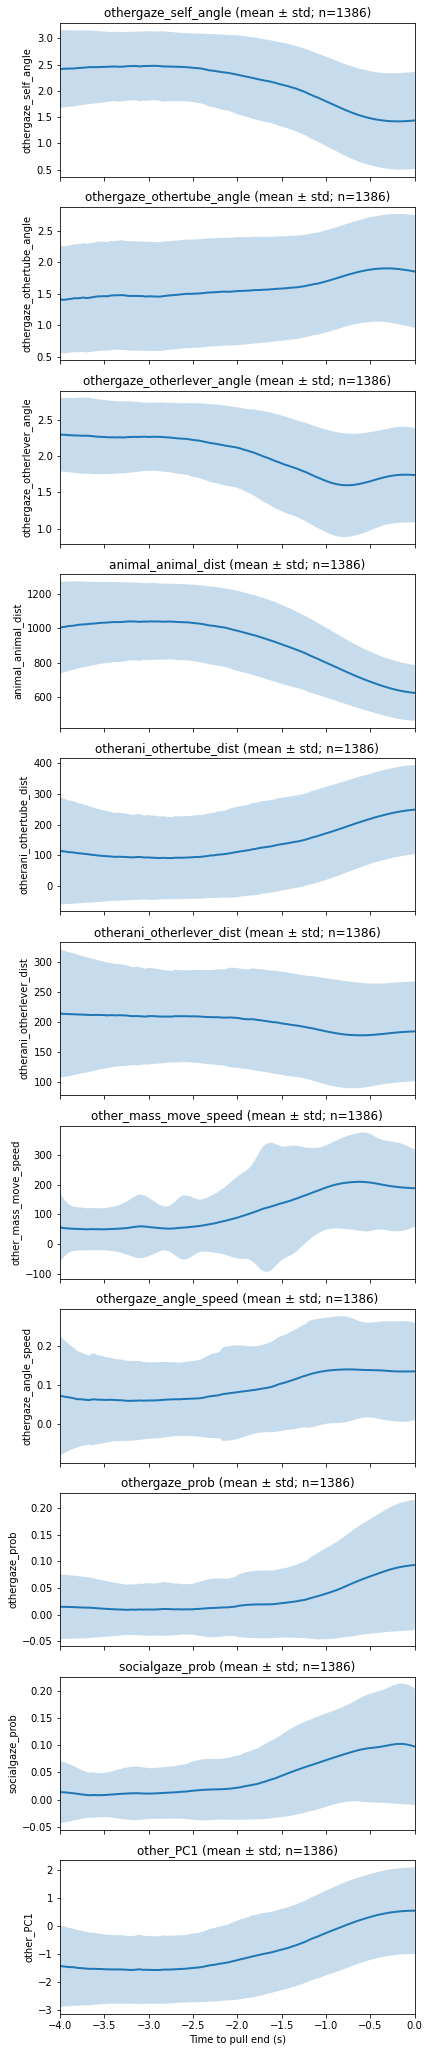

In [462]:
###
# plot the average trace, but this time, focus on the partner's trace aligned to the actor's own pull action
# + bootstrap CI option (per-timepoint, NaN-aware, variable n(t))
###

if 1:
    import numpy as np
    import matplotlib.pyplot as plt

    fps = 30.0
    win_s = 4.0
    nwin = int(win_s * fps) + 1     # 121 samples: -4.0 ... 0.0 (inclusive)
    t = np.linspace(-win_s, 0, nwin)

    # choose summary type
    #   "meanstd"    : mean ± std (NaN-aware)
    #   "mediqr"     : median ± IQR (NaN-aware)
    #   "bootmedci"  : median ± bootstrap CI (NaN-aware, variable n(t))
    summary_mode = "meanstd"

    # bootstrap settings (only used for bootmedci)
    n_boot = 100           # 500–2000 is typical; increase for smoother CI
    ci = 95                # 95% CI
    min_n_t = 10           # require at least this many trials at a timepoint to compute CI

    # ---------------------------------------------------------------------
    # KEEP YOUR ORDERING LOGIC (unchanged)
    # ---------------------------------------------------------------------
    if doPartnerAlignedSelf:
        desired_order = ['othergaze_self_angle',
                         'othergaze_othertube_angle',
                         'othergaze_otherlever_angle',
                         'animal_animal_dist',
                         'otherani_othertube_dist',
                         'otherani_otherlever_dist',
                         'other_mass_move_speed',
                         'othergaze_angle_speed',
                         'othergaze_prob',
                         'socialgaze_prob',
                         'other_PC1']
    else:
        desired_order = [
                        "gaze_other_angle",
                        "gaze_tube_angle",
                        "gaze_lever_angle",
                        "animal_animal_dist",
                        "animal_tube_dist",
                        "animal_lever_dist",
                        "mass_move_speed",
                        "gaze_angle_speed",
                        "socialgaze_prob",
                        "self_PC1",
                        ]

    # keep the desired order
    available = set(pullstartTopull_aligned_long_df["var_name"].unique())
    var_names = [v for v in desired_order if v in available]
    nvars = len(var_names)

    # ---------------------------------------------------------------------
    # helpers
    # ---------------------------------------------------------------------
    def right_align_last_window(trace, nwin):
        """
        Align each trial to its END and take the last nwin points.
        If trace shorter than nwin, left-pad with NaN.
        """
        a = np.asarray(trace, dtype=float).ravel()
        out = np.full(nwin, np.nan, dtype=float)
        if a.size == 0:
            return out
        take = min(a.size, nwin)
        out[-take:] = a[-take:]
        return out

    def nan_iqr(arr2d, qlo=25, qhi=75):
        q1 = np.nanpercentile(arr2d, qlo, axis=0)
        q2 = np.nanpercentile(arr2d, 50, axis=0)
        q3 = np.nanpercentile(arr2d, qhi, axis=0)
        return q1, q2, q3

    def bootstrap_ci_median(arr2d, n_boot=1000, ci=95, min_n=10, rng=None):
        """
        Per-timepoint bootstrap CI for the median.
        arr2d: (n_trials, n_time) with NaNs
        Returns:
          med (n_time,), lo (n_time,), hi (n_time,), n_t (n_time,)
        For each timepoint, bootstrap resamples from the available (non-NaN) trials.
        """
        if rng is None:
            rng = np.random.default_rng(0)

        n_trials, n_time = arr2d.shape
        med = np.full(n_time, np.nan, float)
        lo  = np.full(n_time, np.nan, float)
        hi  = np.full(n_time, np.nan, float)
        n_t = np.zeros(n_time, dtype=int)

        alpha = (100 - ci) / 2.0
        qlo = alpha
        qhi = 100 - alpha

        # loop timepoints; n_time is small (~121), so this is usually fine
        for k in range(n_time):
            x = arr2d[:, k]
            x = x[np.isfinite(x)]
            n = x.size
            n_t[k] = n
            if n < min_n:
                continue

            med[k] = np.median(x)

            # bootstrap medians
            idx = rng.integers(0, n, size=(n_boot, n))
            boots = np.median(x[idx], axis=1)

            lo[k] = np.percentile(boots, qlo)
            hi[k] = np.percentile(boots, qhi)

        return med, lo, hi, n_t

    # ---------------------------------------------------------------------
    # layout
    # ---------------------------------------------------------------------
    ncols = 1
    nrows = nvars
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 2.6*nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    # ---------------------------------------------------------------------
    # main plotting loop
    # ---------------------------------------------------------------------
    for i, v in enumerate(var_names):
        ax = axes[i]

        dfv = pullstartTopull_aligned_long_df.loc[
            pullstartTopull_aligned_long_df["var_name"] == v, ["trace"]
        ]
        traces = dfv["trace"].values  # each is a list/array with variable length

        # build (n_trials, nwin) aligned array
        arr2d = np.vstack([right_align_last_window(tr, nwin) for tr in traces])

        mode = summary_mode.lower()

        if mode == "meanstd":
            center = np.nanmean(arr2d, axis=0)
            spread = np.nanstd(arr2d, axis=0)
            lo, hi = center - spread, center + spread
            ax.fill_between(t, lo, hi, alpha=0.25, linewidth=0)
            ax.plot(t, center, linewidth=2)
            ttl = f"{v} (mean ± std; n={arr2d.shape[0]})"

        elif mode == "mediqr":
            q1, q2, q3 = nan_iqr(arr2d, 25, 75)
            ax.fill_between(t, q1, q3, alpha=0.25, linewidth=0)
            ax.plot(t, q2, linewidth=2)
            ttl = f"{v} (median ± IQR; n={arr2d.shape[0]})"

        elif mode == "bootmedci":
            rng = np.random.default_rng(0)  # deterministic
            med, lo, hi, n_t = bootstrap_ci_median(
                arr2d, n_boot=n_boot, ci=ci, min_n=min_n_t, rng=rng
            )
            ax.fill_between(t, lo, hi, alpha=0.25, linewidth=0)
            ax.plot(t, med, linewidth=2)

            # optional: show where sample size is low by dimming
            # (keeps plot honest without needing an extra panel)
            frac = n_t / np.max(n_t) if np.max(n_t) > 0 else n_t
            # shade background where frac < 0.25 (very sparse)
            sparse = frac < 0.25
            if np.any(sparse):
                # merge contiguous regions
                in_block = False
                start = None
                for k in range(nwin):
                    if sparse[k] and not in_block:
                        in_block = True
                        start = t[k]
                    if in_block and (k == nwin-1 or not sparse[k+1]):
                        end = t[k]
                        ax.axvspan(start, end, color="0.9", alpha=0.5, lw=0)
                        in_block = False

            ttl = f"{v} (median ± {ci}% bootstrap CI; n={arr2d.shape[0]}, min_n(t)={min_n_t})"

        else:
            raise ValueError("summary_mode must be 'meanstd', 'mediqr', or 'bootmedci'")

        # cosmetics
        ax.set_title(ttl)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_xlim(-win_s, 0)
        ax.set_ylabel(v)

    axes[-1].set_xlabel("Time to pull end (s)")
    plt.tight_layout()

    # Save figure
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        if doPartnerAlignedSelf: 
            fig.savefig(figsavefolder + act_animal_to_ana + 'PartnerAlignedActor_in_' + 
                        cond_toplot_type + '_mean_trace_of_prepull_behavioral_variables.pdf')


/tmp/ipykernel_2050583/130734958.py:257: RuntimeWarning: Mean of empty slice
  snap = np.nanmean(y_trial_norm[start_idx:seg_end_eff + 1])


[QC] total grouped trials: 1386
[QC] trials with any gaze (>thr anywhere): 1285
[QC] trials with eligible gaze (>thr before 0.3s cutoff): 1257
[QC] normalization mode: zscore


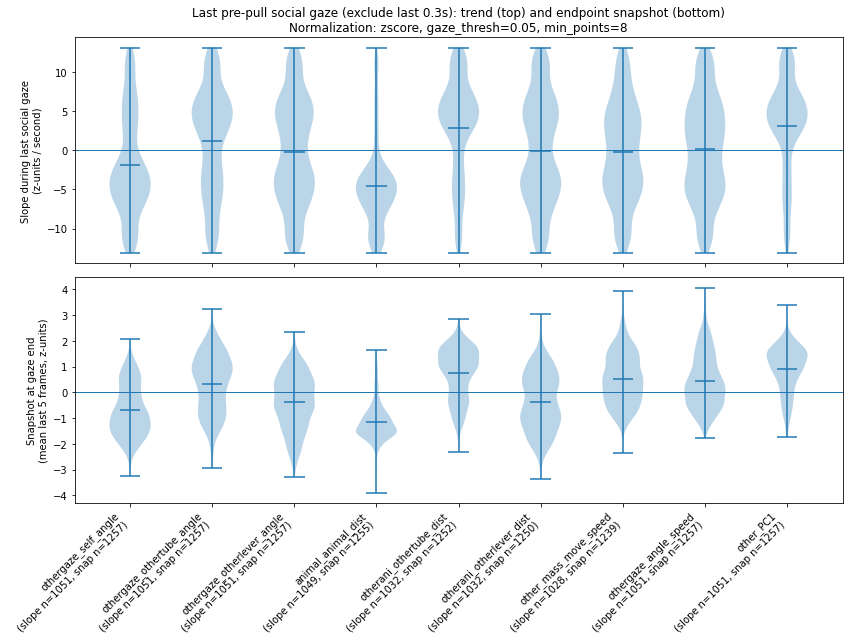

In [465]:
####
# mostly for R2 comment 8 to test if the animal are using gaze to do coincidence detection
# Full code:
#   - Finds LAST social gaze segment BEFORE a cutoff (exclude last 0.3s pre-pull)
#   - Computes (A) slope during that gaze segment and (B) endpoint snapshot
#   - Allows normalization choice: within-trial zscore or 0-1 minmax
#   - Produces a 2-panel violin plot: slopes (top) + snapshots (bottom)
####

if 1:

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # ----------------------------
    # User inputs
    # ----------------------------
    desired_order = [
        'othergaze_self_angle',
        'othergaze_othertube_angle',
        'othergaze_otherlever_angle',
        'animal_animal_dist',
        'otherani_othertube_dist',
        'otherani_otherlever_dist',
        'other_mass_move_speed',
        'othergaze_angle_speed',
        'other_PC1'
    ]

    GAZE_VAR = 'socialgaze_prob'
    GAZE_THRESH = 0.05
    MIN_POINTS = 8

    fps = 30.0
    dt = 1.0 / fps

    # Exclude gaze within last X seconds before pull
    EXCLUDE_LAST_SEC = 0.3
    EXCLUDE_LAST_FRAMES = int(np.ceil(EXCLUDE_LAST_SEC * fps))  # 9 frames at 30Hz

    # Snapshot: average last N frames at end of the (trimmed) last gaze segment
    SNAPSHOT_LAST_N_FRAMES = 5  # set 1 for single-frame snapshot

    # Normalization mode:
    #   'zscore' : within-trial (x-mean)/std  (recommended)
    #   'minmax' : within-trial (x-min)/(max-min)
    NORM_MODE = 'zscore' # 'zscore'  # <-- switch to 'minmax' if desired

    # ----------------------------
    # Helpers
    # ----------------------------
    def _as_array(x):
        return np.asarray(x, dtype=float).ravel()

    def normalize_within_trial(y, mode='zscore'):
        """
        Normalize a 1D trace within trial.
        mode:
          - 'zscore' : (y - mean) / std
          - 'minmax' : (y - min) / (max - min)
        """
        y = _as_array(y)

        if mode == 'zscore':
            mu = np.nanmean(y)
            sd = np.nanstd(y)
            if sd == 0 or np.isnan(sd):
                return np.full_like(y, np.nan)
            return (y - mu) / sd

        elif mode == 'minmax':
            ymin = np.nanmin(y)
            ymax = np.nanmax(y)
            if ymax == ymin or np.isnan(ymin) or np.isnan(ymax):
                return np.full_like(y, np.nan)
            return (y - ymin) / (ymax - ymin)

        else:
            raise ValueError("NORM_MODE must be 'zscore' or 'minmax'")

    def find_last_gaze_segment_before_cutoff(gaze_trace, gaze_thresh, cutoff_end_idx):
        """
        Find [start, end] (inclusive) of the last contiguous segment where gaze > thresh,
        restricting search to indices <= cutoff_end_idx.
        """
        g = _as_array(gaze_trace)
        if len(g) == 0:
            return None

        if cutoff_end_idx < 0:
            return None

        cutoff_end_idx = min(int(cutoff_end_idx), len(g) - 1)
        g2 = g[:cutoff_end_idx + 1]
        on = g2 > gaze_thresh
        if not np.any(on):
            return None

        idx = np.where(on)[0]
        end = idx[-1]
        start = end
        while start > 0 and on[start - 1]:
            start -= 1
        return start, end

    def slope_via_ols(y, t):
        """OLS slope of y ~ a + b*t (np.polyfit)."""
        y = _as_array(y)
        t = _as_array(t)
        if len(y) < 2:
            return np.nan
        b, a = np.polyfit(t, y, 1)
        return b

    # ----------------------------
    # Main computation
    # ----------------------------
    df = pullstartTopull_aligned_long_df.copy()
    df['var_name'] = df['var_name'].astype(str)

    vars_needed = set(desired_order + [GAZE_VAR])
    df = df[df['var_name'].isin(vars_needed)].copy()

    slopes_records = []
    snapshot_records = []

    # QC counters
    n_trials_total = 0
    n_trials_any_gaze = 0
    n_trials_eligible_gaze = 0

    for (date, pull_id), g in df.groupby(['date', 'pull_id'], sort=False):

        n_trials_total += 1

        traces = {row['var_name']: row['trace'] for _, row in g.iterrows()}
        if GAZE_VAR not in traces:
            continue

        gaze = _as_array(traces[GAZE_VAR])
        Lg = len(gaze)
        if Lg < 2:
            continue

        has_any_gaze = np.any(gaze > GAZE_THRESH)
        if has_any_gaze:
            n_trials_any_gaze += 1

        # cutoff: ignore gaze within last EXCLUDE_LAST_SEC before pull (end of trace)
        cutoff_end_idx = (Lg - 1) - EXCLUDE_LAST_FRAMES  # inclusive
        has_eligible_gaze = False
        if cutoff_end_idx >= 0:
            has_eligible_gaze = np.any(gaze[:cutoff_end_idx + 1] > GAZE_THRESH)
        if has_eligible_gaze:
            n_trials_eligible_gaze += 1

        seg = find_last_gaze_segment_before_cutoff(gaze, GAZE_THRESH, cutoff_end_idx)

        if seg is None:
            # no eligible gaze segment before cutoff
            for v in desired_order:
                slopes_records.append({
                    'date': date,
                    'pull_id': pull_id,
                    'var_name': v,
                    'slope_norm_per_s': np.nan,
                    'gaze_dur_s': 0.0,
                    'n_points': 0
                })
                snapshot_records.append({
                    'date': date,
                    'pull_id': pull_id,
                    'var_name': v,
                    'snapshot_norm': np.nan,
                    'gaze_dur_s': 0.0,
                    'n_points': 0
                })
            continue

        seg_start, seg_end = seg
        gaze_dur_s = (seg_end - seg_start + 1) * dt

        g_full = gaze  # already array

        for v in desired_order:

            if v not in traces:
                slopes_records.append({
                    'date': date,
                    'pull_id': pull_id,
                    'var_name': v,
                    'slope_norm_per_s': np.nan,
                    'gaze_dur_s': gaze_dur_s,
                    'n_points': 0
                })
                snapshot_records.append({
                    'date': date,
                    'pull_id': pull_id,
                    'var_name': v,
                    'snapshot_norm': np.nan,
                    'gaze_dur_s': gaze_dur_s,
                    'n_points': 0
                })
                continue

            y_full = _as_array(traces[v])

            # align length with gaze
            L = min(len(y_full), len(g_full))
            if L < 2 or seg_start >= L:
                slopes_records.append({
                    'date': date,
                    'pull_id': pull_id,
                    'var_name': v,
                    'slope_norm_per_s': np.nan,
                    'gaze_dur_s': gaze_dur_s,
                    'n_points': 0
                })
                snapshot_records.append({
                    'date': date,
                    'pull_id': pull_id,
                    'var_name': v,
                    'snapshot_norm': np.nan,
                    'gaze_dur_s': gaze_dur_s,
                    'n_points': 0
                })
                continue

            seg_end_eff = min(seg_end, L - 1)

            # ---- A) Slope during the trimmed last gaze segment ----
            y_seg = y_full[seg_start:seg_end_eff + 1]
            if len(y_seg) < MIN_POINTS:
                slope = np.nan
            else:
                y_seg_norm = normalize_within_trial(y_seg, mode=NORM_MODE)
                t = np.arange(len(y_seg_norm)) * dt
                slope = slope_via_ols(y_seg_norm, t)

            slopes_records.append({
                'date': date,
                'pull_id': pull_id,
                'var_name': v,
                'slope_norm_per_s': slope,
                'gaze_dur_s': gaze_dur_s,
                'n_points': len(y_seg)
            })

            # ---- B) Snapshot at end of the trimmed last gaze segment ----
            # Normalize the WHOLE trial trace first, then sample near seg_end_eff.
            y_trial = y_full[:L]
            y_trial_norm = normalize_within_trial(y_trial, mode=NORM_MODE)

            n_last = int(max(1, SNAPSHOT_LAST_N_FRAMES))
            start_idx = max(seg_start, seg_end_eff - n_last + 1)
            snap = np.nanmean(y_trial_norm[start_idx:seg_end_eff + 1])

            snapshot_records.append({
                'date': date,
                'pull_id': pull_id,
                'var_name': v,
                'snapshot_norm': snap,
                'gaze_dur_s': gaze_dur_s,
                'n_points': len(y_seg)
            })

    slopes_df = pd.DataFrame(slopes_records)
    snapshot_df = pd.DataFrame(snapshot_records)

    print(f"[QC] total grouped trials: {n_trials_total}")
    print(f"[QC] trials with any gaze (>thr anywhere): {n_trials_any_gaze}")
    print(f"[QC] trials with eligible gaze (>thr before {EXCLUDE_LAST_SEC:.1f}s cutoff): {n_trials_eligible_gaze}")
    print(f"[QC] normalization mode: {NORM_MODE}")

    # ----------------------------
    # Plot: 2-panel figure (slope + snapshot)
    # ----------------------------
    slope_plot_data, snap_plot_data = [], []
    labels, ns1, ns2 = [], [], []

    for v in desired_order:
        svals = slopes_df.loc[slopes_df['var_name'] == v, 'slope_norm_per_s'].dropna().values
        pvals = snapshot_df.loc[snapshot_df['var_name'] == v, 'snapshot_norm'].dropna().values
        slope_plot_data.append(svals)
        snap_plot_data.append(pvals)
        labels.append(v)
        ns1.append(len(svals))
        ns2.append(len(pvals))

    if NORM_MODE == 'zscore':
        slope_ylabel = 'Slope during last social gaze\n(z-units / second)'
        snap_ylabel  = f'Snapshot at gaze end\n(mean last {SNAPSHOT_LAST_N_FRAMES} frames, z-units)'
    else:
        slope_ylabel = 'Slope during last social gaze\n(0–1 units / second)'
        snap_ylabel  = f'Snapshot at gaze end\n(mean last {SNAPSHOT_LAST_N_FRAMES} frames, 0–1 scaled)'

    fig, axes = plt.subplots(2, 1, figsize=(max(12, len(desired_order)), 9), sharex=True)

    # Panel 1: slopes
    ax = axes[0]
    ax.violinplot(slope_plot_data, showmeans=True, showextrema=True)
    ax.set_ylabel(slope_ylabel)
    ax.set_title(
        f'Last pre-pull social gaze (exclude last {EXCLUDE_LAST_SEC:.1f}s): trend (top) and endpoint snapshot (bottom)\n'
        f'Normalization: {NORM_MODE}, gaze_thresh={GAZE_THRESH}, min_points={MIN_POINTS}'
    )
    ax.axhline(0, linewidth=1)

    # Panel 2: snapshots
    ax = axes[1]
    ax.violinplot(snap_plot_data, showmeans=True, showextrema=True)
    ax.set_ylabel(snap_ylabel)
    ax.axhline(0, linewidth=1)

    axes[1].set_xticks(np.arange(1, len(labels) + 1))
    axes[1].set_xticklabels(
        [f"{v}\n(slope n={n1}, snap n={n2})" for v, n1, n2 in zip(labels, ns1, ns2)],
        rotation=45, ha='right'
    )

    plt.tight_layout()
    plt.show()

    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        if doPartnerAlignedSelf: 
            fig.savefig(figsavefolder + act_animal_to_ana + 'PartnerAlignedActor_in_' + 
                        cond_toplot_type + '_variableTraces_endSnap_Actorgaze.pdf')
            

In [464]:

# ============================================================
# Simple sanity-check figure:
# For each variable (rows), two panels (cols):
#   - Left: mean of variable DURING gaze vs gaze AUC
#   - Right: std  of variable DURING gaze vs gaze AUC
#
# Filters:
#   1) Remove trials with NO social gaze (no samples with socialgaze_prob > thresh)
#   2) Remove RT outliers (MAD-based)
#
# Requires: pullstartTopull_aligned_long_df in memory
# ============================================================

if 0: 
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt


    # ----------------------------
    # Inputs
    # ----------------------------
    fps = 30.0
    dt = 1.0 / fps

    GAZE_VAR = 'socialgaze_prob'
    GAZE_THRESH = 0.05

    desired_order = [
        'othergaze_self_angle',
        'othergaze_othertube_angle',
        'othergaze_otherlever_angle',
        'otherani_othertube_dist',
        'otherani_otherlever_dist',
        'other_mass_move_speed',
        'othergaze_angle_speed',
        'other_PC1'
    ]

    # RT outlier removal (robust)
    MAD_K = 4.0  # keep trials with robust_z <= MAD_K

    # ----------------------------
    # Helpers
    # ----------------------------
    def _as_array(x):
        return np.asarray(x, dtype=float).ravel()

    def spearman_r(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]; y = y[m]
        if len(x) < 5:
            return np.nan, 0
        xr = pd.Series(x).rank().values
        yr = pd.Series(y).rank().values
        r = np.corrcoef(xr, yr)[0, 1]
        return r, len(x)

    def mad_filter(df, col='rt_s', k=4.0):
        x = df[col].astype(float).values
        med = np.nanmedian(x)
        mad = np.nanmedian(np.abs(x - med))
        if mad == 0 or np.isnan(mad):
            keep = np.isfinite(x)
            z = np.full_like(x, np.nan, dtype=float)
        else:
            z = np.abs(x - med) / (1.4826 * mad)
            keep = np.isfinite(x) & (z <= k)
        out = df.copy()
        out['_rt_robust_z'] = z
        return out[keep].copy(), out[~keep].copy()

    # ----------------------------
    # Build per-trial gaze-restricted features
    # ----------------------------
    df = pullstartTopull_aligned_long_df.copy()
    df['var_name'] = df['var_name'].astype(str)

    vars_needed = set(desired_order + [GAZE_VAR])
    df = df[df['var_name'].isin(vars_needed)].copy()

    trial_rows = []

    for (date, pull_id), g in df.groupby(['date', 'pull_id'], sort=False):
        traces = {row['var_name']: row['trace'] for _, row in g.iterrows()}
        if GAZE_VAR not in traces:
            continue

        gaze = _as_array(traces[GAZE_VAR])
        if len(gaze) < 2:
            continue

        # gaze mask + "no social gaze" exclusion
        gaze_mask = gaze > GAZE_THRESH
        if not np.any(gaze_mask):
            continue  # remove trials with no social gaze

        # trial length (RT)
        rt_s = (len(gaze) - 1) * dt

        # gaze AUC across whole trial (as you requested)
        gaze_auc_s = np.nansum(gaze) * dt

        rec = {
            'date': date,
            'pull_id': pull_id,
            'rt_s': rt_s,
            'gaze_auc_s': gaze_auc_s,
            'gaze_samples': int(np.sum(gaze_mask)),
            'gaze_total_s': float(np.sum(gaze_mask) * dt),
        }

        # Compute mean/std ONLY during gaze samples (mask)
        for v in desired_order:
            if v not in traces:
                rec[f'{v}__mean_gaze'] = np.nan
                rec[f'{v}__std_gaze'] = np.nan
                continue

            y = _as_array(traces[v])

            # Align length safely
            L = min(len(y), len(gaze))
            if L < 2:
                rec[f'{v}__mean_gaze'] = np.nan
                rec[f'{v}__std_gaze'] = np.nan
                continue

            y = y[:L]
            m = gaze_mask[:L]

            if np.sum(m) < 2:
                rec[f'{v}__mean_gaze'] = np.nan
                rec[f'{v}__std_gaze'] = np.nan
            else:
                rec[f'{v}__mean_gaze'] = np.nanmean(y[m])
                rec[f'{v}__std_gaze'] = np.nanstd(y[m])

        trial_rows.append(rec)

    trial_feat_df = pd.DataFrame(trial_rows)
    print("Trials with social gaze (pre-RT filtering):", len(trial_feat_df))

    # ----------------------------
    # Remove RT outliers
    # ----------------------------
    trial_feat_df_filt, trial_feat_df_out = mad_filter(trial_feat_df, col='rt_s', k=MAD_K)
    print(f"RT MAD filter k={MAD_K}: kept {len(trial_feat_df_filt)} / removed {len(trial_feat_df_out)}")

    # Optional quick RT histogram (comment out if you want)
    plt.figure(figsize=(5,3))
    plt.hist(trial_feat_df['rt_s'].dropna().values, bins=50, alpha=0.5, label='All (with gaze)')
    plt.hist(trial_feat_df_filt['rt_s'].dropna().values, bins=50, alpha=0.5, label='After RT filter')
    plt.xlabel("RT (s)")
    plt.ylabel("Count")
    plt.title("RT distribution (gaze-present trials)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot: N variables x 2 panels
    #   Col 1: mean during gaze vs gaze AUC
    #   Col 2: std  during gaze vs gaze AUC
    # ----------------------------
    n = len(desired_order)
    fig_h = max(2.2 * n, 6)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, fig_h), squeeze=False)

    x = trial_feat_df_filt['gaze_auc_s'].values

    for i, v in enumerate(desired_order):
        y_mean = trial_feat_df_filt[f'{v}__mean_gaze'].values
        y_std  = trial_feat_df_filt[f'{v}__std_gaze'].values

        # Mean panel
        ax = axes[i, 0]
        m = np.isfinite(x) & np.isfinite(y_mean)
        r, nn = spearman_r(x[m], y_mean[m])
        ax.scatter(x[m], y_mean[m], s=6, alpha=0.5)
        ax.set_ylabel(v)
        if i == 0:
            ax.set_title("Mean during gaze vs gaze AUC")
        ax.text(0.02, 0.90, f"Spearman r={r:.3f}\n n={nn}", transform=ax.transAxes, fontsize=9, va='top')
        if i == n - 1:
            ax.set_xlabel("Gaze AUC (s)")

        # Std panel
        ax = axes[i, 1]
        m = np.isfinite(x) & np.isfinite(y_std)
        r, nn = spearman_r(x[m], y_std[m])
        ax.scatter(x[m], y_std[m], s=6, alpha=0.5)
        if i == 0:
            ax.set_title("Std during gaze vs gaze AUC")
        ax.text(0.02, 0.90, f"Spearman r={r:.3f}\n n={nn}", transform=ax.transAxes, fontsize=9, va='top')
        if i == n - 1:
            ax.set_xlabel("Gaze AUC (s)")

    plt.tight_layout()
    plt.show()


Raw dt (partner - actor) after 1-to-1 matching: {'n': 1261, 'mean': -0.4288395453343912, 'median': -0.3333333333333339, 'iqr25': -1.4000000000000057, 'iqr75': 0.40000000000000036, 'frac_partner_follows(dt>0)': 0.3679619349722443, 'frac_partner_leads(dt<0)': 0.6098334655035687, 'frac_near_sync(|dt|<=0.1s)': 0.0943695479777954}
After IQR outlier removal: {'n': 1238, 'mean': -0.41572428648357607, 'median': -0.33333333333333304, 'iqr25': -1.3666666666666725, 'iqr75': 0.36666666666667425, 'frac_partner_follows(dt>0)': 0.36591276252019383, 'frac_partner_leads(dt<0)': 0.6114701130856219, 'frac_near_sync(|dt|<=0.1s)': 0.09612277867528271}
Outlier bounds: [-5.900, +4.900] s  (IQR k=2.5)

Within ±CTW (|dt| <= 1.0s): {'n': 676, 'mean': -0.06178500986193342, 'median': -0.03333333333333588, 'iqr25': -0.46666666666666856, 'iqr75': 0.3333333333333144, 'frac_partner_follows(dt>0)': 0.4289940828402367, 'frac_partner_leads(dt<0)': 0.5295857988165681, 'frac_near_sync(|dt|<=0.1s)': 0.1760355029585799}

Le

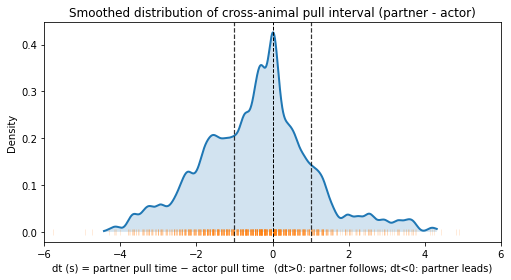

In [414]:
#####
# Distribution of cross-animal pull interval (actor vs closest partner pull)
# + NEW: enforce one-to-one matching to avoid double counting
# + NEW: dashed CTW lines at ±1s (configurable)
# + NEW: print % in [0,1] vs [-1,1] (and lead/follow split) after filtering
#####

if 1:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    try:
        from scipy.stats import gaussian_kde
        _has_scipy = True
    except Exception:
        _has_scipy = False

    fps = 30.0
    CTW = 1.0  # cooperative time window in seconds (±CTW)

    ind_tgt = np.isin(task_conditions, conditions_to_ana)
    dates_tgt = np.array(dates_list)[ind_tgt]
    ndates = len(dates_tgt)

    # Optional: restrict matching before outlier removal
    # Set to CTW if you ONLY want successful pulls; otherwise None to match everything then filter later
    max_abs_dt_s = None   # e.g., CTW or 3.0 or None

    # Outlier removal settings (IQR rule)
    iqr_k = 2.5  # 1.5 stricter; 2.5 less aggressive

    records = []

    for date_tgt in dates_tgt:
        if date_tgt not in pre_data_for_GLM_alldates:
            continue

        keys = pre_data_for_GLM_alldates[date_tgt].keys()
        animals = sorted({k[0] for k in keys})
        if act_animal_to_ana not in animals:
            continue
        partner_animal_to_ana = next(a for a in animals if a != act_animal_to_ana)

        pull_actor = np.asarray(pre_data_for_GLM_alldates[date_tgt][(act_animal_to_ana, "Y")]).astype(int)
        pull_partner = np.asarray(pre_data_for_GLM_alldates[date_tgt][(partner_animal_to_ana, "Y")]).astype(int)

        a_frames = np.where(pull_actor == 1)[0]
        p_frames = np.where(pull_partner == 1)[0]
        if len(a_frames) == 0 or len(p_frames) == 0:
            continue

        a_t = a_frames / fps
        p_t = p_frames / fps  # sorted by construction

        # nearest neighbor in p_t for each a_t using searchsorted
        idx = np.searchsorted(p_t, a_t)

        for i_pull, a_time in enumerate(a_t):
            j = idx[i_pull]
            cand = []
            if j - 1 >= 0:
                cand.append(j - 1)
            if j < len(p_t):
                cand.append(j)
            if len(cand) == 0:
                continue

            # pick nearest by absolute dt
            dts = np.array([p_t[k] - a_time for k in cand], dtype=float)  # partner - actor
            k_best = cand[int(np.argmin(np.abs(dts)))]
            dt = float(p_t[k_best] - a_time)  # seconds

            if (max_abs_dt_s is not None) and (abs(dt) > max_abs_dt_s):
                continue

            records.append({
                "date": date_tgt,
                "actor": act_animal_to_ana,
                "partner": partner_animal_to_ana,
                "actor_pull_frame": int(a_frames[i_pull]),
                "partner_pull_frame": int(p_frames[k_best]),
                "dt_s": dt,  # partner - actor
                "abs_dt": abs(dt),
            })

    dt_df = pd.DataFrame(records)
    if dt_df.empty:
        raise RuntimeError("No matched pulls found. Check Y arrays, dates_tgt, or max_abs_dt_s.")

    # ============================================================
    # NEW: one-to-one matching to avoid double counting
    # Keep, within each date, the closest actor-pull for each partner-pull
    # (i.e., partner_pull_frame used at most once per date)
    # ============================================================
    dt_df = (
        dt_df.sort_values(["date", "partner_pull_frame", "abs_dt"])
            .drop_duplicates(subset=["date", "partner_pull_frame"], keep="first")
            .sort_values(["date", "actor_pull_frame"])
            .reset_index(drop=True)
    )

    dt = dt_df["dt_s"].to_numpy(dtype=float)
    dt = dt[np.isfinite(dt)]

    # ---- Outlier removal via IQR rule ----
    q1, q3 = np.percentile(dt, [25, 75])
    iqr = q3 - q1
    lo = q1 - iqr_k * iqr
    hi = q3 + iqr_k * iqr
    keep = (dt >= lo) & (dt <= hi)
    dt_clean = dt[keep]

    # ============================================================
    # NEW: compute success subset within ±CTW
    # ============================================================
    dt_success = dt_clean[np.abs(dt_clean) <= CTW]

    # ---- Summary ----
    def _summ(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        return {
            "n": int(x.size),
            "mean": float(np.mean(x)) if x.size else np.nan,
            "median": float(np.median(x)) if x.size else np.nan,
            "iqr25": float(np.percentile(x, 25)) if x.size else np.nan,
            "iqr75": float(np.percentile(x, 75)) if x.size else np.nan,
            "frac_partner_follows(dt>0)": float(np.mean(x > 0)) if x.size else np.nan,
            "frac_partner_leads(dt<0)": float(np.mean(x < 0)) if x.size else np.nan,
            "frac_near_sync(|dt|<=0.1s)": float(np.mean(np.abs(x) <= 0.1)) if x.size else np.nan,
        }

    s_raw = _summ(dt)
    s_cln = _summ(dt_clean)
    s_suc = _summ(dt_success)

    print("Raw dt (partner - actor) after 1-to-1 matching:", s_raw)
    print("After IQR outlier removal:", s_cln)
    print(f"Outlier bounds: [{lo:+.3f}, {hi:+.3f}] s  (IQR k={iqr_k})")
    if max_abs_dt_s is not None:
        print(f"Applied max_abs_dt_s = {max_abs_dt_s} s before outlier removal")

    print(f"\nWithin ±CTW (|dt| <= {CTW:.1f}s):", s_suc)

    # ============================================================
    # NEW: percentages requested by you
    #   - percent in [0, +CTW] out of [-CTW, +CTW]
    #   - (also prints lead vs follow split)
    # ============================================================
    if dt_success.size > 0:
        pct_follow_in_success = 100.0 * np.mean((dt_success >= 0) & (dt_success <= CTW))
        pct_lead_in_success = 100.0 * np.mean((dt_success >= -CTW) & (dt_success < 0))
        print("\nLead/Follow breakdown among successful (±CTW) matches:")
        print(f"  Partner follows actor (0 to +{CTW:.1f}s): {pct_follow_in_success:5.1f}%")
        print(f"  Partner leads actor   (-{CTW:.1f}s to 0): {pct_lead_in_success:5.1f}%")
        print(f"  Check (should ≈100%): {(pct_follow_in_success + pct_lead_in_success):5.1f}%")
    else:
        print("\nNo dt values within ±CTW after cleaning; cannot compute lead/follow %.")

    # ---- Smoothed KDE plot ----
    fig, ax = plt.subplots(figsize=(7.2, 4.0))

    if dt_clean.size < 5:
        ax.hist(dt_clean, bins=20, alpha=0.8)
        ax.set_title("dt distribution (too few samples for KDE)")
    else:
        # grid for KDE
        xmin, xmax = np.percentile(dt_clean, [1, 99])
        pad = 0.10 * (xmax - xmin + 1e-9)
        xgrid = np.linspace(xmin - pad, xmax + pad, 1500)

        if _has_scipy:
            kde = gaussian_kde(dt_clean)  # Scott's rule bandwidth
            kde.set_bandwidth(kde.factor * 0.3)  # less smooth (try 0.3–0.7)
            y = kde(xgrid)
            ax.plot(xgrid, y, linewidth=2)
            ax.fill_between(xgrid, 0, y, alpha=0.2, linewidth=0)
        else:
            counts, edges = np.histogram(dt_clean, bins=200, density=True)
            centers = 0.5 * (edges[:-1] + edges[1:])
            k = 3
            kernel = np.ones(k) / k
            y = np.convolve(counts, kernel, mode="same")
            ax.plot(centers, y, linewidth=2)
            ax.fill_between(centers, 0, y, alpha=0.2, linewidth=0)

        # optional: rug
        ax.plot(dt_clean, np.zeros_like(dt_clean), "|", alpha=0.15)

        ax.set_title("Smoothed distribution of cross-animal pull interval (partner - actor)")

    # NEW: CTW lines (±1s)
    ax.axvline(-CTW, color="k", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axvline(+CTW, color="k", linestyle="--", linewidth=1.2, alpha=0.8)

    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("dt (s) = partner pull time − actor pull time   (dt>0: partner follows; dt<0: partner leads)")
    ax.set_ylabel("Density")

    # set xlim a bit wider than CTW so CTW lines are visible
    ax.set_xlim([-6, 6])

    plt.tight_layout()

    # Save figure
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_Pullfocused_continuousBhv_partnerDistVaris_with_glm_model/" + \
                        cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/glm_fitting_summary_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        if doPartnerAlignedSelf:
            fig.savefig(figsavefolder + act_animal_to_ana + '_in_' +
                        cond_toplot_type + '_acrossAnimal_pullIntv_leadingORfollowing.pdf')


/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 146 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/matplotlib/backends/_backend_pdf_ps.py:109: RuntimeWarning: Glyph 146 missing from current font.
  font.set_text(s, 0.0, flags=ft2font.LOAD_NO_HINTING)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 146 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 146 missing from current font.
  font.set_text(s, 0, flags=flags)


✅ Illustration saved successfully to: glm_method_illustration.pdf


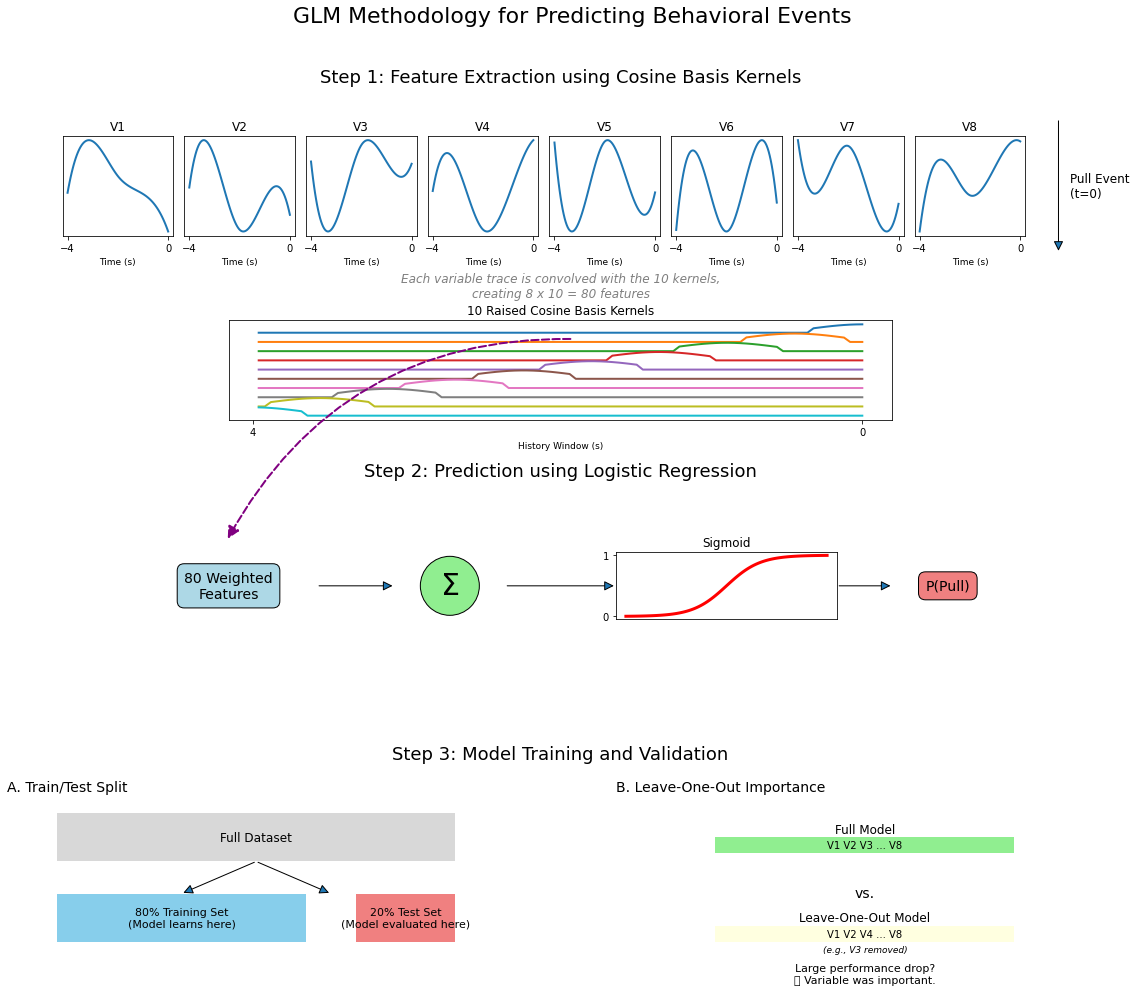

In [24]:
# generate demo glm pipeline cartoon
if 1:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch, PathPatch, ConnectionStyle, Rectangle
    from matplotlib.path import Path
    from scipy.interpolate import make_interp_spline

    def make_raised_cosine_basis(duration_s, n_basis, dt):
        """
        Generates a basis set of raised cosines.
        """
        t = np.arange(0, duration_s, dt)
        c = np.linspace(0, duration_s, n_basis)
        width = (c[1] - c[0]) * 1.5
        basis = []
        for ci in c:
            phi = (t - ci) * np.pi / width
            b = np.cos(np.clip(phi, -np.pi, np.pi))
            b = (b + 1) / 2
            b[(t < ci - width/2) | (t > ci + width/2)] = 0
            basis.append(b)
        basis = np.stack(basis, axis=1)
        return basis

    def generate_glm_illustration():
        """
        Generates and saves a PDF figure illustrating a GLM methodology, including
        feature extraction, logistic regression, data splitting, and validation procedures.
        """

        # --- 1. Setup Figure and Subplots ---
        # Increased figure height and added a row for the new cartoons
        fig = plt.figure(figsize=(16, 14))
        gs = fig.add_gridspec(3, 1, height_ratios=[1.5, 1, 0.8])
        ax_top = fig.add_subplot(gs[0])
        ax_bottom = fig.add_subplot(gs[1])
        ax_validation = fig.add_subplot(gs[2]) # New axis for validation cartoons

        fig.suptitle("GLM Methodology for Predicting Behavioral Events", fontsize=22, y=0.98)

        # --- 2. Top Row: Feature Extraction ---
        ax_top.set_title("Step 1: Feature Extraction using Cosine Basis Kernels", fontsize=18, pad=20)
        ax_top.axis('off')

        # A. Draw Smoother Variable Traces
        num_vars = 8
        time = np.linspace(-4, 0, 100)
        for i in range(num_vars):
            var_ax = ax_top.inset_axes([0.05 + i*0.11, 0.6, 0.1, 0.3])
            np.random.seed(i)
            spline = make_interp_spline(np.linspace(-4, 0, 5), np.random.rand(5))
            var_ax.plot(time, spline(time), lw=2)
            var_ax.set_title(f"V{i+1}", fontsize=12, pad=5)
            var_ax.set_xticks([-4, 0]); var_ax.set_yticks([]); var_ax.set_xlabel("Time (s)", fontsize=9)

        # B. Draw Kernels using your function
        num_kernels = 10; duration_s = 4; dt = 0.04
        kernel_ax = ax_top.inset_axes([0.2, 0.05, 0.6, 0.3])
        basis_kernels = make_raised_cosine_basis(duration_s, num_kernels, dt)
        for k in range(basis_kernels.shape[1]):
            kernel_ax.plot(np.arange(0, duration_s, dt), basis_kernels[:, k] - k * 1.1, lw=2)
        kernel_ax.set_title("10 Raised Cosine Basis Kernels", fontsize=12)
        kernel_ax.set_yticks([]); kernel_ax.set_xticks([0, 4]); kernel_ax.set_xlabel("History Window (s)", fontsize=9)
        kernel_ax.invert_xaxis()

        # C. Add connecting text and lines
        ax_top.text(0.5, 0.45, "Each variable trace is convolved with the 10 kernels,\ncreating 8 x 10 = 80 features",
                    ha='center', va='center', fontsize=12, style='italic', color='gray')
        pull_line = FancyArrowPatch((0.95, 0.95), (0.95, 0.55), mutation_scale=20, arrowstyle='-|>')
        ax_top.add_patch(pull_line)
        ax_top.text(0.96, 0.75, "Pull Event\n(t=0)", va='center', fontsize=12)

        # --- 3. Middle Row: Logistic Regression Model ---
        ax_bottom.set_title("Step 2: Prediction using Logistic Regression", fontsize=18, pad=20)
        ax_bottom.axis('off')

        # A. Draw model components
        ax_bottom.text(0.2, 0.6, "80 Weighted\nFeatures", ha='center', va='center', fontsize=14,
                       bbox=dict(boxstyle="round,pad=0.5", fc="lightblue", ec="black"))
        ax_bottom.text(0.4, 0.6, "$\\Sigma$", ha='center', va='center', fontsize=30,
                       bbox=dict(boxstyle="circle,pad=0.5", fc="lightgreen", ec="black"))
        sigmoid_ax = ax_bottom.inset_axes([0.55, 0.45, 0.2, 0.3])
        x_sig = np.linspace(-6, 6, 100)
        sigmoid_ax.plot(x_sig, 1 / (1 + np.exp(-x_sig)), color='red', lw=3)
        sigmoid_ax.set_title("Sigmoid", fontsize=12); sigmoid_ax.set_xticks([]); sigmoid_ax.set_yticks([0, 1])
        ax_bottom.text(0.85, 0.6, "P(Pull)", ha='center', va='center', fontsize=14,
                       bbox=dict(boxstyle="round,pad=0.5", fc="lightcoral", ec="black"))

        # B. Add arrows
        ax_bottom.add_patch(FancyArrowPatch((0.28, 0.6), (0.35, 0.6), mutation_scale=20, arrowstyle='-|>'))
        ax_bottom.add_patch(FancyArrowPatch((0.45, 0.6), (0.55, 0.6), mutation_scale=20, arrowstyle='-|>'))
        ax_bottom.add_patch(FancyArrowPatch((0.75, 0.6), (0.8, 0.6), mutation_scale=20, arrowstyle='-|>'))

        # --- 4. Connect Top and Bottom Rows ---
        con = ConnectionStyle.Arc3(rad=0.3)
        arrow = FancyArrowPatch((0.5, 0.65), (0.2, 0.45), transform=fig.transFigure, connectionstyle=con,
                                arrowstyle="-|>", mutation_scale=25, lw=2, color='purple', linestyle='dashed')
        fig.add_artist(arrow)

        # --- 5. NEW: Bottom Row for Validation Cartoons ---
        ax_validation.set_title("Step 3: Model Training and Validation", fontsize=18, pad=20)
        ax_validation.axis('off')

        # A. Cartoon for 80/20 Split
        ax_split = ax_validation.inset_axes([0, 0, 0.45, 0.9])
        ax_split.set_title("A. Train/Test Split", fontsize=14, loc='left')
        ax_split.axis('off')
        ax_split.add_patch(Rectangle((0.1, 0.6), 0.8, 0.3, facecolor='gray', alpha=0.3, label='Full Dataset'))
        ax_split.text(0.5, 0.75, "Full Dataset", ha='center', va='center', fontsize=12)
        ax_split.add_patch(FancyArrowPatch((0.5, 0.6), (0.35, 0.4), mutation_scale=20, arrowstyle='-|>'))
        ax_split.add_patch(FancyArrowPatch((0.5, 0.6), (0.65, 0.4), mutation_scale=20, arrowstyle='-|>'))
        ax_split.add_patch(Rectangle((0.1, 0.1), 0.5, 0.3, facecolor='skyblue', label='Training Set'))
        ax_split.text(0.35, 0.25, "80% Training Set\n(Model learns here)", ha='center', va='center', fontsize=11)
        ax_split.add_patch(Rectangle((0.7, 0.1), 0.2, 0.3, facecolor='lightcoral', label='Testing Set'))
        ax_split.text(0.8, 0.25, "20% Test Set\n(Model evaluated here)", ha='center', va='center', fontsize=11)

        # B. Cartoon for Leave-One-Out
        ax_loo = ax_validation.inset_axes([0.55, 0, 0.45, 0.9])
        ax_loo.set_title("B. Leave-One-Out Importance", fontsize=14, loc='left')
        ax_loo.axis('off')
        # Full Model
        ax_loo.text(0.5, 0.8, "Full Model", ha='center', va='center', fontsize=12)
        ax_loo.add_patch(Rectangle((0.2, 0.65), 0.6, 0.1, facecolor='lightgreen'))
        ax_loo.text(0.5, 0.7, "V1 V2 V3 ... V8", ha='center', va='center', fontsize=10)
        # Leave-One-Out Model
        ax_loo.text(0.5, 0.4, "vs.", ha='center', va='center', fontsize=14)
        ax_loo.text(0.5, 0.25, "Leave-One-Out Model", ha='center', va='center', fontsize=12)
        ax_loo.add_patch(Rectangle((0.2, 0.1), 0.6, 0.1, facecolor='lightyellow'))
        ax_loo.text(0.5, 0.15, "V1 V2 V4 ... V8", ha='center', va='center', fontsize=10)
        ax_loo.text(0.5, 0.05, "(e.g., V3 removed)", ha='center', va='center', fontsize=9, style='italic')
        ax_loo.text(0.5, -0.1, "Large performance drop?\n Variable was important.", ha='center', va='center', fontsize=11)

        # --- 6. Save the Figure ---
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        file_path = "glm_method_illustration.pdf"
        plt.savefig(file_path)
        print(f"✅ Illustration saved successfully to: {file_path}")

    if __name__ == '__main__':
        generate_glm_illustration()



## old code, not in use for now

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Helper function to define successful pulls
def get_successful_pull_indices(juice_ts, pull_ts):
    juice_indices = np.where(juice_ts == 1)[0]
    pull_indices = np.where(pull_ts == 1)[0]
    if len(juice_indices) == 0 or len(pull_indices) == 0: return np.array([], dtype=int)
    insertion_points = np.searchsorted(pull_indices, juice_indices)
    valid_mask = insertion_points > 0
    successful_indices = pull_indices[insertion_points[valid_mask] - 1]
    return np.unique(successful_indices)

# Helper function to create basis functions
def create_raised_cosine_basis(kernel_len_frames, n_bases):
    x = np.linspace(0, np.pi, kernel_len_frames)
    centers = np.linspace(np.pi / (2 * n_bases), np.pi - np.pi / (2 * n_bases), n_bases)
    width = np.pi / n_bases
    basis_funcs = np.zeros((kernel_len_frames, n_bases))
    for i, center in enumerate(centers):
        mask = (x > center - width) & (x < center + width)
        basis_funcs[mask, i] = (np.cos((x[mask] - center) * np.pi / width) + 1) / 2
    return basis_funcs

# --- Function 1: Prepare the Design Matrix ---
# --- Function 1: Prepare the Design Matrix ---
def prepare_glm_design_matrix(animal_id, self_pull_ts, self_juice_ts, self_speed_ts, self_gaze_ts,
                              partner_pull_ts, partner_speed_ts, fs,
                              kernel_duration_s, n_basis_funcs):
    """
    Prepares the design matrix for a GLM analysis for a single animal.
    MODIFICATION: Replaced partner pull kernel with time since last pull for both self and partner.
    """
    print(f"\n{'='*20} Preparing Design Matrix for {animal_id} {'='*20}")
    
    n_total_frames = len(self_pull_ts)
    kernel_n_frames = int(kernel_duration_s * fs)

    # 1. Pre-computation
    successful_self_pull_indices = get_successful_pull_indices(self_juice_ts, self_pull_ts)
    basis_functions = create_raised_cosine_basis(kernel_n_frames, n_basis_funcs)
    
    # MODIFICATION: Get all pull indices for recency calculation
    all_self_pull_indices = np.where(self_pull_ts == 1)[0]
    all_partner_pull_indices = np.where(partner_pull_ts == 1)[0]

    # 2. Build the Design Matrix using efficient, vectorized operations
    print(f"Building GLM Design Matrix for {animal_id}...")
    
    # Create the main time vector for the analysis
    time_vector = np.arange(n_total_frames)
    
    # a) Vectorized "time since last event" calculations
    def time_since_last_event(event_indices, time_vector):
        if len(event_indices) == 0:
            return np.full(len(time_vector), np.nan)
        insertion_points = np.searchsorted(event_indices, time_vector)
        valid_mask = insertion_points > 0
        last_event_indices = event_indices[insertion_points[valid_mask] - 1]
        time_since = np.full(len(time_vector), np.nan)
        time_since[valid_mask] = (time_vector[valid_mask] - last_event_indices) / fs
        return time_since

    time_since_last_success = time_since_last_event(successful_self_pull_indices, time_vector)
    time_since_last_self_pull = time_since_last_event(all_self_pull_indices, time_vector)
    time_since_last_partner_pull = time_since_last_event(all_partner_pull_indices, time_vector)

    # b) Create the convolved (kernel-based) predictors
    flipped_basis = np.ascontiguousarray(basis_functions[::-1, :])
    convolved_features = {}
    for i in range(n_basis_funcs):
        basis = flipped_basis[:, i]
        convolved_features[f'self_speed_b{i}'] = np.convolve(self_speed_ts, basis, mode='same')
        convolved_features[f'partner_speed_b{i}'] = np.convolve(partner_speed_ts, basis, mode='same')

    # b) Create the simple average (rolling mean) predictor for GAZE
    gaze_mean = pd.Series(self_gaze_ts).rolling(window=kernel_n_frames).mean().to_numpy()
    
    # c) Assemble the final DataFrame
    design_matrix = pd.DataFrame(convolved_features)
    design_matrix['time_since_last_success'] = time_since_last_success
    design_matrix['time_since_last_self_pull'] = time_since_last_self_pull
    design_matrix['time_since_last_partner_pull'] = time_since_last_partner_pull
    design_matrix['response'] = self_pull_ts
    design_matrix['self_gaze_auc'] = gaze_mean # Add the simple average predictor
    
    # Drop rows with NaN (from the beginning before the first events occurred) and reset index
    design_matrix = design_matrix.dropna().reset_index(drop=True)
    print(f"Design matrix for {animal_id} created with {len(design_matrix)} rows.")
    
    return design_matrix

# --- Function 2: Fit the GLM and Return Results ---
def fit_and_summarize_glm(design_matrix, animal_id):
    """
    Fits a logistic GLM to a pre-prepared design matrix.
    """
    print(f"\n--- Fitting Logistic GLM for {animal_id} ---")
    if design_matrix is None or design_matrix.empty:
        print(f"Cannot fit model for {animal_id}, design matrix is empty.")
        return None
        
    y = design_matrix['response']
    X = design_matrix.drop(columns=['response','self_gaze_auc'])
    X = sm.add_constant(X, prepend=True) # Ensure const is the first column    

    logit_model = sm.Logit(y, X)
    result = logit_model.fit(disp=0)
    
    return result, X


# --- Function 3: kernel recontruction ---
# --- 3. MODIFICATION: New function to reconstruct and plot from the results object ---
def reconstruct_and_plot_kernel(ax, glm_results, variable_name, basis_funcs, color, label):
    """
    Reconstructs and plots a single kernel with its 95% CI from a fitted GLM results object.
    
    Args:
        ax (matplotlib.axes.Axes): The subplot axis to plot on.
        glm_results (statsmodels.results.ResultWrapper): The fitted model object.
        variable_name (str): The base name of the variable (e.g., 'self_speed').
        basis_funcs (np.array): The basis function matrix used for fitting.
        color (str): The color for the plot line.
        label (str): The label for the plot legend.
    """
    n_bases = basis_funcs.shape[1]
    
    # Automatically find all coefficients related to the variable (e.g., 'self_speed_b0', 'self_speed_b1', ...)
    coef_names = [f'{variable_name}_b{i}' for i in range(n_bases)]
    
    # Extract coefficients and the relevant part of the covariance matrix
    try:
        coeffs = glm_results.params.filter(items=coef_names)
        cov_matrix = glm_results.cov_params().loc[coef_names, coef_names]
    except KeyError:
        print(f"Warning: Could not find coefficients for '{variable_name}' in the model results. Skipping.")
        return

    # Reconstruct the kernel by multiplying the basis functions by their fitted weights
    reconstructed_kernel = basis_funcs @ coeffs
    
    # --- Calculate the 95% Confidence Interval for the kernel ---
    # This involves matrix multiplication with the covariance matrix
    kernel_variance = np.diag(basis_funcs @ cov_matrix @ basis_funcs.T)
    kernel_std_err = np.sqrt(kernel_variance)
    
    upper_ci = reconstructed_kernel + 1.96 * kernel_std_err
    lower_ci = reconstructed_kernel - 1.96 * kernel_std_err
    
    # --- Plotting ---
    time_axis = np.linspace(-KERNEL_DURATION_S, 0, len(reconstructed_kernel))
    ax.plot(time_axis, reconstructed_kernel, color=color, label=label, linewidth=2.5)
    ax.fill_between(time_axis, lower_ci, upper_ci, color=color, alpha=0.2, label=f'_nolegend_')


# 
# --- 2. Define a Reusable Function to Calculate the Partial Decision Variable ---
def add_partial_decision_variable(glm_results, design_matrix, variable_base_name, new_column_name):
    """
    Calculates a decision variable using only the intercept and one set of kernel coefficients.

    Args:
        glm_results (statsmodels.results.ResultWrapper): The fitted model object.
        design_matrix (pd.DataFrame): The design matrix used for fitting.
        variable_base_name (str): The base name of the variable (e.g., 'partner_speed').
        new_column_name (str): The name for the new column to be added.
    """
    if glm_results is None or design_matrix.empty:
        print(f"Skipping calculation for {new_column_name}, model or data is empty.")
        return design_matrix
    
    # a) Get all fitted parameters from the results object
    all_params = glm_results.params

    # b) Isolate the specific coefficients we need
    coef_names = [f'{variable_base_name}_b{i}' for i in range(N_BASIS_FUNCS)]
    variable_coeffs = all_params.filter(items=coef_names)
    intercept_coef = all_params['const']

    # c) Select the corresponding feature columns from the design matrix
    variable_features = design_matrix[coef_names]

    # d) Calculate the weighted sum (dot product) and add the intercept
    partial_dv = variable_features.dot(variable_coeffs) + intercept_coef
    
    # e) Add the result as a new column to the original dataframe
    design_matrix[new_column_name] = partial_dv
    
    print(f"Added column '{new_column_name}' to the dataframe.")
    return design_matrix

In [ ]:

# --- Main Execution ---

# MODIFICATION: Define kernel parameters here for easy adjustment
KERNEL_DURATION_S = 4.0  # The length of the history kernel in seconds
N_BASIS_FUNCS = 8        # The number of basis functions to represent the kernel

# STEP A: Prepare the data for each animal, passing the new parameters
design_matrix_a1 = prepare_glm_design_matrix(
    animal_id='animal1',
    self_pull_ts=pull1_data, self_juice_ts=juice1_data, self_speed_ts=speed1_data, self_gaze_ts=gaze1_data,
    partner_pull_ts=pull2_data, partner_speed_ts=speed2_data, fs=fps,
    kernel_duration_s=KERNEL_DURATION_S, n_basis_funcs=N_BASIS_FUNCS
)

design_matrix_a2 = prepare_glm_design_matrix(
    animal_id='animal2',
    self_pull_ts=pull2_data, self_juice_ts=juice2_data, self_speed_ts=speed2_data, self_gaze_ts=gaze2_data,
    partner_pull_ts=pull1_data, partner_speed_ts=speed1_data, fs=fps,
    kernel_duration_s=KERNEL_DURATION_S, n_basis_funcs=N_BASIS_FUNCS
)


In [ ]:
kernel_duration_s = KERNEL_DURATION_S
n_bases = N_BASIS_FUNCS
kernel_n_frames = int(kernel_duration_s * fps)
basis_functions = create_raised_cosine_basis(kernel_n_frames, n_bases)

In [ ]:
design_matrix_a1['time_since_last_partner_pull']

In [ ]:
# STEP B: Fit the models
glm_results_a1, X1 = fit_and_summarize_glm(design_matrix_a1, 'animal1')
glm_results_a2, X2 = fit_and_summarize_glm(design_matrix_a2, 'animal2')


# --- MODIFICATION: Add new step to reconstruct the decision variable ---
print("\n" + "="*50)
print("              RECONSTRUCTING DECISION VARIABLE")
print("="*50)

if glm_results_a1 is not None:
    # Use the .predict() method on the fitted model with the original data
    # This returns the linear predictor (log-odds) for each time step
    decision_variable_a1 = glm_results_a1.predict(X1)
    
    # Add it as a new column to the original design matrix
    design_matrix_a1['decision_variable'] = decision_variable_a1
    
    print("\n--- Animal 1 Design Matrix with new 'decision_variable' column ---")
    print(design_matrix_a1[['response', 'decision_variable']].head())

if glm_results_a2 is not None:
    decision_variable_a2 = glm_results_a2.predict(X2)
    design_matrix_a2['decision_variable'] = decision_variable_a2
    
    print("\n--- Animal 2 Design Matrix with new 'decision_variable' column ---")
    print(design_matrix_a2[['response', 'decision_variable']].head())

print("\nReconstruction complete. The design matrices have been updated.")


# STEP C: Inspect the final results
print("\n\n" + "="*50)
print("              FINAL GLM RESULTS")
print("="*50)
if glm_results_a1:
    print("\n\n--- GLM Fit Summary for Animal 1 ---")
    print(glm_results_a1.summary())
if glm_results_a2:
    print("\n\n--- GLM Fit Summary for Animal 2 ---")
    print(glm_results_a2.summary())

In [ ]:

# Create a figure with two subplots, side-by-side
print("\n--- Plotting Reconstructed Kernels directly from model results ---")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# --- Plot for Animal 1 ---
ax1 = axes[0]
reconstruct_and_plot_kernel(ax1, glm_results_a1, 'self_speed', basis_functions, 'blue', 'Self Speed Kernel')
reconstruct_and_plot_kernel(ax1, glm_results_a1, 'partner_speed', basis_functions, 'green', 'Partner Speed Kernel')
# You could also plot the partner_pull kernel here
# reconstruct_and_plot_kernel(ax1, glm_results_a1, 'partner_pull', basis_functions, 'purple', 'Partner Pull Kernel')

ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title('Animal 1: Reconstructed Kernels', fontsize=16)
ax1.set_xlabel('Time before Pull (seconds)', fontsize=12)
ax1.set_ylabel('Kernel Weight (Influence on Pulling)', fontsize=12)
ax1.legend()


# --- Plot for Animal 2 ---
ax2 = axes[1]
reconstruct_and_plot_kernel(ax2, glm_results_a2, 'self_speed', basis_functions, 'blue', 'Self Speed Kernel')
reconstruct_and_plot_kernel(ax2, glm_results_a2, 'partner_speed', basis_functions, 'green', 'Partner Speed Kernel')

ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title('Animal 2: Reconstructed Kernels', fontsize=16)
ax2.set_xlabel('Time before Pull (seconds)', fontsize=12)
ax2.legend()

plt.suptitle('Comparison of GLM Kernels Across Animals (with 95% C.I.)', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
plt.plot(design_matrix_a2['response'][100:500])
plt.plot(design_matrix_a2['decision_variable'][100:500])



In [ ]:
ind_ = design_matrix_a2['response']==1
design_matrix_tgt = design_matrix_a2[ind_]

x = design_matrix_tgt['decision_variable']
y = design_matrix_tgt['self_gaze_auc']

plt.plot(design_matrix_tgt['decision_variable'],design_matrix_tgt['self_gaze_auc'],'.')

# 1. Perform the linear regression to get all statistics
slope, intercept, r_value, p_value, std_err = st.linregress(x, y)
print(slope)
print(r_value)
print(p_value)


In [ ]:
# --- 3. Main Execution: Add the new column for each animal ---
print("\n--- Reconstructing partial decision variable for Partner Speed ---")

# For Animal 1
design_matrix_a1 = add_partial_decision_variable(
    glm_results=glm_results_a1,
    design_matrix=design_matrix_a1,
    variable_base_name='partner_speed',
    new_column_name='decision_variable_partner_speed'
)

# For Animal 2
design_matrix_a2 = add_partial_decision_variable(
    glm_results=glm_results_a2,
    design_matrix=design_matrix_a2,
    variable_base_name='partner_speed',
    new_column_name='decision_variable_partner_speed'
)

In [ ]:
plt.plot(design_matrix_a2['time_since_last_success'])

In [ ]:
plt.plot(design_matrix_a2['response'][100:1000])
plt.plot(design_matrix_a2['decision_variable_partner_speed'][100:1000])


In [ ]:
ind_ = design_matrix_a2['response']==1
design_matrix_tgt = design_matrix_a2[ind_]

x = design_matrix_tgt['decision_variable_partner_speed']
y = design_matrix_tgt['self_gaze_auc']

plt.plot(design_matrix_tgt['decision_variable_partner_speed'],design_matrix_tgt['self_gaze_auc'],'.')

# 1. Perform the linear regression to get all statistics
slope, intercept, r_value, p_value, std_err = st.linregress(x, y)
print(slope)
print(r_value)
print(p_value)
